# Supply Chain Analytics Project

## Phase 1: Data Understanding & Data Preprocessing

### Objective

The objective of this phase is to understand the dataset, assess its quality, and prepare it for analysis. This includes exploring the dataset structure, identifying data types, handling missing values, removing duplicate records, and ensuring the data is clean and reliable for business analytics.

**Topics Covered**
- Dataset Loading
- Dataset Size
- Data Types
- Dataset Structure
- Missing Value Analysis
- Duplicate Record Analysis

**Outcome**

A clean, consistent, and analysis-ready dataset prepared for Exploratory Data Analysis (EDA), statistical testing, visualization, and machine learning.

### 1.1 Dataset Loading

#### Objective

Load the Supply Chain dataset into a Pandas DataFrame and verify that it has been imported successfully for further analysis.

#### Why is `encoding="latin1"` used?

CSV files store text using a specific character encoding. By default, Pandas reads CSV files using **UTF-8** encoding. However, this dataset contains special characters encoded in **Latin-1 (ISO-8859-1)**. Specifying `encoding="latin1"` ensures that the file is read correctly and prevents `UnicodeDecodeError`.

#### Output Verification

The first five records of the dataset are displayed using `df.head()` to verify that the data has been loaded successfully and to obtain an initial understanding of its structure.

In [101]:
import pandas as pd

df = pd.read_csv(
    "C:/Users/sajal dhuriya/OneDrive/Desktop/Supply_Chain_Analytics/data/raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### 1.2 Dataset Size

#### Business Question

**How large is the available transaction dataset, and is it sufficient for meaningful business analysis?**

#### Objective

Determine the total number of records and features in the dataset to assess whether it is sufficiently large for reliable business analysis, statistical testing, and predictive modeling.

In [102]:
print(f"Rows (Records): {df.shape[0]}")
print(f"Columns (Features): {df.shape[1]}")

Rows (Records): 180519
Columns (Features): 53


#### Observation

- **Total Records:** 180,519
- **Total Features:** 53

#### Business Impact

The dataset contains a large volume of historical order transactions, making it suitable for comprehensive business analysis. The substantial number of records enables reliable identification of customer purchasing patterns, shipping performance, sales trends, and profitability with high statistical confidence.

#### Recommendation

The dataset size is sufficient for advanced analytics. Proceed with:

- Exploratory Data Analysis (EDA)
- Statistical Hypothesis Testing
- Customer and Sales Analytics
- Predictive Modeling and Machine Learning

The large sample size increases the reliability of analytical findings and supports data-driven business decision-making.

### 1.3 Data Types

#### Business Question

**What types of business information are available in the dataset?**

#### Objective

Identify the different data types present in the dataset to understand the nature of the available business information and determine appropriate preprocessing and analytical techniques for each variable.

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [104]:
id_cols = [col for col in df.columns if "Id" in col or "ID" in col]

print(id_cols)

['Category Id', 'Customer Id', 'Department Id', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Product Card Id', 'Product Category Id']


In [105]:
num_cols = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in id_cols
]

cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 20
Categorical Columns: 24


#### Observation

The dataset contains **53 features** representing different aspects of the supply chain and customer transactions.

**Data Type Distribution:**
- **Object (Categorical/Text):** 24 columns
- **Integer (`int64`):** 14 columns
- **Float (`float64`):** 15 columns

**Feature Categories:**
- **Numerical Features (excluding ID columns):** 20
- **Categorical Features:** 24
- **Identifier (ID) Columns:** 9

**Identifier Columns:**
- Category Id
- Customer Id
- Department Id
- Order Customer Id
- Order Id
- Order Item Cardprod Id
- Order Item Id
- Product Card Id
- Product Category Id

The dataset occupies approximately **73 MB** of memory and contains only a few missing values in **Customer Lname** and **Customer Zipcode**, while the remaining columns are complete.

#### Business Impact

The dataset contains diverse business information covering multiple aspects of the supply chain, including:

- **Customer Information:** City, Country, Segment, and State
- **Product Information:** Product Name, Category, Department, and Price
- **Order Information:** Order Status, Quantity, and Transaction Details
- **Sales & Financial Information:** Sales, Profit, Discounts, and Revenue
- **Shipping & Logistics:** Shipping Mode, Delivery Status, Shipping Duration, and Late Delivery Risk
- **Geographical Information:** Customer and Order Locations across Markets and Regions

The combination of numerical and categorical variables enables comprehensive analysis of customer behavior, product performance, sales trends, logistics efficiency, and overall supply chain operations.

#### Recommendation

- Perform descriptive statistical analysis on numerical features.
- Analyze categorical features using frequency tables and visualizations.
- Exclude identifier (ID) columns from statistical analysis and machine learning models.
- Convert date-related columns to the `datetime` data type for time-series analysis.
- Encode categorical variables before applying machine learning algorithms.
- Handle the small number of missing values before proceeding with advanced analytics.

### 1.4 Dataset Structure

#### Business Question

**Does the dataset contain enough business dimensions to analyze the end-to-end supply chain?**

#### Objective

Examine the overall structure of the dataset to determine whether it contains sufficient business dimensions for comprehensive end-to-end supply chain analysis, including customer, product, order, sales, logistics, and geographical information.

In [106]:
print("Numerical Features")
print(num_cols)

print("\nCategorical Features")
print(cat_cols.tolist())

Numerical Features
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Customer Zipcode', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Description', 'Product Price', 'Product Status']

Categorical Features
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'shipping date (DateOrders)', 'Shipping Mode']


#### Observation

After excluding the identifier (ID) columns, the dataset contains **44 business features** representing various aspects of the supply chain. These features are categorized as follows:

**Numerical Features (20)**

These features represent measurable business metrics used for quantitative analysis.

- Days for Shipping (Real)
- Days for Shipment (Scheduled)
- Benefit per Order
- Sales per Customer
- Late Delivery Risk
- Customer Zipcode
- Latitude
- Longitude
- Order Item Discount
- Order Item Discount Rate
- Order Item Product Price
- Order Item Profit Ratio
- Order Item Quantity
- Sales
- Order Item Total
- Order Profit Per Order
- Order Zipcode*
- Product Description*
- Product Price
- Product Status

> **Note:** `Product Description` and `Order Zipcode` were identified during data cleaning as having excessive missing values and were removed from the dataset before further analysis.

**Categorical Features (24)**

These features describe customers, products, orders, and logistics information.

- Type
- Delivery Status
- Category Name
- Customer City
- Customer Country
- Customer Email
- Customer First Name
- Customer Last Name
- Customer Password
- Customer Segment
- Customer State
- Customer Street
- Department Name
- Market
- Order City
- Order Country
- Order Date
- Order Region
- Order State
- Order Status
- Product Image
- Product Name
- Shipping Date
- Shipping Mode

#### Business Impact

The dataset covers all major business dimensions required for comprehensive supply chain analysis, including:

- **Customer Dimension** – Customer demographics and segmentation.
- **Product Dimension** – Product categories, pricing, and departmental information.
- **Order Dimension** – Order details, quantity, and transaction status.
- **Financial Dimension** – Sales, profit, revenue, and discount metrics.
- **Logistics Dimension** – Shipping duration, delivery status, and late delivery risk.
- **Geographical Dimension** – Customer and order locations across different markets and regions.

These dimensions provide a complete view of the supply chain, enabling descriptive, diagnostic, predictive, and prescriptive analytics.

#### Recommendation

The dataset contains sufficient business dimensions to perform end-to-end supply chain analysis. It is suitable for:

- Customer Segmentation
- Product Performance Analysis
- Sales and Profitability Analysis
- Shipping and Logistics Optimization
- Regional Market Analysis
- Delivery Risk Prediction
- Business Intelligence Dashboards
- Machine Learning Applications

The dataset has been cleaned by removing non-informative features and is ready for exploratory data analysis and advanced analytics.

### 1.5 Missing Values

#### Business Question

**Are there any missing values that could affect business analysis or model performance?**

#### Objective

Identify missing values in the dataset, evaluate their impact on business analysis and predictive modeling, and apply appropriate data cleaning techniques to ensure a complete, reliable, and analysis-ready dataset.

In [107]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,4)
})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
Product Description,180519,100.0000
Order Zipcode,155679,86.2397
Customer Lname,8,0.0044
Customer Zipcode,3,0.0017


#### Observation

The missing value analysis identified that only **4 out of 53 columns** contained missing data.

| Column | Missing Values | Missing (%) | Status |
|--------|---------------:|------------:|--------|
| Product Description | 180,519 | 100.00% | Completely Missing |
| Order Zipcode | 155,679 | 86.24% | Highly Missing |
| Customer Lname | 8 | 0.004% | Negligible |
| Customer Zipcode | 3 | 0.002% | Negligible |

**Key Findings:**
- `Product Description` contains no usable information, with **100% missing values**.
- `Order Zipcode` has **86.24% missing values**, making it unsuitable for reliable postal-code-level analysis.
- `Customer Lname` and `Customer Zipcode` contain only **8** and **3** missing values, respectively, which represent a negligible proportion of the dataset.
- The remaining **49 columns** are complete, indicating excellent overall data quality.

#### Business Impact

The missing values have a minimal impact on business analysis.

- The absence of `Product Description` does not affect supply chain analysis because other product attributes, such as Product Name, Category, Department, and Price, provide sufficient information.
- Due to the large proportion of missing values, `Order Zipcode` is not suitable for detailed postal-code analysis. However, analyses at the city, state, country, market, and region levels remain unaffected.
- The negligible missing values in customer information do not significantly influence statistical analysis, dashboards, or predictive models.

Overall, the dataset maintains a high level of completeness and is suitable for reliable business analytics.

#### Recommendation

- Remove `Product Description` since it contains no usable information.
- Drop `Order Zipcode` due to the high percentage of missing values.
- Replace missing values in `Customer Lname` with `"Unknown"`.
- Impute missing values in `Customer Zipcode` using the mode.
- Continue with exploratory data analysis and predictive modeling using the cleaned dataset.

#### Data Cleaning Performed

The missing values were handled using the following preprocessing steps:

- Removed `Product Description` because it contained **100% missing values**.
- Removed `Order Zipcode` because **86.24%** of its values were missing.
- Replaced missing values in `Customer Lname` with `"Unknown"`.
- Imputed missing values in `Customer Zipcode` using the most frequent (mode) value.

After these preprocessing steps, the dataset contains **no missing values** and is ready for exploratory data analysis, statistical testing, and machine learning.

In [108]:
# Drop columns with excessive missing values
df = df.drop(columns=["Product Description", "Order Zipcode"])

# Fill missing customer last names
df["Customer Lname"] = df["Customer Lname"].fillna("Unknown")

# Fill missing customer zip codes with the mode
df["Customer Zipcode"] = df["Customer Zipcode"].fillna(
    df["Customer Zipcode"].mode()[0]
)

#### Recommendation

The missing values have been successfully handled through appropriate preprocessing techniques. No further missing value treatment is required, as all remaining features are complete and suitable for reliable business analysis, statistical testing, visualization, and predictive modeling.

### 1.6 Duplicate Records

#### Business Question

**Does the dataset contain duplicate transaction records that could distort business metrics?**

#### Objective

Identify duplicate transaction records to ensure that each row represents a unique business transaction. Removing duplicate records helps maintain data integrity and prevents inaccurate business metrics, statistical results, and machine learning predictions.

In [109]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


#### Observation

No duplicate transaction records were found in the dataset. This indicates that each row represents a unique business transaction, with no redundant records that could bias the analysis.

#### Business Impact

The absence of duplicate records ensures that key business metrics such as **sales, revenue, profit, order count, and customer transactions** are accurately represented. This improves the reliability of exploratory data analysis, statistical testing, business intelligence dashboards, and machine learning models.

#### Recommendation

No duplicate removal is required. The dataset is free from duplicate transaction records and can be used directly for exploratory data analysis, statistical testing, visualization, and predictive modeling.

## Phase 2: Univariate Analysis (Business KPI Analysis)

### Objective

The objective of this phase is to analyze each key business metric individually to understand its distribution, central tendency, variability, and the presence of outliers. Univariate analysis provides insights into the characteristics of each variable and helps identify patterns, anomalies, and data quality issues before performing relationship analysis or predictive modeling.

**Key Performance Indicators (KPIs) Analyzed**

- 💰 Sales
- 📈 Benefit per Order
- 🚚 Days for Shipping (Real)
- 🏷️ Order Item Discount
- 📦 Order Item Quantity
- ⏰ Late Delivery Risk

**Analysis Performed for Each KPI**

For every KPI, the following analyses will be conducted:

- Descriptive Statistics
- Measures of Central Tendency (Mean, Median, and Mode)
- Measures of Dispersion (Standard Deviation and Variance)
- Distribution Shape (Skewness and Kurtosis)
- Missing Value Analysis
- Histogram
- Box Plot
- Quantile Analysis
- Outlier Detection using the Interquartile Range (IQR) Method

**Outcome**

This phase provides a comprehensive understanding of the distribution and behavior of each business KPI. The insights obtained will support business decision-making, guide statistical hypothesis testing, and prepare the dataset for bivariate analysis, multivariate analysis, and machine learning.

### 2.1 Sales

#### Business Question

**What is the distribution of sales across all customer orders?**

#### Objective

Analyze the distribution of sales to understand customer purchasing behavior, identify the typical order value, measure variability in sales, and detect unusually high or low transactions that may influence business performance.

Descriptive Statistics
count    180519.000000
mean        203.772096
std         132.273077
min           9.990000
25%         119.980003
50%         199.919998
75%         299.950012
max        1999.989990
Name: Sales, dtype: float64

Additional Statistics
Mean                : 203.77
Median              : 199.92
Mode                : 129.99
Standard Deviation  : 132.27
Variance            : 17496.17
Skewness            : 2.88
Kurtosis            : 23.94


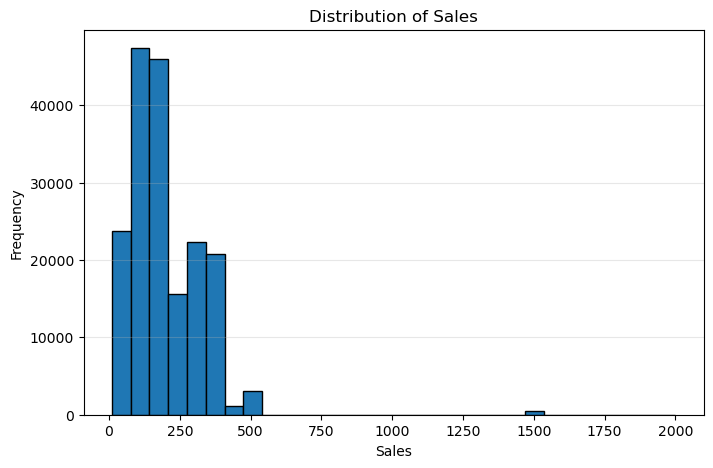

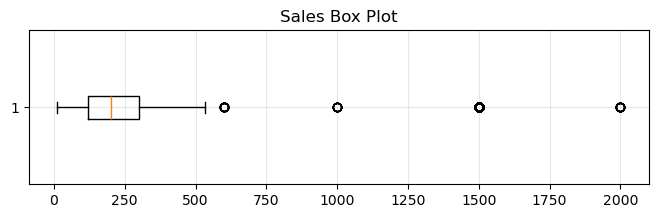


Sales Quantiles
0.25    119.980003
0.50    199.919998
0.75    299.950012
0.90    399.980011
0.95    399.980011
0.99    499.950012
Name: Sales, dtype: float64

Outlier Analysis
Q1                  : 119.98
Q3                  : 299.95
IQR                 : 179.97
Lower Bound         : -149.98
Upper Bound         : 569.91
Number of Outliers  : 488
Percentage Outliers : 0.27 %


In [110]:
# ==========================================================
# 2.1 Sales Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Sales"].describe())

# ----------------------------------------------------------
# 2. Additional Statistics
# ----------------------------------------------------------
print("\nAdditional Statistics")
print("Mean                :", round(df["Sales"].mean(), 2))
print("Median              :", round(df["Sales"].median(), 2))
print("Mode                :", round(df["Sales"].mode()[0], 2))
print("Standard Deviation  :", round(df["Sales"].std(), 2))
print("Variance            :", round(df["Sales"].var(), 2))
print("Skewness            :", round(df["Sales"].skew(), 2))
print("Kurtosis            :", round(df["Sales"].kurt(), 2))

# ----------------------------------------------------------
# 3. Histogram
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30, edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,2))

plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Box Plot")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Quantile Analysis
# ----------------------------------------------------------
print("\nSales Quantiles")
print(df["Sales"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("\nOutlier Analysis")
print("Q1                  :", round(Q1, 2))
print("Q3                  :", round(Q3, 2))
print("IQR                 :", round(IQR, 2))
print("Lower Bound         :", round(lower_bound, 2))
print("Upper Bound         :", round(upper_bound, 2))
print("Number of Outliers  :", len(outliers))
print("Percentage Outliers :", round((len(outliers) / len(df)) * 100, 2), "%")

#### Observation

The sales variable contains **180,519** observations with **no missing values**, indicating a complete and reliable dataset for analysis.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 203.77 |
| Median | 199.92 |
| Mode | 129.99 |
| Standard Deviation | 132.27 |
| Variance | 17,496.17 |
| Minimum | 9.99 |
| Maximum | 1,999.99 |
| Skewness | 2.88 |
| Kurtosis | 23.94 |

**Quantile Analysis**

| Percentile | Sales |
|------------|------:|
| 25% (Q1) | 119.98 |
| 50% (Median) | 199.92 |
| 75% (Q3) | 299.95 |
| 90% | 399.98 |
| 95% | 399.98 |
| 99% | 499.95 |

**Distribution Analysis**

- The histogram shows that most customer orders fall between **100 and 400** in sales.
- The sales distribution is **positively (right) skewed**, indicating that while most orders have moderate sales values, a small number of transactions generate exceptionally high sales.
- The box plot confirms the presence of several high-value outliers beyond the upper whisker.

**Outlier Analysis**

| Metric | Value |
|--------|------:|
| Q1 | 119.98 |
| Q3 | 299.95 |
| IQR | 179.97 |
| Lower Bound | -149.98 |
| Upper Bound | 569.91 |
| Number of Outliers | 488 |
| Percentage of Outliers | 0.27% |

Only **0.27%** of transactions are identified as outliers, indicating that extreme sales values are rare.

---

#### Business Impact

The average customer spends approximately **204** per order, while the median order value of **200** suggests that a typical customer purchase is close to the average.

The positive skewness (**2.88**) indicates that revenue is influenced by a relatively small number of high-value orders. These premium transactions contribute disproportionately to total sales and should be monitored separately.

Although the maximum recorded sale is nearly **2,000**, such transactions represent only **0.27%** of all orders. Therefore, these outliers are likely to be genuine high-value purchases rather than data quality issues.

The high kurtosis (**23.94**) further indicates the presence of a heavy-tailed distribution with a few extreme sales values. This is common in retail and e-commerce datasets where occasional bulk or premium purchases occur.

---

#### Recommendation

- Retain the detected outliers, as they are likely to represent legitimate high-value customer purchases rather than erroneous records.
- Use the **median** alongside the mean when reporting typical order values, since the distribution is positively skewed.
- Investigate high-value transactions to identify premium customers, bulk purchases, or successful promotional campaigns.
- Consider customer segmentation based on sales value for targeted marketing and revenue optimization.
- If machine learning models sensitive to outliers are used, consider applying log transformation or robust scaling to the **Sales** variable.

---

#### Key Insights

- The typical customer spends approximately **200** per order.
- Most sales transactions fall within the **100–400** range.
- The sales distribution is **positively skewed**, with a few exceptionally high-value orders.
- Only **488 transactions (0.27%)** are classified as outliers.
- The identified outliers are likely to represent genuine premium purchases and should be retained for business analysis.

### 2.2 Benefit per Order

#### Business Question

**How is profit distributed across customer orders, and what does it reveal about business profitability?**

#### Objective

Analyze the distribution of **Benefit per Order** to understand the profitability of customer transactions, identify the typical profit earned per order, measure the variability in profit, and detect unusually high-profit or loss-making transactions that may require further business investigation.

Descriptive Statistics
count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Benefit per order, dtype: float64

Additional Statistics
Mean                : 21.97
Median              : 31.52
Mode                : 0.0
Standard Deviation  : 104.43
Variance            : 10906.36
Skewness            : -4.74
Kurtosis            : 71.38


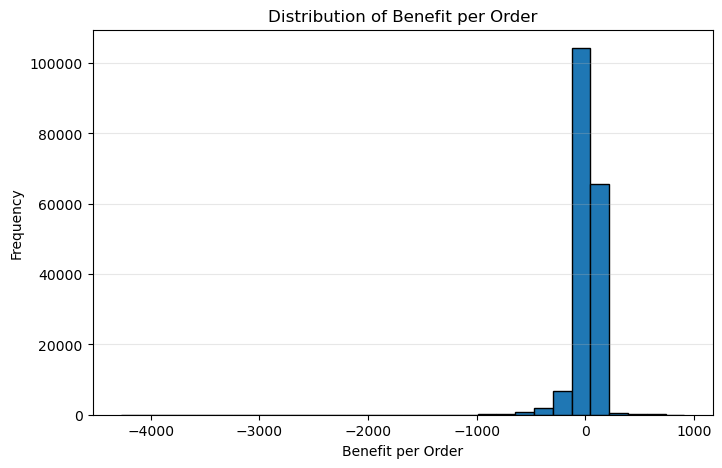

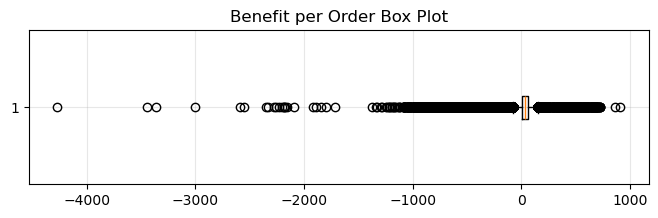


Benefit per Order Quantiles
0.25      7.000000
0.50     31.520000
0.75     64.800003
0.90    105.190002
0.95    132.289993
0.99    184.229996
Name: Benefit per order, dtype: float64

Outlier Analysis
Q1                  : 7.0
Q3                  : 64.8
IQR                 : 57.8
Lower Bound         : -79.7
Upper Bound         : 151.5
Number of Outliers  : 18942
Percentage Outliers : 10.49 %


In [111]:
# ==========================================================
# 2.2 Benefit per Order Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Benefit per order"].describe())

# ----------------------------------------------------------
# 2. Additional Statistics
# ----------------------------------------------------------
print("\nAdditional Statistics")
print("Mean                :", round(df["Benefit per order"].mean(), 2))
print("Median              :", round(df["Benefit per order"].median(), 2))
print("Mode                :", round(df["Benefit per order"].mode()[0], 2))
print("Standard Deviation  :", round(df["Benefit per order"].std(), 2))
print("Variance            :", round(df["Benefit per order"].var(), 2))
print("Skewness            :", round(df["Benefit per order"].skew(), 2))
print("Kurtosis            :", round(df["Benefit per order"].kurt(), 2))

# ----------------------------------------------------------
# 3. Histogram
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(df["Benefit per order"], bins=30, edgecolor="black")

plt.title("Distribution of Benefit per Order")
plt.xlabel("Benefit per Order")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,2))

plt.boxplot(df["Benefit per order"], vert=False)

plt.title("Benefit per Order Box Plot")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Quantile Analysis
# ----------------------------------------------------------
print("\nBenefit per Order Quantiles")
print(df["Benefit per order"].quantile([0.25,0.50,0.75,0.90,0.95,0.99]))

# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------
Q1 = df["Benefit per order"].quantile(0.25)
Q3 = df["Benefit per order"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Benefit per order"] < lower_bound) |
    (df["Benefit per order"] > upper_bound)
]

print("\nOutlier Analysis")
print("Q1                  :", round(Q1,2))
print("Q3                  :", round(Q3,2))
print("IQR                 :", round(IQR,2))
print("Lower Bound         :", round(lower_bound,2))
print("Upper Bound         :", round(upper_bound,2))
print("Number of Outliers  :", len(outliers))
print("Percentage Outliers :", round(len(outliers)/len(df)*100,2), "%")

#### Observation

The **Benefit per Order** variable contains **180,519** observations, providing a complete dataset for profitability analysis.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 21.97 |
| Median | 31.52 |
| Mode | 0.00 |
| Standard Deviation | 104.43 |
| Variance | 10,906.36 |
| Minimum | -4274.98 |
| Maximum | 911.80 |
| Skewness | -4.74 |
| Kurtosis | 71.38 |

**Quantile Analysis**

| Percentile | Benefit per Order |
|------------|------------------:|
| 25% (Q1) | 7.00 |
| 50% (Median) | 31.52 |
| 75% (Q3) | 64.80 |
| 90% | 105.19 |
| 95% | 132.29 |
| 99% | 184.23 |

**Distribution Analysis**

- The histogram shows that most orders generate relatively small positive profits.
- The distribution is **highly negatively skewed**, indicating the presence of a few orders with exceptionally large losses.
- The box plot confirms a large number of extreme observations on both the profit and loss sides, with substantially more extreme negative values.

**Outlier Analysis**

| Metric | Value |
|---------|-------:|
| Q1 | 7.00 |
| Q3 | 64.80 |
| IQR | 57.80 |
| Lower Bound | -79.70 |
| Upper Bound | 151.50 |
| Number of Outliers | 18,942 |
| Percentage of Outliers | 10.49% |

Approximately **10.49%** of the transactions are identified as outliers using the IQR method.

---

#### Business Impact

The average profit per order is **21.97**, while the median profit is **31.52**, indicating that a small number of highly unprofitable transactions reduce the overall average profit.

The strong negative skewness (**-4.74**) suggests that the business occasionally incurs substantial losses on certain orders. These losses may result from heavy discounts, product returns, cancellations, shipping costs, promotional campaigns, or operational inefficiencies.

The extremely high kurtosis (**71.38**) indicates a heavy-tailed distribution with many extreme profit and loss values. Such distributions are common in retail and supply chain businesses where a small proportion of orders contribute disproportionately to financial performance.

The presence of **18,942 outliers (10.49%)** suggests that unusual profit values are relatively common and deserve further investigation rather than automatic removal.

---

#### Recommendation

- Retain the outliers, as they are likely to represent genuine business transactions.
- Investigate orders with large negative profits to identify potential causes such as excessive discounts, returns, high shipping costs, or pricing issues.
- Analyze highly profitable orders separately to identify products, customer segments, or regions contributing most to profitability.
- Monitor profitability alongside sales, since high sales do not always translate into high profit.
- Consider applying robust statistical techniques or data transformation when building machine learning models sensitive to extreme values.

---

#### Key Insights

- The typical order generates a positive profit, with a median profit of **31.52**.
- A small number of large-loss transactions significantly reduce the average profit.
- Profit distribution is **highly left-skewed**, indicating the presence of substantial loss-making orders.
- Approximately **10.49%** of transactions are classified as outliers.
- Investigating extreme profit and loss transactions can help improve pricing strategies, discount policies, and overall profitability.

### 2.3 Days for Shipping (Real)

#### Business Question

**What is the distribution of the actual shipping time for customer orders, and does it indicate a consistent delivery process?**

#### Objective

Analyze the distribution of the actual shipping time to understand delivery performance, identify the typical shipping duration, measure variability in delivery time, and detect unusually long or short shipping durations that may indicate operational inefficiencies.

Descriptive Statistics
count    180519.000000
mean          3.497654
std           1.623722
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: Days for shipping (real), dtype: float64

Additional Statistics
Mean                : 3.5
Median              : 3.0
Mode                : 2
Minimum             : 0
Maximum             : 6
Range               : 6
Standard Deviation  : 1.62
Variance            : 2.64
Skewness            : 0.08
Kurtosis            : -1.01


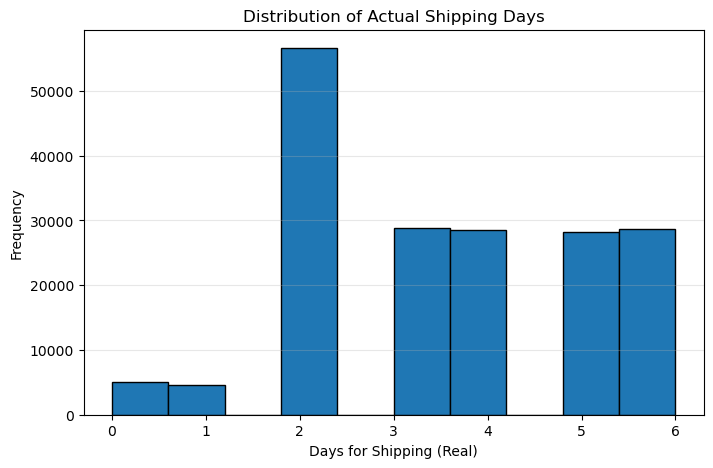

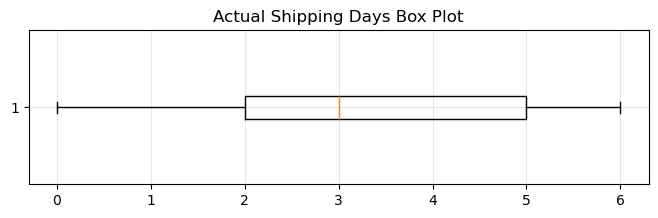


Shipping Days Quantiles
0.25    2.0
0.50    3.0
0.75    5.0
0.90    6.0
0.95    6.0
0.99    6.0
Name: Days for shipping (real), dtype: float64

Outlier Analysis
Q1                  : 2.0
Q3                  : 5.0
IQR                 : 3.0
Lower Bound         : -2.5
Upper Bound         : 9.5
Number of Outliers  : 0
Percentage Outliers : 0.0 %


In [112]:
# ==========================================================
# 2.3 Days for Shipping (Real) Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Days for shipping (real)"].describe())

# ----------------------------------------------------------
# 2. Additional Statistics
# ----------------------------------------------------------
print("\nAdditional Statistics")

print("Mean                :", round(df["Days for shipping (real)"].mean(), 2))
print("Median              :", round(df["Days for shipping (real)"].median(), 2))
print("Mode                :", df["Days for shipping (real)"].mode()[0])

print("Minimum             :", df["Days for shipping (real)"].min())
print("Maximum             :", df["Days for shipping (real)"].max())
print("Range               :", df["Days for shipping (real)"].max() - df["Days for shipping (real)"].min())

print("Standard Deviation  :", round(df["Days for shipping (real)"].std(), 2))
print("Variance            :", round(df["Days for shipping (real)"].var(), 2))

print("Skewness            :", round(df["Days for shipping (real)"].skew(), 2))
print("Kurtosis            :", round(df["Days for shipping (real)"].kurt(), 2))

# ----------------------------------------------------------
# 3. Histogram
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(df["Days for shipping (real)"], bins=10, edgecolor="black")

plt.title("Distribution of Actual Shipping Days")
plt.xlabel("Days for Shipping (Real)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,2))

plt.boxplot(df["Days for shipping (real)"], vert=False)

plt.title("Actual Shipping Days Box Plot")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Quantile Analysis
# ----------------------------------------------------------
print("\nShipping Days Quantiles")
print(df["Days for shipping (real)"].quantile([0.25,0.50,0.75,0.90,0.95,0.99]))

# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------
Q1 = df["Days for shipping (real)"].quantile(0.25)
Q3 = df["Days for shipping (real)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["Days for shipping (real)"] < lower_bound) |
    (df["Days for shipping (real)"] > upper_bound)
]

print("\nOutlier Analysis")
print("Q1                  :", Q1)
print("Q3                  :", Q3)
print("IQR                 :", IQR)
print("Lower Bound         :", lower_bound)
print("Upper Bound         :", upper_bound)
print("Number of Outliers  :", len(outliers))
print("Percentage Outliers :", round(len(outliers)/len(df)*100,2), "%")

#### Observation

The **Days for Shipping (Real)** variable contains **180,519** observations, providing complete information about actual delivery times.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 3.50 Days |
| Median | 3 Days |
| Mode | 2 Days |
| Standard Deviation | 1.62 Days |
| Variance | 2.64 |
| Minimum | 0 Days |
| Maximum | 6 Days |
| Skewness | 0.08 |
| Kurtosis | -1.01 |

**Quantile Analysis**

| Percentile | Shipping Days |
|------------|--------------:|
| 25% (Q1) | 2 Days |
| 50% (Median) | 3 Days |
| 75% (Q3) | 5 Days |
| 90% | 6 Days |
| 95% | 6 Days |
| 99% | 6 Days |

**Distribution Analysis**

- The histogram shows that most customer orders are delivered within **2 to 5 days**.
- The distribution is **approximately symmetric**, as indicated by the skewness value (**0.08**), suggesting that shipping times are evenly distributed around the average.
- The box plot shows no extreme observations, indicating a consistent delivery process.

**Outlier Analysis**

| Metric | Value |
|--------|------:|
| Q1 | 2 Days |
| Q3 | 5 Days |
| IQR | 3 Days |
| Lower Bound | -2.5 Days |
| Upper Bound | 9.5 Days |
| Number of Outliers | 0 |
| Percentage of Outliers | 0.00% |

No outliers were detected using the IQR method, indicating that all shipping durations fall within the expected operational range.

---

#### Business Impact

The average shipping time is **3.5 days**, while the median delivery time is **3 days**, indicating a stable and predictable delivery process.

The low standard deviation (**1.62 days**) suggests relatively small variation in shipping duration, which reflects operational consistency.

The near-zero skewness (**0.08**) indicates that delivery times are balanced, with no significant tendency toward unusually fast or slow shipments.

The absence of outliers demonstrates that the logistics process is well controlled, with no unusually delayed shipments beyond the expected delivery range.

Overall, the shipping process appears efficient and standardized, supporting customer satisfaction and reliable supply chain performance.

---

#### Recommendation

- Maintain the current logistics and fulfillment processes, as shipping performance is consistent.
- Monitor orders requiring **5–6 days** to identify opportunities for reducing delivery times.
- Compare actual shipping days with scheduled shipping days in the next phase to evaluate delivery efficiency and identify delays.
- Continue tracking shipping performance through operational dashboards to ensure service quality remains consistent.

---

#### Key Insights

- The average delivery time is **3.5 days**.
- Most customer orders are delivered within **2–5 days**.
- The shipping time distribution is **approximately symmetric**, indicating a stable logistics process.
- No outliers were detected, suggesting consistent operational performance.
- The delivery process appears standardized and suitable for reliable customer service.

### 2.4 Order Item Discount

#### Business Question

**How are discounts distributed across customer orders, and what do they reveal about the company's pricing and promotional strategy?**

#### Objective

Analyze the distribution of **Order Item Discount** to understand the typical discount offered on customer orders, measure the variability in discount values, and identify unusually high discounts that may affect business profitability and pricing decisions.

Descriptive Statistics
count    180519.000000
mean         20.664741
std          21.800901
min           0.000000
25%           5.400000
50%          14.000000
75%          29.990000
max         500.000000
Name: Order Item Discount, dtype: float64

Additional Statistics
Mean                : 20.66
Median              : 14.0
Mode                : 0.0
Minimum             : 0.0
Maximum             : 500.0
Range               : 500.0
Standard Deviation  : 21.8
Variance            : 475.28
Skewness            : 3.04
Kurtosis            : 25.23


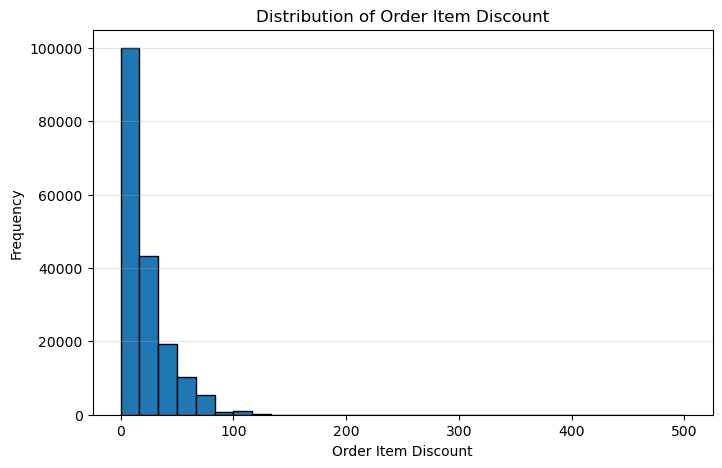

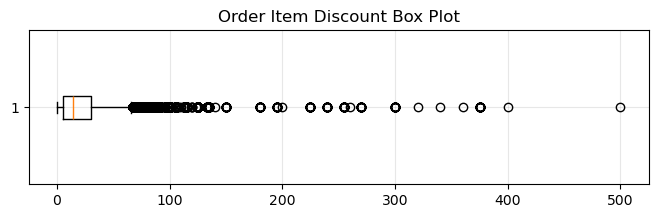


Discount Quantiles
0.25     5.400000
0.50    14.000000
0.75    29.990000
0.90    49.980000
0.95    62.500000
0.99    95.860001
Name: Order Item Discount, dtype: float64

Outlier Analysis
Q1                  : 5.4
Q3                  : 29.99
IQR                 : 24.59
Lower Bound         : -31.48
Upper Bound         : 66.87
Number of Outliers  : 7537
Percentage Outliers : 4.18 %


In [113]:
# ==========================================================
# 2.4 Order Item Discount Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Order Item Discount"].describe())

# ----------------------------------------------------------
# 2. Additional Statistics
# ----------------------------------------------------------
print("\nAdditional Statistics")

print("Mean                :", round(df["Order Item Discount"].mean(), 2))
print("Median              :", round(df["Order Item Discount"].median(), 2))
print("Mode                :", round(df["Order Item Discount"].mode()[0], 2))

print("Minimum             :", round(df["Order Item Discount"].min(), 2))
print("Maximum             :", round(df["Order Item Discount"].max(), 2))
print("Range               :", round(df["Order Item Discount"].max() - df["Order Item Discount"].min(), 2))

print("Standard Deviation  :", round(df["Order Item Discount"].std(), 2))
print("Variance            :", round(df["Order Item Discount"].var(), 2))

print("Skewness            :", round(df["Order Item Discount"].skew(), 2))
print("Kurtosis            :", round(df["Order Item Discount"].kurt(), 2))

# ----------------------------------------------------------
# 3. Histogram
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(df["Order Item Discount"], bins=30, edgecolor="black")

plt.title("Distribution of Order Item Discount")
plt.xlabel("Order Item Discount")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,2))

plt.boxplot(df["Order Item Discount"], vert=False)

plt.title("Order Item Discount Box Plot")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Quantile Analysis
# ----------------------------------------------------------
print("\nDiscount Quantiles")
print(df["Order Item Discount"].quantile([0.25,0.50,0.75,0.90,0.95,0.99]))

# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------
Q1 = df["Order Item Discount"].quantile(0.25)
Q3 = df["Order Item Discount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["Order Item Discount"] < lower_bound) |
    (df["Order Item Discount"] > upper_bound)
]

print("\nOutlier Analysis")
print("Q1                  :", round(Q1,2))
print("Q3                  :", round(Q3,2))
print("IQR                 :", round(IQR,2))
print("Lower Bound         :", round(lower_bound,2))
print("Upper Bound         :", round(upper_bound,2))
print("Number of Outliers  :", len(outliers))
print("Percentage Outliers :", round(len(outliers)/len(df)*100,2), "%")

#### Observation

The **Order Item Discount** variable contains **180,519** observations, providing complete information on discounts applied to customer orders.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 20.66 |
| Median | 14.00 |
| Mode | 0.00 |
| Standard Deviation | 21.80 |
| Variance | 475.28 |
| Minimum | 0.00 |
| Maximum | 500.00 |
| Skewness | 3.04 |
| Kurtosis | 25.23 |

**Quantile Analysis**

| Percentile | Discount |
|------------|---------:|
| 25% (Q1) | 5.40 |
| 50% (Median) | 14.00 |
| 75% (Q3) | 29.99 |
| 90% | 49.98 |
| 95% | 62.50 |
| 99% | 95.86 |

**Distribution Analysis**

- The histogram indicates that most customer orders receive **low discounts**, typically below **30**.
- The distribution is **highly positively skewed**, indicating that only a small proportion of orders receive very large discounts.
- The box plot shows several high-value discount observations beyond the upper whisker, confirming the presence of extreme discount values.

**Outlier Analysis**

| Metric | Value |
|--------|------:|
| Q1 | 5.40 |
| Q3 | 29.99 |
| IQR | 24.59 |
| Lower Bound | -31.48 |
| Upper Bound | 66.87 |
| Number of Outliers | 7,537 |
| Percentage of Outliers | 4.18% |

Approximately **4.18%** of the orders are identified as outliers based on the IQR method.

---

#### Business Impact

The average discount offered per order is **20.66**, while the median discount is **14.00**, indicating that a relatively small number of heavily discounted orders increase the overall average discount.

The mode of **0.00** shows that many customer orders receive **no discount**, suggesting that discounts are applied selectively rather than universally.

The strong positive skewness (**3.04**) indicates that large discounts are uncommon and are likely associated with promotional campaigns, clearance sales, bulk purchases, or special customer offers.

The high kurtosis (**25.23**) suggests the presence of several extreme discount values, highlighting occasional aggressive pricing strategies.

---

#### Recommendation

- Retain the identified outliers, as they likely represent genuine promotional or bulk-purchase transactions.
- Investigate orders with exceptionally high discounts to evaluate their impact on profitability.
- Compare **Order Item Discount** with **Benefit per Order** in the bivariate analysis to determine whether higher discounts reduce profitability.
- Analyze discounts across customer segments, product categories, and regions to assess the effectiveness of promotional strategies.
- Monitor high-discount transactions to ensure that pricing policies remain profitable and aligned with business objectives.

---

#### Key Insights

- The typical customer receives a relatively small discount, with a median value of **14.00**.
- Many orders receive **no discount**, indicating selective promotional strategies.
- The discount distribution is **highly right-skewed**, with a small number of heavily discounted orders.
- Approximately **4.18%** of transactions are classified as outliers.
- High-discount orders should be analyzed alongside profit to evaluate the effectiveness of the company's pricing and promotional strategies.

### 2.5 Order Item Quantity

#### Business Question

**What is the distribution of the quantity of items purchased per order, and what does it reveal about customer purchasing behavior?**

#### Objective

Analyze the distribution of **Order Item Quantity** to understand the typical number of products purchased in each order, measure the variability in order size, and identify unusually large or small purchases that may represent bulk orders or exceptional buying patterns.

Descriptive Statistics
count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

Additional Statistics
Mean                : 2.13
Median              : 1.0
Mode                : 1
Minimum             : 1
Maximum             : 5
Range               : 4
Standard Deviation  : 1.45
Variance            : 2.11
Skewness            : 0.88
Kurtosis            : -0.75


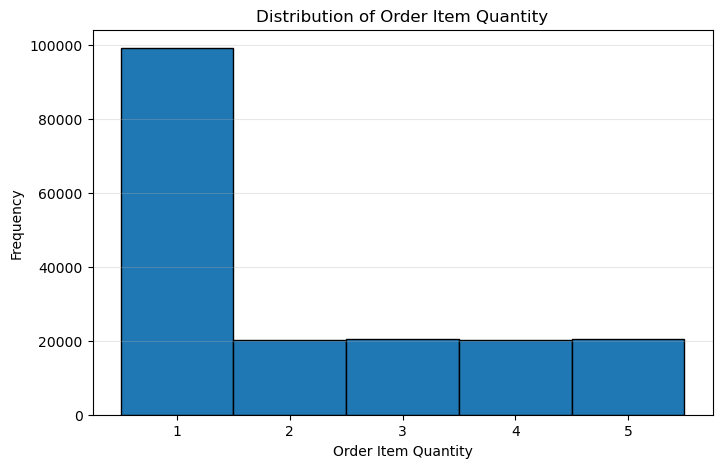

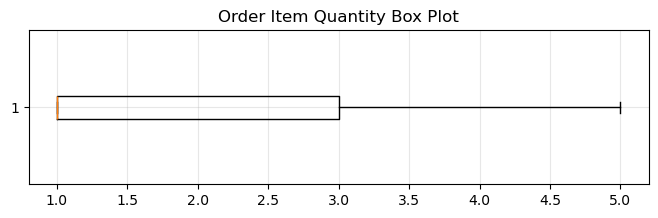


Quantity Quantiles
0.25    1.0
0.50    1.0
0.75    3.0
0.90    5.0
0.95    5.0
0.99    5.0
Name: Order Item Quantity, dtype: float64

Outlier Analysis
Q1                  : 1.0
Q3                  : 3.0
IQR                 : 2.0
Lower Bound         : -2.0
Upper Bound         : 6.0
Number of Outliers  : 0
Percentage Outliers : 0.0 %


In [114]:
# ==========================================================
# 2.5 Order Item Quantity Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Order Item Quantity"].describe())

# ----------------------------------------------------------
# 2. Additional Statistics
# ----------------------------------------------------------
print("\nAdditional Statistics")

print("Mean                :", round(df["Order Item Quantity"].mean(), 2))
print("Median              :", round(df["Order Item Quantity"].median(), 2))
print("Mode                :", df["Order Item Quantity"].mode()[0])

print("Minimum             :", df["Order Item Quantity"].min())
print("Maximum             :", df["Order Item Quantity"].max())
print("Range               :", df["Order Item Quantity"].max() - df["Order Item Quantity"].min())

print("Standard Deviation  :", round(df["Order Item Quantity"].std(), 2))
print("Variance            :", round(df["Order Item Quantity"].var(), 2))

print("Skewness            :", round(df["Order Item Quantity"].skew(), 2))
print("Kurtosis            :", round(df["Order Item Quantity"].kurt(), 2))

# ----------------------------------------------------------
# 3. Histogram
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.hist(df["Order Item Quantity"], bins=range(
    int(df["Order Item Quantity"].min()),
    int(df["Order Item Quantity"].max()) + 2
), edgecolor="black", align="left")

plt.title("Distribution of Order Item Quantity")
plt.xlabel("Order Item Quantity")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,2))

plt.boxplot(df["Order Item Quantity"], vert=False)

plt.title("Order Item Quantity Box Plot")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Quantile Analysis
# ----------------------------------------------------------
print("\nQuantity Quantiles")
print(df["Order Item Quantity"].quantile([0.25,0.50,0.75,0.90,0.95,0.99]))

# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------
Q1 = df["Order Item Quantity"].quantile(0.25)
Q3 = df["Order Item Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["Order Item Quantity"] < lower_bound) |
    (df["Order Item Quantity"] > upper_bound)
]

print("\nOutlier Analysis")
print("Q1                  :", Q1)
print("Q3                  :", Q3)
print("IQR                 :", IQR)
print("Lower Bound         :", lower_bound)
print("Upper Bound         :", upper_bound)
print("Number of Outliers  :", len(outliers))
print("Percentage Outliers :", round(len(outliers)/len(df)*100,2), "%")

#### Observation

The **Order Item Quantity** variable contains **180,519** observations, representing the number of units purchased in each order.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 2.13 |
| Median | 1.00 |
| Mode | 1 |
| Standard Deviation | 1.45 |
| Variance | 2.11 |
| Minimum | 1 |
| Maximum | 5 |
| Skewness | 0.88 |
| Kurtosis | -0.75 |

**Quantile Analysis**

| Percentile | Quantity |
|------------|---------:|
| 25% (Q1) | 1 |
| 50% (Median) | 1 |
| 75% (Q3) | 3 |
| 90% | 5 |
| 95% | 5 |
| 99% | 5 |

**Distribution Analysis**

- The histogram shows that the majority of customer orders contain **only one item**.
- The distribution is **slightly positively skewed**, indicating that while most customers purchase small quantities, a smaller proportion place larger orders.
- The box plot shows no unusual observations, suggesting that order quantities remain within a consistent and expected range.

**Outlier Analysis**

| Metric | Value |
|--------|------:|
| Q1 | 1 |
| Q3 | 3 |
| IQR | 2 |
| Lower Bound | -2 |
| Upper Bound | 6 |
| Number of Outliers | 0 |
| Percentage of Outliers | 0.00% |

No outliers were detected using the IQR method, indicating that all order quantities fall within the normal business range.

---

#### Business Impact

The average customer purchases approximately **2.13 items per order**, while both the median and mode are **1**, indicating that single-item purchases dominate the dataset.

The slight positive skewness (**0.88**) suggests that although most customers place small orders, a limited number purchase multiple items, increasing the average order quantity.

The absence of outliers indicates that order quantities are well controlled and there are no unusually large bulk purchases in the dataset.

This purchasing pattern suggests that customer demand is primarily driven by individual product purchases rather than large-volume transactions.

---

#### Recommendation

- Develop **cross-selling** and **bundle offers** to encourage customers to purchase multiple items per order.
- Analyze order quantity by **product category**, **customer segment**, and **region** to identify opportunities for increasing basket size.
- Monitor Average Order Quantity (AOQ) as a key performance indicator for sales growth.
- Use promotions such as "Buy 2, Get 1 Free" or product bundles to increase the average number of items purchased per order.

---

#### Key Insights

- The typical customer purchases **one item per order**.
- The average order contains **2.13 items**, indicating that a smaller number of multi-item purchases increase the overall average.
- The distribution is **slightly right-skewed**, reflecting occasional larger orders.
- No outliers were detected, demonstrating consistent customer purchasing behavior.
- Increasing the average order quantity through cross-selling and bundling could improve revenue without necessarily increasing customer acquisition costs.

### 2.6 Late Delivery Risk

#### Business Question

**What proportion of customer orders are at risk of late delivery, and how significant is this issue for the supply chain?**

#### Objective

Analyze the distribution of **Late Delivery Risk** to determine the proportion of orders that are at risk of being delivered late. This analysis helps evaluate the reliability of the logistics network and identify potential operational challenges affecting customer satisfaction.

Descriptive Statistics
count    180519.000000
mean          0.548291
std           0.497664
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Late_delivery_risk, dtype: float64

Frequency Distribution
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Percentage Distribution
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


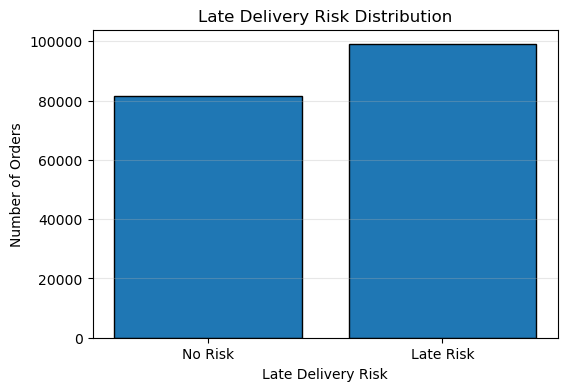

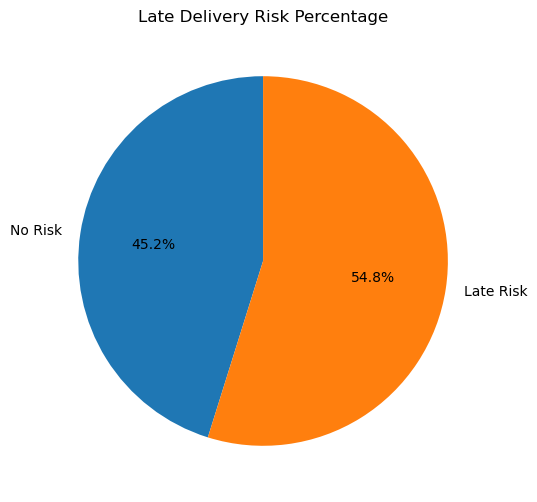

In [115]:
# ==========================================================
# 2.6 Late Delivery Risk Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Descriptive Statistics
# ----------------------------------------------------------
print("Descriptive Statistics")
print(df["Late_delivery_risk"].describe())

# ----------------------------------------------------------
# 2. Frequency Distribution
# ----------------------------------------------------------
print("\nFrequency Distribution")
print(df["Late_delivery_risk"].value_counts())

# ----------------------------------------------------------
# 3. Percentage Distribution
# ----------------------------------------------------------
print("\nPercentage Distribution")
print(round(df["Late_delivery_risk"].value_counts(normalize=True) * 100, 2))

# ----------------------------------------------------------
# 4. Bar Chart
# ----------------------------------------------------------
plt.figure(figsize=(6,4))

counts = df["Late_delivery_risk"].value_counts().sort_index()

plt.bar(
    counts.index.astype(str),
    counts.values,
    edgecolor="black"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.xticks(["0", "1"], ["No Risk", "Late Risk"])

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Pie Chart
# ----------------------------------------------------------
plt.figure(figsize=(6,6))

plt.pie(
    counts.values,
    labels=["No Risk", "Late Risk"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Late Delivery Risk Percentage")

plt.show()

#### Observation

The **Late Delivery Risk** variable contains **180,519** observations and indicates whether an order is at risk of being delivered late.

**Descriptive Statistics**

| Metric | Value |
|---------|-------:|
| Count | 180,519 |
| Mean | 0.5483 |
| Standard Deviation | 0.4977 |
| Minimum | 0 |
| Maximum | 1 |

**Frequency Distribution**

| Late Delivery Risk | Number of Orders | Percentage |
|-------------------|-----------------:|-----------:|
| No Risk (0) | 81,542 | 45.17% |
| Late Risk (1) | 98,977 | 54.83% |

**Distribution Analysis**

- The bar chart shows that orders with **Late Delivery Risk** slightly outnumber those without risk.
- The pie chart indicates that **54.83%** of customer orders are classified as being at risk of late delivery, while **45.17%** are not.
- The dataset is relatively balanced, making this variable suitable for predictive modeling without major concerns about class imbalance.

---

#### Business Impact

More than **half of all customer orders (54.83%)** are identified as having a risk of late delivery. This suggests that delivery delays are a significant operational challenge and may negatively affect customer satisfaction, repeat purchases, and overall supply chain performance.

Since the target variable is reasonably balanced between the two classes, it is well suited for classification models aimed at predicting late deliveries.

Reducing the proportion of high-risk orders can improve customer experience, strengthen service reliability, and lower operational costs associated with delayed shipments.

---

#### Recommendation

- Investigate the factors contributing to late delivery, such as shipping mode, region, customer location, order quantity, and actual shipping time.
- Build a machine learning classification model to predict late delivery risk before shipment.
- Prioritize high-risk orders for proactive monitoring and logistics optimization.
- Track late delivery risk as a key operational KPI and regularly monitor trends through business dashboards.

---

#### Key Insights

- **54.83%** of orders are classified as having a risk of late delivery.
- **45.17%** of orders are delivered without late delivery risk.
- The target variable is well balanced, making it suitable for predictive modeling.
- Reducing late delivery risk can improve customer satisfaction, operational efficiency, and overall supply chain performance.

## Phase 3: Bivariate Analysis

### Objective

The objective of this phase is to analyze the relationship between two business variables to identify patterns, dependencies, and factors influencing supply chain performance. Bivariate analysis helps determine how one business metric affects another, enabling deeper insights into sales, profitability, logistics, customer behavior, and operational efficiency.

### Business Relationships Analyzed

- 💰 Sales vs Benefit per Order
- 🏷️ Order Item Discount vs Benefit per Order
- 🚚 Days for Shipping (Real) vs Late Delivery Risk
- 🚛 Shipping Mode vs Late Delivery Risk
- 👥 Customer Segment vs Sales
- 📦 Category Name vs Sales
- 🌍 Market vs Sales
- 📈 Order Item Quantity vs Sales
- 🔥 Correlation Analysis

### Analyses Performed

Depending on the variables involved, the following analyses will be performed where applicable:

- Correlation Analysis
- Scatter Plot
- Group-wise Statistical Analysis
- Box Plot
- Bar Chart
- Cross-tabulation
- Correlation Heatmap
- Statistical Hypothesis Testing (where applicable)

### Outcome

This phase uncovers relationships between business variables and provides actionable insights into customer purchasing behavior, profitability, discount effectiveness, shipping performance, and delivery reliability. These findings support strategic business decisions and prepare the dataset for feature engineering and predictive modeling.

### 3.1 Sales vs Benefit per Order

#### Business Question

**Does higher sales revenue lead to higher profit per order?**

#### Objective

Analyze the relationship between **Sales** and **Benefit per Order** to determine whether increasing sales results in higher profitability and identify transactions where high sales may not translate into high profits.

Correlation Coefficient : 0.1318


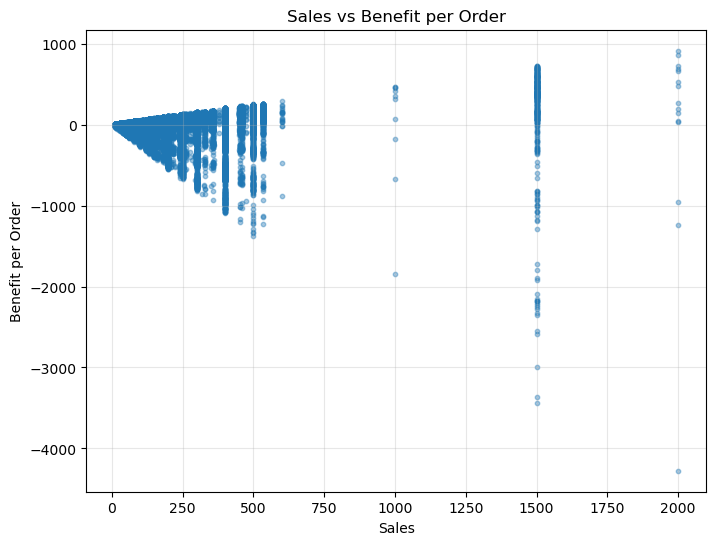


Profit by Sales Group
                 count       mean     median          min         max
Sales                                                                
Low Sales        47111   8.321872  13.510000  -323.350006   59.990002
Medium Sales     45369  16.004041  34.040001  -534.390015   99.959999
High Sales       45687  24.829989  52.500000  -824.859985  149.979996
Very High Sales  42352  40.478754  84.000000 -4274.979980  911.799988


In [116]:
# ==========================================================
# 3.1 Sales vs Benefit per Order
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Correlation
# ----------------------------------------------------------
correlation = df["Sales"].corr(df["Benefit per order"])

print("Correlation Coefficient :", round(correlation, 4))

# ----------------------------------------------------------
# 2. Scatter Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    df["Sales"],
    df["Benefit per order"],
    alpha=0.4,
    s=10
)

plt.title("Sales vs Benefit per Order")
plt.xlabel("Sales")
plt.ylabel("Benefit per Order")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 3. Profit grouped by Sales Quartiles
# ----------------------------------------------------------

sales_groups = pd.qcut(
    df["Sales"],
    q=4,
    labels=[
        "Low Sales",
        "Medium Sales",
        "High Sales",
        "Very High Sales"
    ]
)

group_analysis = (
    df
    .groupby(sales_groups, observed=False)["Benefit per order"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nProfit by Sales Group")
print(group_analysis)

#### Observation

The relationship between **Sales** and **Benefit per Order** was analyzed using correlation analysis, a scatter plot, and profit statistics across sales quartiles.

**Correlation Analysis**

| Metric | Value |
|--------|------:|
| Correlation Coefficient | **0.1318** |

The correlation coefficient indicates a **weak positive relationship** between sales and profit per order.

---

**Profit by Sales Group**

| Sales Group | Orders | Mean Profit | Median Profit | Minimum Profit | Maximum Profit |
|-------------|-------:|------------:|--------------:|---------------:|---------------:|
| Low Sales | 47,111 | 8.32 | 13.51 | -323.35 | 59.99 |
| Medium Sales | 45,369 | 16.00 | 34.04 | -534.39 | 99.96 |
| High Sales | 45,687 | 24.83 | 52.50 | -824.86 | 149.98 |
| Very High Sales | 42,352 | 40.48 | 84.00 | -4274.98 | 911.80 |

---

**Scatter Plot Analysis**

- The scatter plot shows a slight upward trend, indicating that profit generally increases as sales increase.
- However, the relationship is relatively weak, as there is considerable variation in profit for similar sales values.
- Several high-sales transactions generated significant losses, while others produced substantial profits.
- Profit variability increases with higher sales, suggesting that additional business factors influence profitability.

---

#### Business Impact

Although higher sales are generally associated with higher profits, the weak correlation (**0.1318**) indicates that sales alone are not a reliable predictor of profitability.

The average profit increases steadily across sales groups:

- Low Sales → **8.32**
- Medium Sales → **16.00**
- High Sales → **24.83**
- Very High Sales → **40.48**

However, the presence of high-value orders with large negative profits suggests that factors such as excessive discounts, unfavorable pricing strategies, shipping costs, or operational inefficiencies may reduce profitability despite strong sales performance.

Therefore, focusing solely on increasing revenue may not maximize overall business profit.

---

#### Recommendation

- Investigate high-sales orders that generate low or negative profits.
- Analyze the relationship between **discounts and profit**, as excessive discounting may reduce profitability.
- Review pricing strategies for high-value transactions.
- Monitor both **Sales** and **Benefit per Order** simultaneously when evaluating business performance.
- Develop profitability-focused dashboards instead of relying solely on revenue-based KPIs.

---

#### Key Insights

- Sales and profit exhibit a **weak positive relationship** (**r = 0.1318**).
- Higher sales generally result in higher average profit, but the relationship is not strong.
- High-value transactions can still generate substantial losses.
- Profitability depends on multiple business factors beyond sales volume.
- Optimizing pricing and discount strategies may improve profit more effectively than increasing sales alone.

### 3.2 Order Item Discount vs Benefit per Order

#### Business Question

**How does the discount offered on an order affect the profit earned per order?**

#### Objective

Analyze the relationship between **Order Item Discount** and **Benefit per Order** to determine whether higher discounts reduce profitability and identify an optimal discount strategy that balances customer acquisition with business profit.

Correlation Coefficient : 0.0648


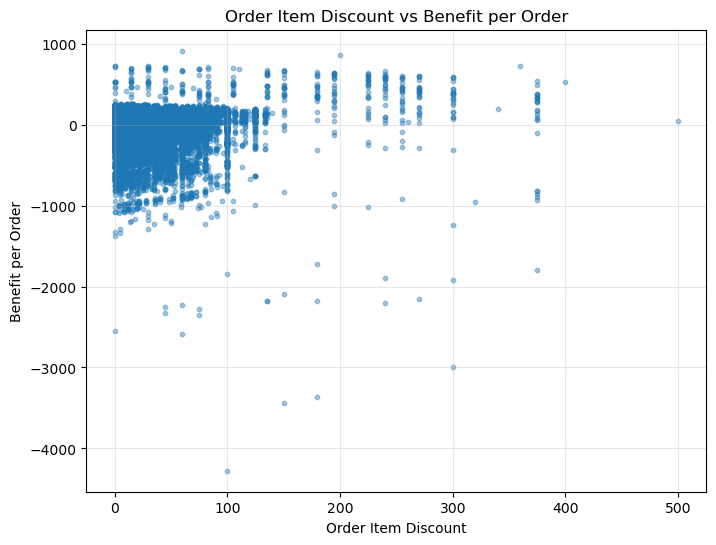


Profit by Discount Group
                     count       mean     median          min         max
Order Item Discount                                                      
Low Discount         45155  17.400348  20.000000 -2550.000000  720.000000
Medium Discount      45351  18.506001  24.629999 -1205.819946  415.799988
High Discount        44901  21.859714  34.400002 -1188.000000  697.950012
Very High Discount   45112  30.156091  54.099998 -4274.979980  911.799988


In [117]:
# ==========================================================
# 3.2 Order Item Discount vs Benefit per Order
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Correlation
# ----------------------------------------------------------
correlation = df["Order Item Discount"].corr(df["Benefit per order"])

print("Correlation Coefficient :", round(correlation, 4))

# ----------------------------------------------------------
# 2. Scatter Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    df["Order Item Discount"],
    df["Benefit per order"],
    alpha=0.4,
    s=10
)

plt.title("Order Item Discount vs Benefit per Order")
plt.xlabel("Order Item Discount")
plt.ylabel("Benefit per Order")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 3. Profit by Discount Quartiles
# ----------------------------------------------------------

discount_groups = pd.qcut(
    df["Order Item Discount"],
    q=4,
    labels=[
        "Low Discount",
        "Medium Discount",
        "High Discount",
        "Very High Discount"
    ],
    duplicates="drop"
)

group_analysis = (
    df
    .groupby(discount_groups, observed=False)["Benefit per order"]
    .agg(["count","mean","median","min","max"])
)

print("\nProfit by Discount Group")
print(group_analysis)

#### Observation

The relationship between **Order Item Discount** and **Benefit per Order** was analyzed using correlation analysis, a scatter plot, and profit statistics across discount quartiles.

**Correlation Analysis**

| Metric | Value |
|--------|------:|
| Correlation Coefficient | **0.0648** |

The correlation coefficient indicates a **very weak positive relationship** between discount amount and profit per order.

---

**Profit by Discount Group**

| Discount Group | Orders | Mean Profit | Median Profit | Minimum Profit | Maximum Profit |
|----------------|-------:|------------:|--------------:|---------------:|---------------:|
| Low Discount | 45,155 | 17.40 | 20.00 | -2550.00 | 720.00 |
| Medium Discount | 45,351 | 18.51 | 24.63 | -1205.82 | 415.80 |
| High Discount | 44,901 | 21.86 | 34.40 | -1188.00 | 697.95 |
| Very High Discount | 45,112 | 30.16 | 54.10 | -4274.98 | 911.80 |

---

**Scatter Plot Analysis**

- The scatter plot shows considerable variation in profit across all discount levels.
- No strong linear relationship is visible between discount amount and profit.
- Higher discount values are associated with both highly profitable and highly unprofitable orders.
- Several extreme loss-making transactions are observed at higher discount levels, indicating that some heavily discounted orders generate substantial losses.

---

#### Business Impact

The correlation coefficient (**0.0648**) indicates that **discount amount alone has little influence on profitability**.

Although the average profit appears to increase across higher discount groups, the presence of large negative-profit transactions suggests that discounts interact with other business factors such as product price, order quantity, product category, and sales value.

Therefore, discount policies should not be evaluated independently, as profitability is influenced by multiple variables rather than discount amount alone.

---

#### Recommendation

- Analyze discounts together with **Sales**, **Product Category**, **Order Quantity**, and **Product Price** to understand their combined effect on profitability.
- Investigate high-discount orders that result in significant financial losses.
- Develop product-specific discount strategies instead of applying uniform discounts across all products.
- Evaluate promotional campaigns based on **net profit** rather than sales revenue alone.

---

#### Key Insights

- Discount amount has a **very weak positive correlation** with profit (**r = 0.0648**).
- There is no strong evidence that increasing discounts alone significantly changes profitability.
- High-discount orders can be either highly profitable or highly unprofitable.
- Profitability depends on multiple interacting business factors rather than discount amount alone.
- Additional multivariate analysis is required to understand the true impact of discounts on business profit.

### 3.3 Days for Shipping (Real) vs Late Delivery Risk

#### Business Question

**Does the actual shipping duration influence the risk of late delivery?**

#### Objective

Analyze the relationship between **Days for Shipping (Real)** and **Late Delivery Risk** to determine whether longer shipping durations are associated with a higher probability of late deliveries. This analysis helps evaluate logistics efficiency and identify opportunities to improve delivery performance.

Correlation Coefficient : 0.4014

Shipping Days by Late Delivery Risk
                    count      mean  median  min  max
Late_delivery_risk                                   
0                   81542  2.779561     3.0    0    6
1                   98977  4.089253     5.0    1    6


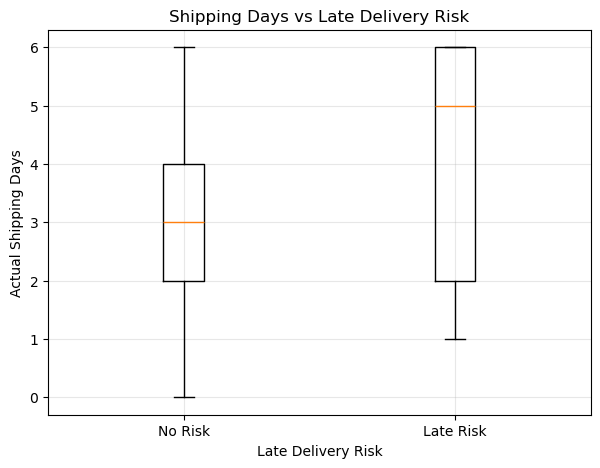

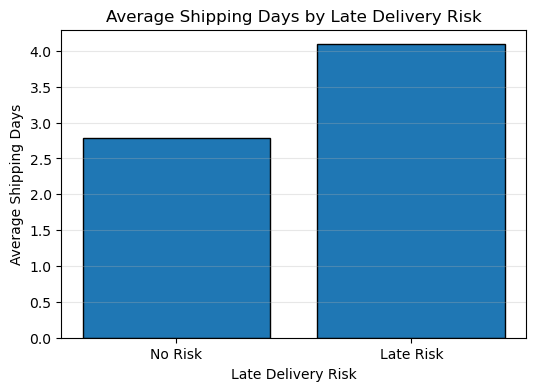

In [118]:
# ==========================================================
# 3.3 Days for Shipping (Real) vs Late Delivery Risk
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Correlation
# ----------------------------------------------------------
correlation = df["Days for shipping (real)"].corr(df["Late_delivery_risk"])

print("Correlation Coefficient :", round(correlation, 4))

# ----------------------------------------------------------
# 2. Average Shipping Days by Late Delivery Risk
# ----------------------------------------------------------
shipping_analysis = (
    df
    .groupby("Late_delivery_risk")["Days for shipping (real)"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nShipping Days by Late Delivery Risk")
print(shipping_analysis)

# ----------------------------------------------------------
# 3. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        df[df["Late_delivery_risk"] == 0]["Days for shipping (real)"],
        df[df["Late_delivery_risk"] == 1]["Days for shipping (real)"]
    ],
    tick_labels=["No Risk", "Late Risk"]   # instead of labels=
)

plt.title("Shipping Days vs Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Actual Shipping Days")

plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Mean Shipping Days Bar Chart
# ----------------------------------------------------------
means = shipping_analysis["mean"]

plt.figure(figsize=(6,4))

plt.bar(
    ["No Risk", "Late Risk"],
    means,
    edgecolor="black"
)

plt.title("Average Shipping Days by Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Average Shipping Days")

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Observation

The relationship between **Days for Shipping (Real)** and **Late Delivery Risk** was analyzed using correlation analysis, group-wise statistics, a box plot, and a bar chart.

**Correlation Analysis**

| Metric | Value |
|--------|------:|
| Correlation Coefficient | **0.4014** |

The correlation coefficient indicates a **moderate positive relationship** between actual shipping days and late delivery risk.

---

**Shipping Days by Late Delivery Risk**

| Late Delivery Risk | Orders | Mean Shipping Days | Median | Minimum | Maximum |
|-------------------|-------:|-------------------:|-------:|--------:|--------:|
| No Risk | 81,542 | 2.78 | 3 | 0 | 6 |
| Late Risk | 98,977 | 4.09 | 5 | 1 | 6 |

---

**Visualization Analysis**

- The box plot shows that orders with **Late Delivery Risk** generally require more shipping days than orders without risk.
- The median shipping time increases from **3 days** for non-risky orders to **5 days** for risky orders.
- The bar chart clearly illustrates that the average shipping time is significantly higher for orders classified as having late delivery risk.

---

#### Business Impact

The moderate positive correlation (**r = 0.4014**) indicates that **longer shipping durations substantially increase the likelihood of late deliveries**.

Orders without late delivery risk require an average of **2.78 days**, whereas orders with late delivery risk require an average of **4.09 days**, representing an increase of approximately **1.31 days**.

This finding suggests that shipping duration is a major operational factor affecting delivery performance and customer satisfaction.

Reducing actual shipping time is therefore likely to reduce the number of delayed deliveries and improve overall logistics efficiency.

---

#### Recommendation

- Prioritize reducing actual shipping time through route optimization and improved warehouse operations.
- Identify regions or shipping modes that consistently experience longer delivery times.
- Implement proactive monitoring for orders expected to exceed the average shipping duration.
- Develop predictive models to identify high-risk shipments before dispatch, enabling preventive action.

---

#### Key Insights

- Actual shipping time has a **moderate positive correlation** with late delivery risk (**r = 0.4014**).
- Orders with late delivery risk require an average of **4.09 days**, compared with **2.78 days** for orders without risk.
- The median shipping duration increases from **3 days** to **5 days** for late-risk orders.
- Longer shipping durations are strongly associated with a higher probability of delayed deliveries.
- Improving logistics efficiency and reducing shipping time can significantly enhance delivery performance and customer satisfaction.

### 3.4 Shipping Mode vs Late Delivery Risk

#### Business Question

**Does the choice of shipping mode influence the risk of late delivery?**

#### Objective

Analyze the relationship between **Shipping Mode** and **Late Delivery Risk** to identify which shipping methods are more likely to experience delivery delays. This analysis helps evaluate logistics performance and supports the selection of efficient shipping strategies.

Shipping Mode vs Late Delivery Risk
                No Risk  Late Risk
Shipping Mode                     
First Class        1301      26513
Same Day           5283       4454
Second Class       8229      26987
Standard Class    66729      41023

Percentage Distribution
                No Risk (%)  Late Risk (%)
Shipping Mode                             
First Class            4.68          95.32
Same Day              54.26          45.74
Second Class          23.37          76.63
Standard Class        61.93          38.07


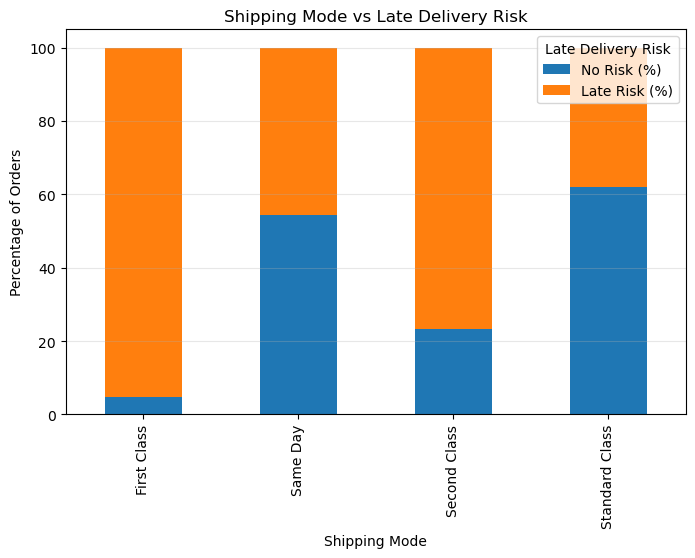


Late Delivery Risk Rate (%)
Shipping Mode
First Class       95.32
Second Class      76.63
Same Day          45.74
Standard Class    38.07
Name: Late_delivery_risk, dtype: float64


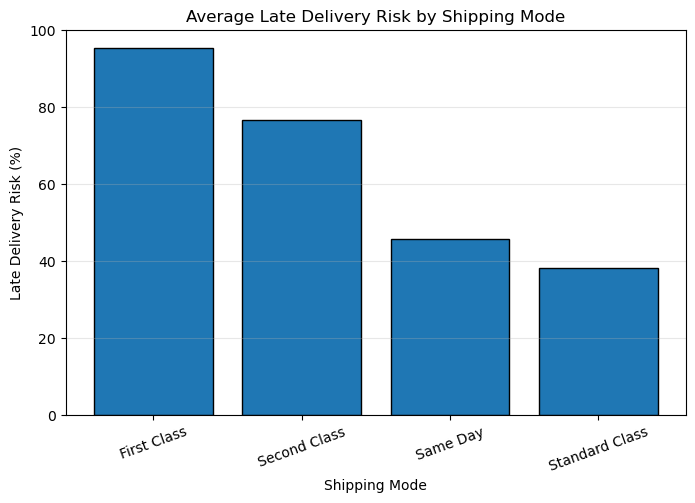

In [119]:
# ==========================================================
# 3.4 Shipping Mode vs Late Delivery Risk
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Cross Tabulation
# ----------------------------------------------------------
shipping_risk = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"]
)

shipping_risk.columns = ["No Risk", "Late Risk"]

print("Shipping Mode vs Late Delivery Risk")
print(shipping_risk)

# ----------------------------------------------------------
# 2. Percentage Distribution
# ----------------------------------------------------------
shipping_percent = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

shipping_percent.columns = ["No Risk (%)", "Late Risk (%)"]

print("\nPercentage Distribution")
print(shipping_percent.round(2))

# ----------------------------------------------------------
# 3. Stacked Bar Chart
# ----------------------------------------------------------
shipping_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Shipping Mode vs Late Delivery Risk")
plt.xlabel("Shipping Mode")
plt.ylabel("Percentage of Orders")

plt.legend(title="Late Delivery Risk")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Average Late Delivery Risk
# ----------------------------------------------------------
late_rate = (
    df
    .groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nLate Delivery Risk Rate (%)")
print(late_rate.round(2))

# ----------------------------------------------------------
# 5. Bar Chart
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    late_rate.index,
    late_rate.values,
    edgecolor="black"
)

plt.title("Average Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Risk (%)")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Observation

The relationship between **Shipping Mode** and **Late Delivery Risk** was analyzed using cross-tabulation, percentage distribution, and comparative visualizations.

**Shipping Mode vs Late Delivery Risk**

| Shipping Mode | No Risk | Late Risk | Late Risk (%) |
|--------------|--------:|----------:|--------------:|
| First Class | 1,301 | 26,513 | 95.32 |
| Second Class | 8,229 | 26,987 | 76.63 |
| Same Day | 5,283 | 4,454 | 45.74 |
| Standard Class | 66,729 | 41,023 | 38.07 |

---

**Visualization Analysis**

- **First Class** exhibits the highest percentage of late deliveries, with **95.32%** of orders classified as late-risk.
- **Second Class** also experiences a high late delivery risk of **76.63%**.
- **Same Day** shipping performs considerably better, with less than half of the shipments classified as late-risk.
- **Standard Class** has the lowest late delivery risk (**38.07%**), indicating the most reliable delivery performance among all shipping modes.

---

#### Business Impact

Shipping mode has a substantial influence on delivery performance.

Despite being a premium shipping option, **First Class** records the highest late delivery risk, suggesting that customer expectations or operational constraints are not being met consistently. In contrast, **Standard Class** demonstrates the best delivery reliability, making it the most dependable shipping option in the current dataset.

These findings indicate that selecting a faster shipping service does not necessarily guarantee better delivery performance. Operational efficiency, fulfillment processes, and logistics planning likely play a more significant role.

---

#### Recommendation

- Investigate the operational processes associated with **First Class** and **Second Class** shipping to identify the causes of frequent delays.
- Review carrier performance, warehouse processing time, and route planning for premium shipping services.
- Promote **Standard Class** as a reliable and cost-effective shipping option where rapid delivery is not essential.
- Monitor late delivery rates for each shipping mode through business dashboards and establish performance targets.
- Conduct further analysis by combining **Shipping Mode**, **Region**, and **Actual Shipping Days** to identify the root causes of delays.

---

#### Key Insights

- Shipping mode has a significant impact on late delivery risk.
- **First Class** records the highest late delivery risk (**95.32%**).
- **Standard Class** is the most reliable shipping mode with the lowest late delivery risk (**38.07%**).
- Faster shipping options do not necessarily result in better delivery performance.
- Improving the operational efficiency of premium shipping services can significantly enhance customer satisfaction and overall supply chain performance.

### 3.5 Customer Segment vs Sales

#### Business Question

**Which customer segment generates the highest sales revenue?**

#### Objective

Analyze the relationship between **Customer Segment** and **Sales** to identify the most valuable customer groups. This analysis helps understand customer purchasing behavior, supports targeted marketing strategies, and enables businesses to prioritize high-value customer segments for revenue growth.

Sales by Customer Segment
                  count        mean      median           sum   min  \
Customer Segment                                                      
Consumer          93504  204.224313  199.919998  1.909579e+07  9.99   
Corporate         54789  203.843962  199.919998  1.116841e+07  9.99   
Home Office       32226  202.337802  199.919998  6.520538e+06  9.99   

                         max  
Customer Segment              
Consumer          1999.98999  
Corporate         1999.98999  
Home Office       1999.98999  

Percentage Contribution
Customer Segment
Consumer       51.91
Corporate      30.36
Home Office    17.73
Name: Sales, dtype: float64


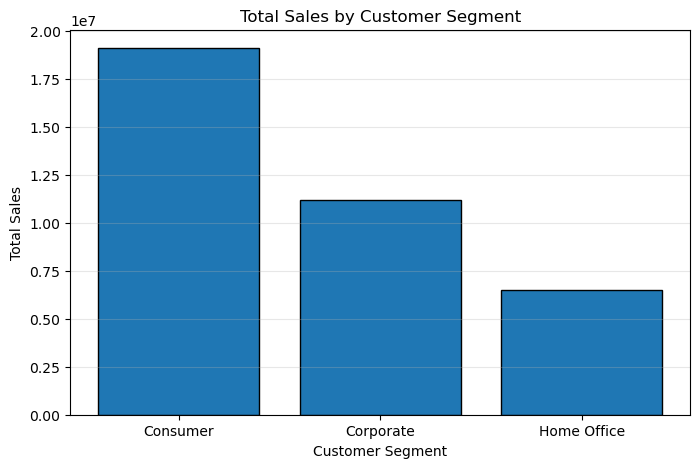

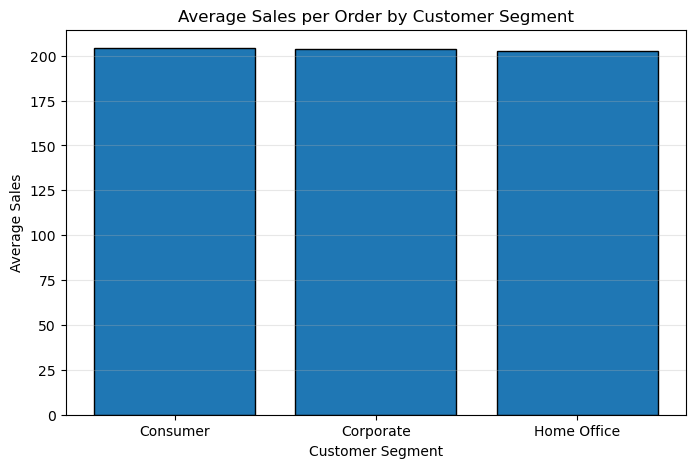

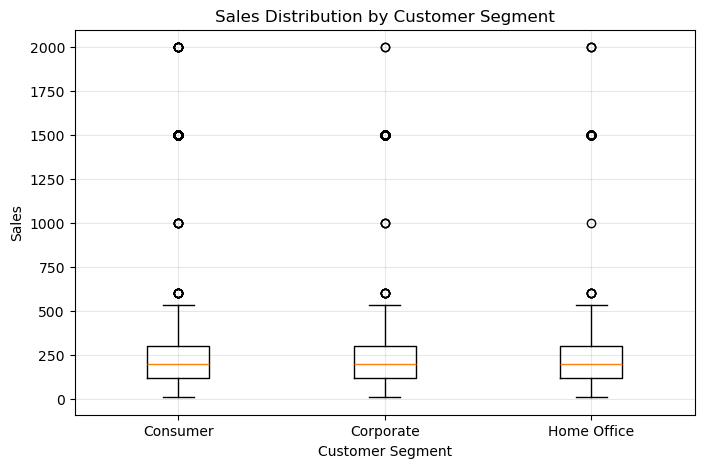

In [120]:
# ==========================================================
# 3.5 Customer Segment vs Sales
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Sales Statistics
# ----------------------------------------------------------
segment_sales = (
    df
    .groupby("Customer Segment")["Sales"]
    .agg(["count", "mean", "median", "sum", "min", "max"])
    .sort_values("sum", ascending=False)
)

print("Sales by Customer Segment")
print(segment_sales)

# ----------------------------------------------------------
# 2. Percentage Contribution to Total Sales
# ----------------------------------------------------------
segment_percent = (
    df.groupby("Customer Segment")["Sales"]
      .sum()
      / df["Sales"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(segment_percent.round(2))

# ----------------------------------------------------------
# 3. Bar Chart (Total Sales)
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    segment_sales.index,
    segment_sales["sum"],
    edgecolor="black"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 4. Average Sales
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(
    segment_sales.index,
    segment_sales["mean"],
    edgecolor="black"
)

plt.title("Average Sales per Order by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# 5. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

groups = [
    df[df["Customer Segment"] == seg]["Sales"]
    for seg in segment_sales.index
]

plt.boxplot(
    groups,
    tick_labels=segment_sales.index
)

plt.title("Sales Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

#### Observation

The relationship between **Customer Segment** and **Sales** was analyzed using group-wise statistics, revenue contribution, and comparative visualizations.

**Sales by Customer Segment**

| Customer Segment | Orders | Average Sales | Median Sales | Total Sales | Contribution (%) |
|-----------------|-------:|--------------:|-------------:|------------:|-----------------:|
| Consumer | 93,504 | 204.22 | 199.92 | 19,095,790 | 51.91 |
| Corporate | 54,789 | 203.84 | 199.92 | 11,168,410 | 30.36 |
| Home Office | 32,226 | 202.34 | 199.92 | 6,520,538 | 17.73 |

---

**Visualization Analysis**

- The **Consumer** segment generates the highest total sales, contributing more than half of the company's revenue.
- The **Corporate** segment contributes approximately one-third of total sales.
- The **Home Office** segment contributes the smallest share of revenue.
- The average sales per order are remarkably consistent across all customer segments, ranging from **202 to 204**.
- The box plots show similar sales distributions and variability across all segments, indicating comparable purchasing behavior.

---

#### Business Impact

The Consumer segment is the company's primary revenue source, accounting for **51.91%** of total sales. However, this higher revenue is mainly driven by a **larger number of orders** rather than higher spending per order.

Since all customer segments have nearly identical average order values, increasing revenue will depend more on **expanding the customer base and increasing purchase frequency** than on raising average transaction values.

This suggests that marketing efforts focused on customer acquisition and retention may yield greater business benefits than strategies aimed solely at increasing basket size.

---

#### Recommendation

- Continue prioritizing the **Consumer** segment, as it contributes the largest share of revenue.
- Develop customer retention and loyalty programs to increase repeat purchases within the Consumer segment.
- Explore opportunities to expand the **Corporate** and **Home Office** customer bases.
- Since average order values are similar across segments, focus on increasing the **number of transactions** through targeted marketing campaigns rather than attempting to increase individual order values.
- Conduct further customer segmentation based on purchasing frequency, profitability, and lifetime value to identify high-value customer groups.

---

#### Key Insights

- The **Consumer** segment contributes the highest total revenue (**51.91%**).
- **Corporate** and **Home Office** contribute **30.36%** and **17.73%** of total sales, respectively.
- Average sales per order are nearly identical across all customer segments (~203–204).
- Revenue differences are primarily driven by **order volume**, not by differences in spending per transaction.
- Increasing customer acquisition and purchase frequency is likely to have a greater impact on revenue growth than increasing average order value.

### 3.6 Product Category vs Sales

#### Business Question

**Which product categories generate the highest sales revenue?**

#### Objective

Analyze the relationship between **Product Category** and **Sales** to identify the highest revenue-generating product categories. This analysis helps understand product performance, optimize inventory management, prioritize marketing efforts, and support strategic business decisions.

Sales by Product Category
                      count         mean       median           sum  \
Category Name                                                         
Fishing               17325   399.980011   399.980011  6.929654e+06   
Cleats                24551   180.519848   179.970001  4.431943e+06   
Camping & Hiking      13729   299.980011   299.980011  4.118426e+06   
Cardio Equipment      12487   295.895187   299.970001  3.694843e+06   
Women's Apparel       21035   149.645828   150.000000  3.147800e+06   
Water Sports          15540   200.376106   199.990005  3.113845e+06   
Men's Footwear        22246   129.990005   129.990005  2.891758e+06   
Indoor/Outdoor Games  19298   149.704317   149.940002  2.888994e+06   
Shop By Sport         10984   119.220870   119.970001  1.309522e+06   
Computers               442  1500.000000  1500.000000  6.630000e+05   
Electronics            3156   117.564843   103.980003  3.710346e+05   
Cameras                 592   452.040008   452.0400

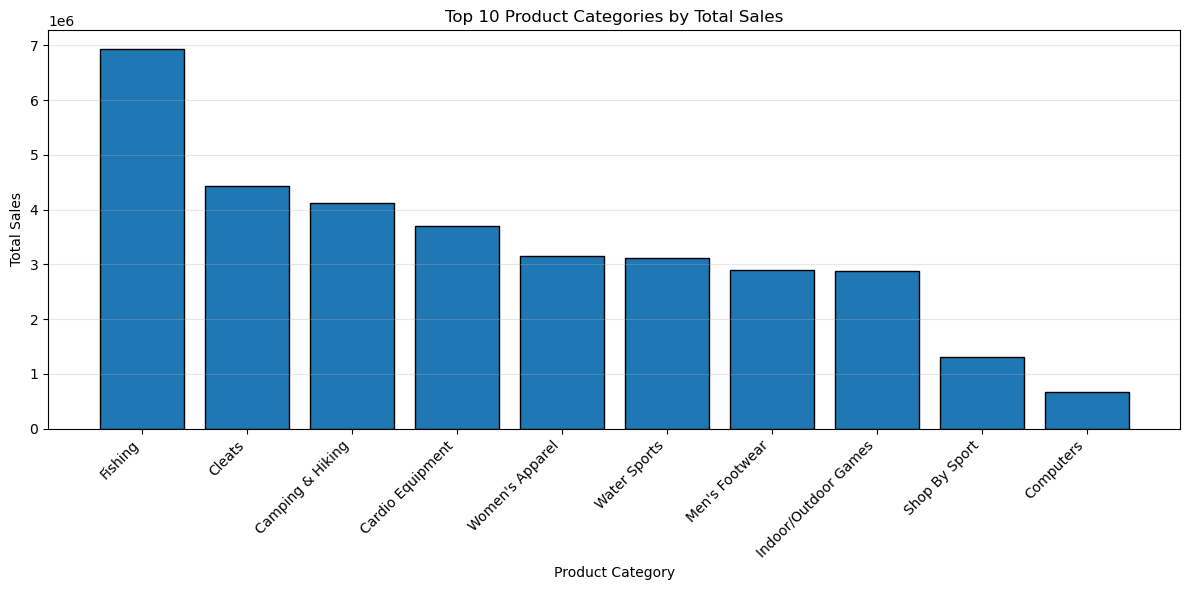

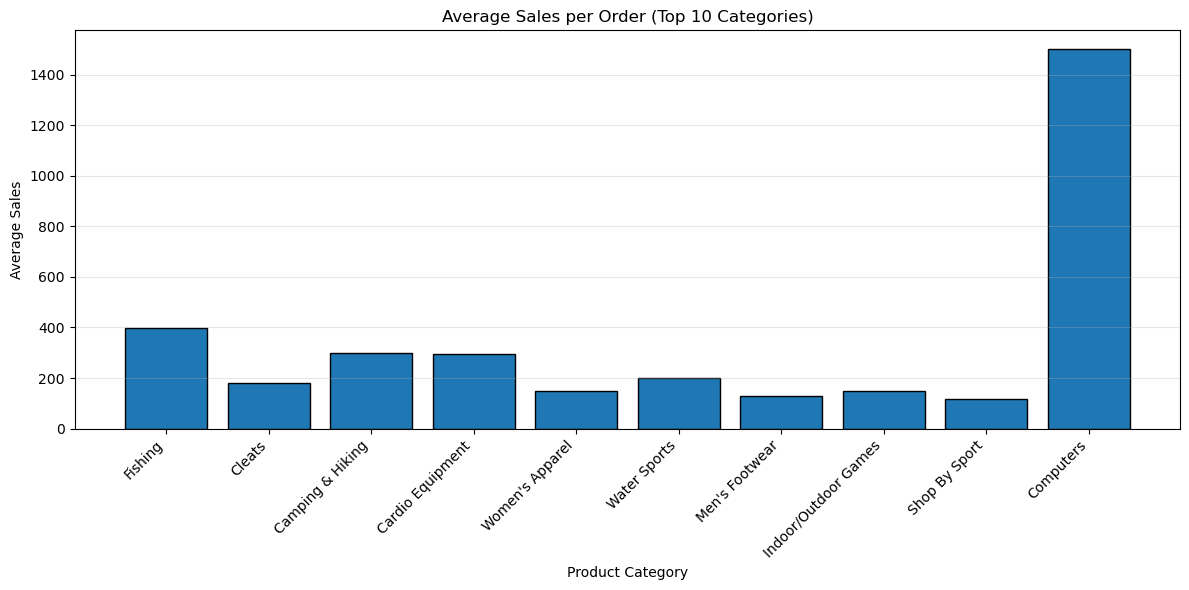

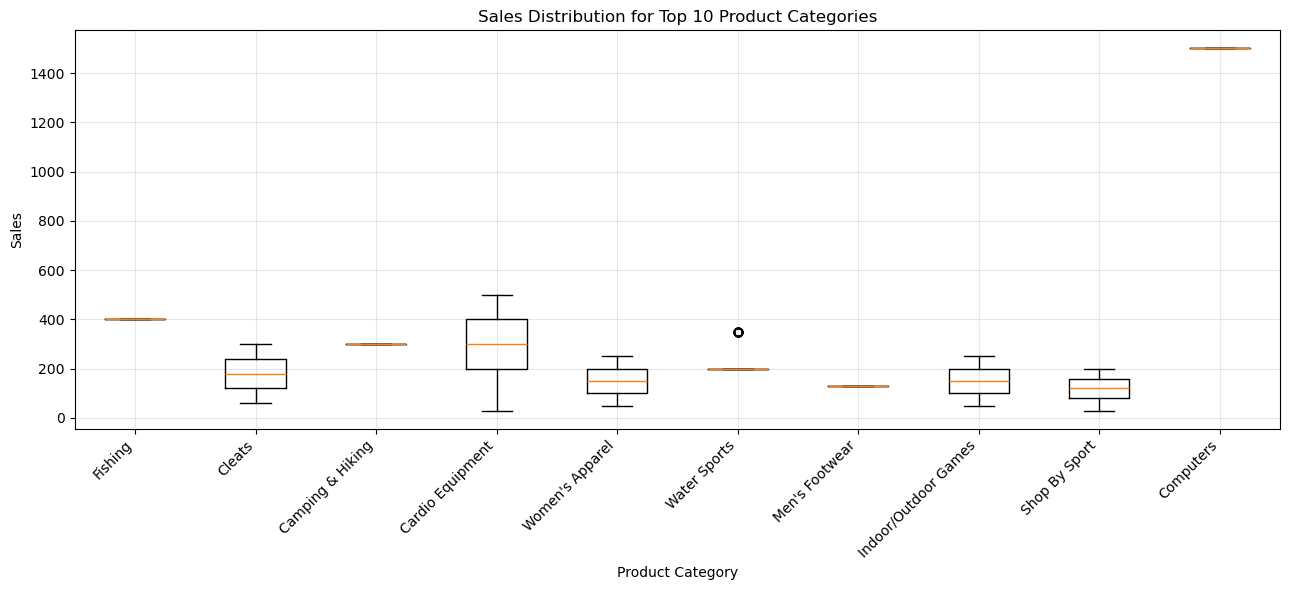

In [121]:
# ==========================================================
# 3.6 Product Category vs Sales
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Sales Statistics
# ----------------------------------------------------------
category_sales = (
    df.groupby("Category Name")["Sales"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_values("sum", ascending=False)
)

print("Sales by Product Category")
print(category_sales)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
category_percent = (
    df.groupby("Category Name")["Sales"]
      .sum()
      / df["Sales"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(category_percent.round(2))

# ----------------------------------------------------------
# 3. Top 10 Categories by Sales
# ----------------------------------------------------------
top10 = category_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["sum"],
    edgecolor="black"
)

plt.title("Top 10 Product Categories by Total Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Average Sales per Order (Top 10)
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["mean"],
    edgecolor="black"
)

plt.title("Average Sales per Order (Top 10 Categories)")
plt.xlabel("Product Category")
plt.ylabel("Average Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Box Plot (Top 10 Categories)
# ----------------------------------------------------------
plt.figure(figsize=(13,6))

groups = [
    df[df["Category Name"] == cat]["Sales"]
    for cat in top10.index
]

plt.boxplot(
    groups,
    tick_labels=top10.index
)

plt.title("Sales Distribution for Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Product Category** and **Sales** was analyzed using category-wise sales statistics, total revenue contribution, and comparative visualizations.

**Sales by Product Category (Top 10)**

| Product Category | Orders | Average Sales | Median Sales | Total Sales |
|------------------|-------:|--------------:|-------------:|------------:|
| Fishing | 17,325 | 399.98 | 399.98 | 6,929,654 |
| Cleats | 24,551 | 180.52 | 179.97 | 4,431,943 |
| Camping & Hiking | 13,729 | 299.98 | 299.98 | 4,118,426 |
| Cardio Equipment | 12,487 | 295.90 | 299.97 | 3,694,843 |
| Women's Apparel | 21,035 | 149.65 | 150.00 | 3,147,800 |
| Water Sports | 15,540 | 200.38 | 199.99 | 3,113,845 |
| Men's Footwear | 22,246 | 129.99 | 129.99 | 2,891,758 |
| Indoor/Outdoor Games | 19,298 | 149.70 | 149.94 | 2,888,994 |
| Shop By Sport | 10,984 | 119.22 | 119.97 | 1,309,522 |
| Computers | 442 | 1,500.00 | 1,500.00 | 663,000 |

---

**Visualization Analysis**

- **Fishing** is the highest revenue-generating product category, contributing approximately **6.93 million** in total sales.
- **Cleats**, **Camping & Hiking**, and **Cardio Equipment** are the next highest-performing categories in terms of total revenue.
- **Computers** have the **highest average sales per order (≈1500)** but contribute relatively less total revenue due to a very small number of orders.
- Categories such as **Fishing** and **Camping & Hiking** exhibit nearly fixed selling prices, resulting in very narrow box plots.
- **Cardio Equipment** shows greater variability in sales, indicating a wider range of product prices.
- Apparel-related categories generally have lower average order values but generate substantial revenue through higher sales volume.

---

#### Business Impact

The analysis shows that business revenue is concentrated within a few major product categories, with **Fishing** serving as the primary revenue driver.

While premium categories like **Computers** generate exceptionally high revenue per transaction, their overall business contribution remains limited because of low sales volume. In contrast, categories such as **Cleats** and **Women's Apparel** achieve high total revenue through frequent purchases rather than expensive products.

These findings highlight the importance of balancing **high-value products** with **high-volume categories** to maximize overall business performance.

---

#### Recommendation

- Maintain adequate inventory levels for high-revenue categories such as **Fishing**, **Cleats**, and **Camping & Hiking** to prevent stock-outs.
- Increase promotional efforts for premium categories like **Computers** to improve sales volume while maintaining high margins.
- Develop targeted marketing strategies for lower-performing categories to diversify revenue sources.
- Bundle lower-priced products with premium products to increase average order value.
- Perform **ABC Analysis** in later phases to classify product categories based on their contribution to total revenue and prioritize inventory management accordingly.

---

#### Key Insights

- **Fishing** is the highest revenue-generating product category (**≈6.93 million**).
- **Computers** have the highest average sales per order (**≈1500**) but contribute relatively less revenue due to low demand.
- Revenue differences across product categories are driven by both **product price** and **sales volume**.
- Categories such as **Cardio Equipment** show greater variability in sales, reflecting a broader product price range.
- Product category analysis provides valuable insights for **inventory planning, pricing strategy, category management, and supply chain optimization**.

### 3.7 Market vs Profit

#### Business Question

**Which markets generate the highest profit, and how does profitability vary across different markets?**

#### Objective

Analyze the relationship between **Market** and **Benefit per Order (Profit)** to identify the most and least profitable markets. Compare total profit, average profit per order, and profit distribution across markets to evaluate regional profitability, identify high-performing and underperforming markets, and support strategic decisions related to market expansion, resource allocation, pricing, and operational improvements.

Profit by Market
              count       mean     median           sum          min  \
Market                                                                 
Europe        50252  23.271571  32.779999  1.169443e+06 -4274.979980   
LATAM         51594  21.772330  32.025000  1.123322e+06 -1286.869995   
Pacific Asia  41260  20.788983  29.180000  8.577534e+05 -3366.000000   
USCA          25799  21.873475  31.490000  5.643138e+05 -1336.369995   
Africa        11614  21.704080  31.495000  2.520712e+05 -1069.150024   

                     max  
Market                    
Europe        911.799988  
LATAM         249.979996  
Pacific Asia  690.900024  
USCA          244.979996  
Africa        244.979996  

Percentage Contribution
Market
Europe          29.48
LATAM           28.32
Pacific Asia    21.62
USCA            14.23
Africa           6.35
Name: Benefit per order, dtype: float64


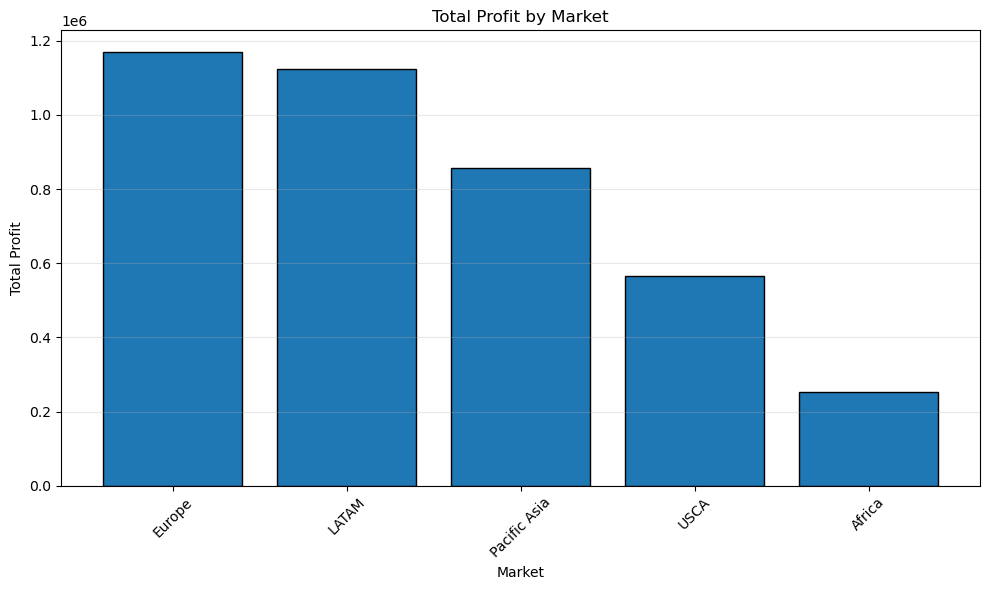

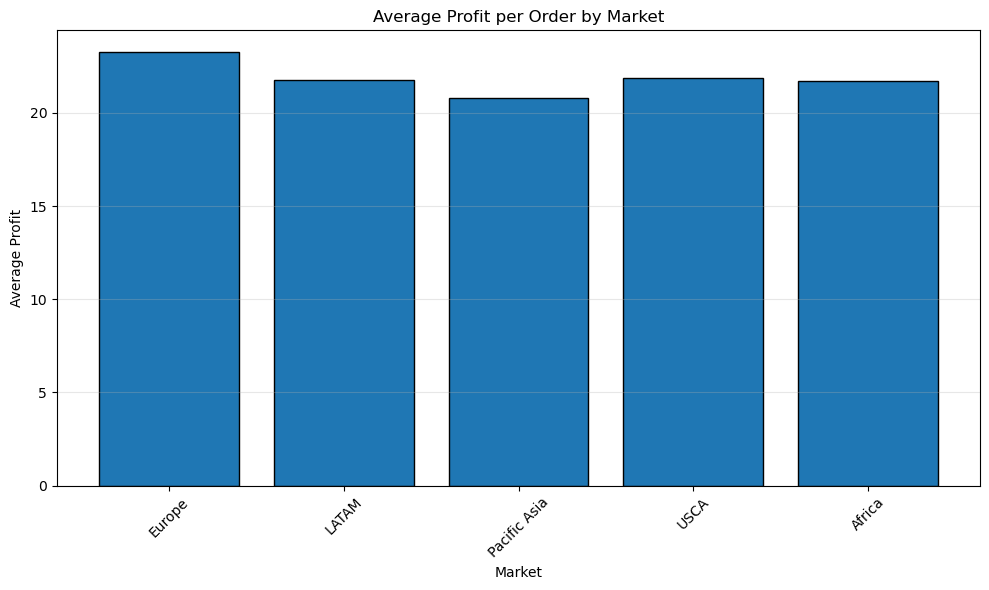

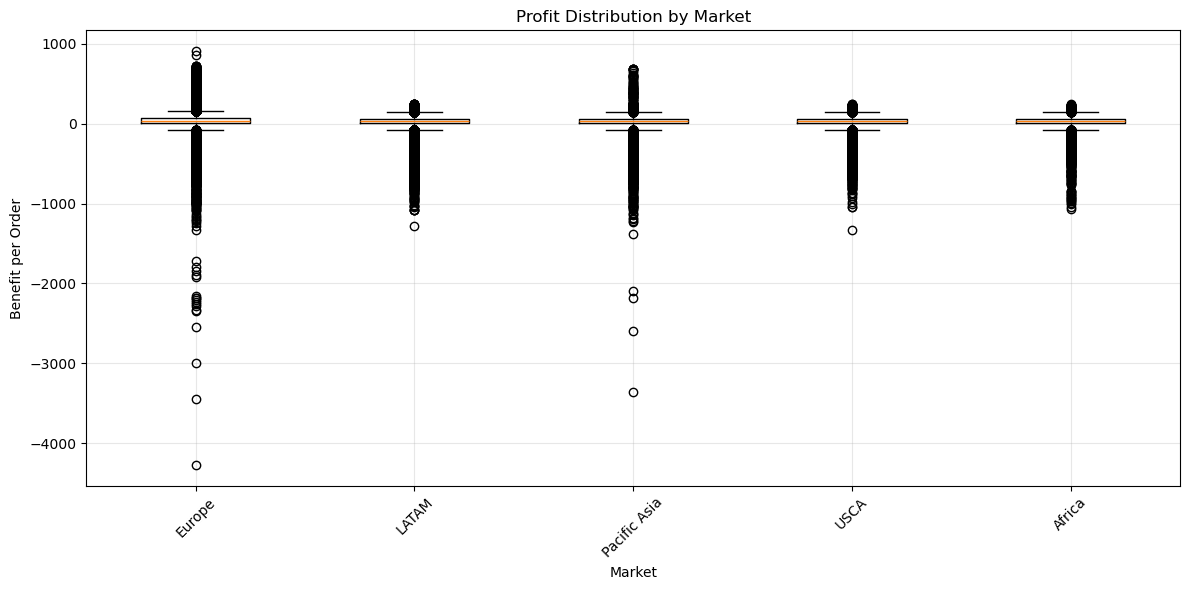

In [122]:
# ==========================================================
# 3.7 Market vs Profit
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Profit Statistics
# ----------------------------------------------------------
market_profit = (
    df.groupby("Market")["Benefit per order"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_values("sum", ascending=False)
)

print("Profit by Market")
print(market_profit)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
market_percent = (
    df.groupby("Market")["Benefit per order"]
      .sum()
      / df["Benefit per order"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(market_percent.round(2))

# ----------------------------------------------------------
# 3. Total Profit by Market
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    market_profit.index,
    market_profit["sum"],
    edgecolor="black"
)

plt.title("Total Profit by Market")
plt.xlabel("Market")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Average Profit per Order
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    market_profit.index,
    market_profit["mean"],
    edgecolor="black"
)

plt.title("Average Profit per Order by Market")
plt.xlabel("Market")
plt.ylabel("Average Profit")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Profit Distribution Across Markets
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

groups = [
    df[df["Market"] == market]["Benefit per order"]
    for market in market_profit.index
]

plt.boxplot(
    groups,
    tick_labels=market_profit.index
)

plt.title("Profit Distribution by Market")
plt.xlabel("Market")
plt.ylabel("Benefit per Order")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Market** and **Benefit per Order (Profit)** was analyzed using group-wise statistics, percentage contribution, and comparative visualizations.

**Profit by Market**

| Market | Orders | Average Profit | Median Profit | Total Profit | Contribution (%) |
|:---|---:|---:|---:|---:|---:|
| Europe | 50,252 | 23.27 | 32.78 | 1,169,443 | 29.48 |
| LATAM | 51,594 | 21.77 | 32.03 | 1,123,322 | 28.32 |
| Pacific Asia | 41,260 | 20.79 | 29.18 | 857,753 | 21.62 |
| USCA | 25,799 | 21.87 | 31.49 | 564,314 | 14.23 |
| Africa | 11,614 | 21.70 | 31.50 | 252,071 | 6.35 |

---

**Visualization Analysis**

- **Europe** contributes the highest share of total profit (**29.48%**), followed closely by **LATAM** (**28.32%**).
- **Pacific Asia** contributes **21.62%** of total profit, making it the third-largest profit-generating market.
- **USCA** and **Africa** contribute smaller shares of total profit, primarily because they contain fewer orders.
- The **average profit per order** is relatively consistent across all markets, ranging from approximately **20.79** to **23.27**.
- Europe records the highest average profit per order, although the difference compared with other markets is modest.
- The box plots show similar profit distributions across markets, with both positive and negative outliers, indicating the presence of exceptionally profitable and loss-making orders in every market.

---

#### Business Impact

Europe and LATAM together contribute nearly **58%** of the total profit, making them the company's strongest performing markets in terms of overall profitability.

Although Europe generates the highest total profit, the similarity in **average profit per order** across all markets suggests that differences in total profit are influenced more by **order volume** than by substantial differences in profit earned from individual orders.

The presence of large negative-profit outliers across multiple markets indicates that certain transactions generate significant losses and should be investigated to improve overall profitability.

---

#### Recommendation

- Continue strengthening operations in **Europe** and **LATAM**, as they contribute the largest share of total profit.
- Identify opportunities to increase sales volume in **Pacific Asia**, which already contributes over one-fifth of total profit.
- Investigate highly negative-profit orders to identify potential causes such as excessive discounts, returns, shipping costs, or operational inefficiencies.
- Expand customer acquisition and market penetration strategies in **USCA** and **Africa** to improve their contribution to overall profitability.
- Perform further profitability analysis by **product category, customer segment, and shipping mode** within each market to identify the most profitable business segments.

---

#### Key Insights

- **Europe** is the highest profit-generating market, contributing **29.48%** of total profit.
- **LATAM** follows closely with **28.32%**, while **Pacific Asia** contributes **21.62%**.
- **USCA** and **Africa** contribute **14.23%** and **6.35%**, respectively.
- Average profit per order remains relatively consistent across all markets (**20.79–23.27**).
- Higher total profit is primarily associated with **higher order volume** rather than substantially higher profit per order.
- Large negative-profit outliers are present across all markets and warrant further investigation.

### 3.8 Region vs Sales

#### Business Question

**Which regions generate the highest sales revenue, and how does sales performance vary across different regions?**

#### Objective

Analyze the relationship between **Region** and **Sales** to identify the highest and lowest revenue-generating regions. This analysis helps evaluate regional business performance, identify high-growth markets, optimize resource allocation, support regional sales strategies, and improve overall supply chain planning.

Sales by Region
                 count        mean      median           sum    min  \
Order Region                                                          
Western Europe   27109  217.432615  199.949997  5.894381e+06   9.99   
Central America  28341  199.912216  199.919998  5.665712e+06   9.99   
South America    14935  198.251182  199.919998  2.960881e+06   9.99   
Northern Europe   9792  220.162444  199.979996  2.155831e+06   9.99   
Southern Europe   9431  217.147579  199.949997  2.047919e+06   9.99   
Oceania          10148  198.724300  199.919998  2.016654e+06   9.99   
Southeast Asia    9539  202.588905  199.919998  1.932496e+06   9.99   
Caribbean         8318  198.487537  199.919998  1.651019e+06   9.99   
West of USA       7993  196.599019  179.970001  1.571416e+06   9.99   
South Asia        7731  200.967652  199.919998  1.553681e+06   9.99   
Eastern Asia      7280  204.176008  193.480003  1.486401e+06   9.99   
East of USA       6915  198.280837  199.919998  1.371112e+06 

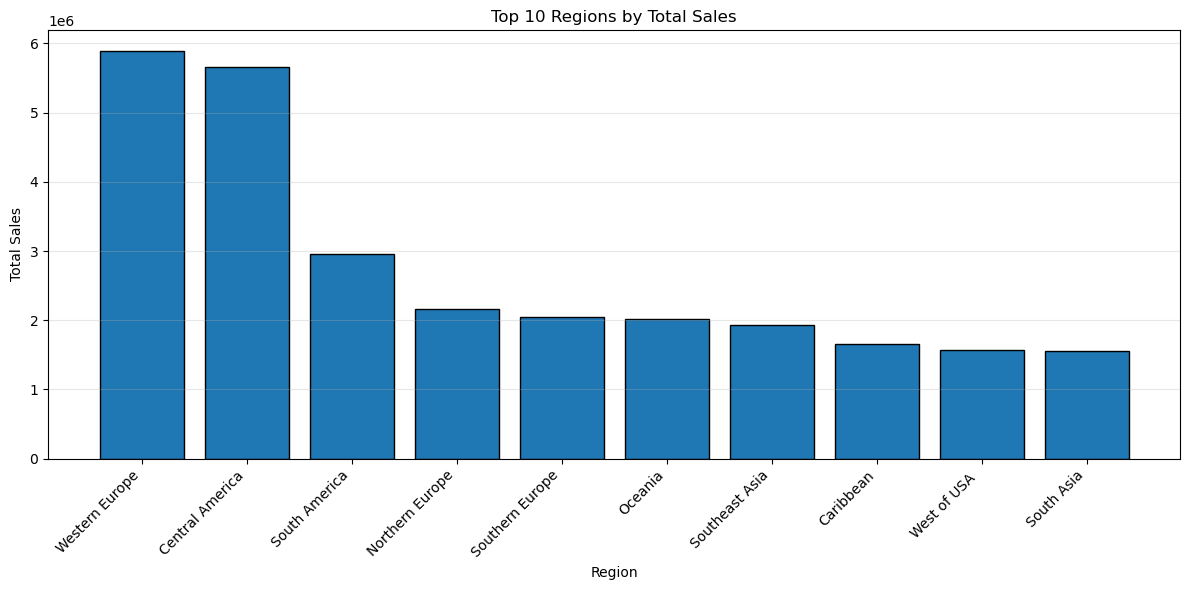

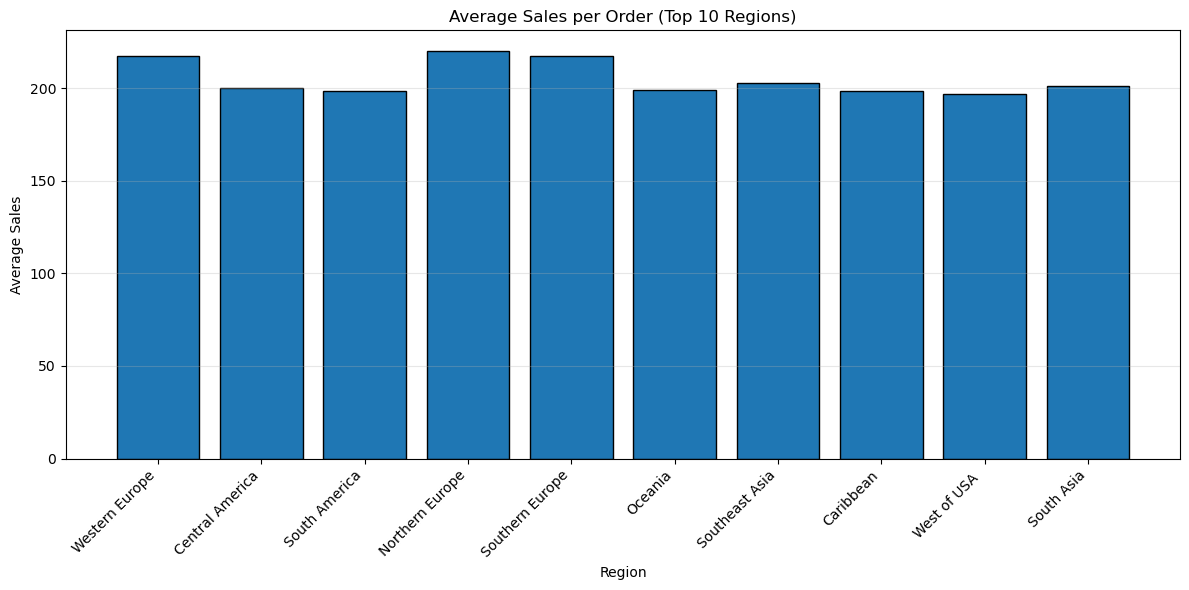

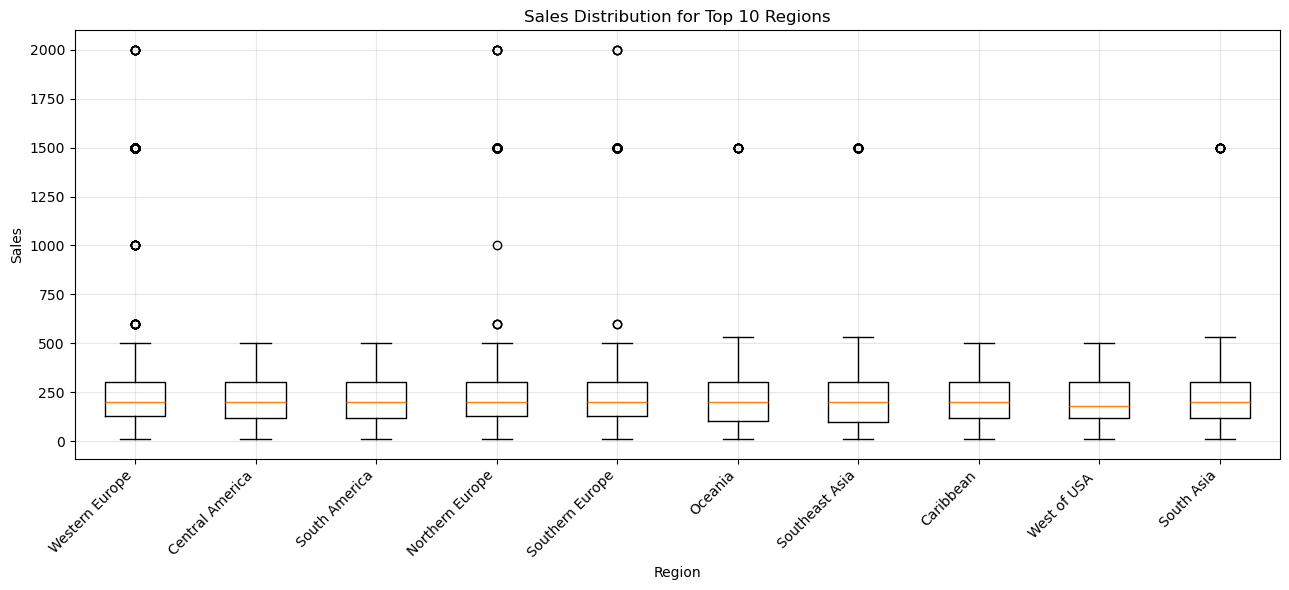

In [123]:
# ==========================================================
# 3.8 Region vs Sales
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Sales Statistics
# ----------------------------------------------------------
region_sales = (
    df.groupby("Order Region")["Sales"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_values("sum", ascending=False)
)

print("Sales by Region")
print(region_sales)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
region_percent = (
    df.groupby("Order Region")["Sales"]
      .sum()
      / df["Sales"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(region_percent.round(2))

# ----------------------------------------------------------
# 3. Top 10 Regions by Total Sales
# ----------------------------------------------------------
top10 = region_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["sum"],
    edgecolor="black"
)

plt.title("Top 10 Regions by Total Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Average Sales per Order (Top 10 Regions)
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["mean"],
    edgecolor="black"
)

plt.title("Average Sales per Order (Top 10 Regions)")
plt.xlabel("Region")
plt.ylabel("Average Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Box Plot (Top 10 Regions)
# ----------------------------------------------------------
plt.figure(figsize=(13,6))

groups = [
    df[df["Order Region"] == region]["Sales"]
    for region in top10.index
]

plt.boxplot(
    groups,
    tick_labels=top10.index
)

plt.title("Sales Distribution for Top 10 Regions")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Order Region** and **Sales** was analyzed using group-wise statistics, percentage contribution, and comparative visualizations.

**Sales by Top 10 Regions**

| Order Region | Orders | Average Sales | Median Sales | Total Sales | Contribution (%) |
|--------------|-------:|--------------:|-------------:|------------:|-----------------:|
| Western Europe | 27,109 | 217.43 | 199.95 | 5,894,381 | 16.02 |
| Central America | 28,341 | 199.91 | 199.92 | 5,665,712 | 15.40 |
| South America | 14,935 | 198.25 | 199.92 | 2,960,881 | 8.05 |
| Northern Europe | 9,792 | 220.16 | 199.98 | 2,155,831 | 5.86 |
| Southern Europe | 9,431 | 217.15 | 199.95 | 2,047,919 | 5.57 |
| Oceania | 10,148 | 198.72 | 199.92 | 2,016,654 | 5.48 |
| Southeast Asia | 9,539 | 202.59 | 199.92 | 1,932,496 | 5.25 |
| Caribbean | 8,318 | 198.49 | 199.92 | 1,651,019 | 4.49 |
| West of USA | 7,993 | 196.60 | 179.97 | 1,571,416 | 4.27 |
| South Asia | 7,731 | 200.97 | 199.92 | 1,553,681 | 4.22 |

---

**Visualization Analysis**

- **Western Europe** generates the highest total sales, contributing **16.02%** of overall revenue.
- **Central America** closely follows with **15.40%**, making these two regions the company's strongest revenue contributors.
- **South America** ranks third, while **Northern Europe** and **Southern Europe** also contribute significantly despite having fewer orders.
- Average sales per order remain relatively consistent across the top regions, ranging from approximately **197 to 220**, indicating similar customer purchasing behavior.
- **Northern Europe** records the highest average sales per order (**220.16**), suggesting customers in this region tend to place slightly higher-value orders.
- The box plots reveal similar sales distributions across most regions, with several high-value outliers, indicating occasional premium purchases but no major differences in overall purchasing patterns.

---

#### Business Impact

Regional revenue differences are driven primarily by **order volume rather than differences in average order value**. While Western Europe and Central America generate the highest total revenue, their average sales per order are only slightly higher than other regions.

This suggests that increasing sales in lower-performing regions will likely depend on **expanding market penetration and increasing the number of customer orders**, rather than focusing solely on increasing order values.

Regions such as **Northern Europe** demonstrate strong average spending despite a smaller customer base, indicating opportunities for targeted expansion and premium product offerings.

---

#### Recommendation

- Continue prioritizing **Western Europe** and **Central America**, as they contribute the largest share of total sales.
- Increase marketing and customer acquisition efforts in regions with moderate sales but strong average order values, such as **Northern Europe**.
- Expand business presence in emerging regions with lower revenue contributions through localized promotions and distribution improvements.
- Monitor high-value sales outliers to identify premium products and customer segments that can be replicated across other regions.
- Perform deeper regional analysis by combining **sales, profit, shipping performance, and customer behavior** to optimize regional supply chain strategies.

---

#### Key Insights

- **Western Europe** is the highest revenue-generating region (**16.02%** of total sales).
- **Central America** contributes **15.40%**, making it the second-largest revenue contributor.
- **Northern Europe** records the highest average sales per order (**220.16**).
- Average order values remain relatively consistent across regions (~197–220).
- Revenue differences are primarily driven by **order volume**, indicating that increasing customer acquisition and transaction frequency offers greater growth potential than increasing average order value alone.

### 3.9 Quantity vs Sales

#### Business Question

**How does the quantity of items ordered influence total sales revenue?**

#### Objective

Analyze the relationship between **Order Item Quantity** and **Sales** to determine whether larger order quantities lead to higher sales revenue. This analysis helps understand bulk purchasing behavior, evaluate how order size impacts revenue generation, support inventory planning, optimize pricing strategies, and identify opportunities to increase sales through quantity-based promotions.

Sales by Order Quantity
                     count        mean      median           sum        min  \
Order Item Quantity                                                           
1                    99134  211.664588  199.990005  2.098316e+07   9.990000   
2                    20315  110.589542  100.000000  2.246627e+06  19.980000   
3                    20350  166.691618  150.000000  3.392174e+06  29.969999   
4                    20335  221.694599  200.000000  4.508160e+06  39.959999   
5                    20385  277.391077  250.000000  5.654617e+06  49.950001   

                            max  
Order Item Quantity              
1                    1999.98999  
2                     200.00000  
3                     300.00000  
4                     400.00000  
5                     500.00000  

Percentage Contribution
Order Item Quantity
1    57.04
2     6.11
3     9.22
4    12.26
5    15.37
Name: Sales, dtype: float64


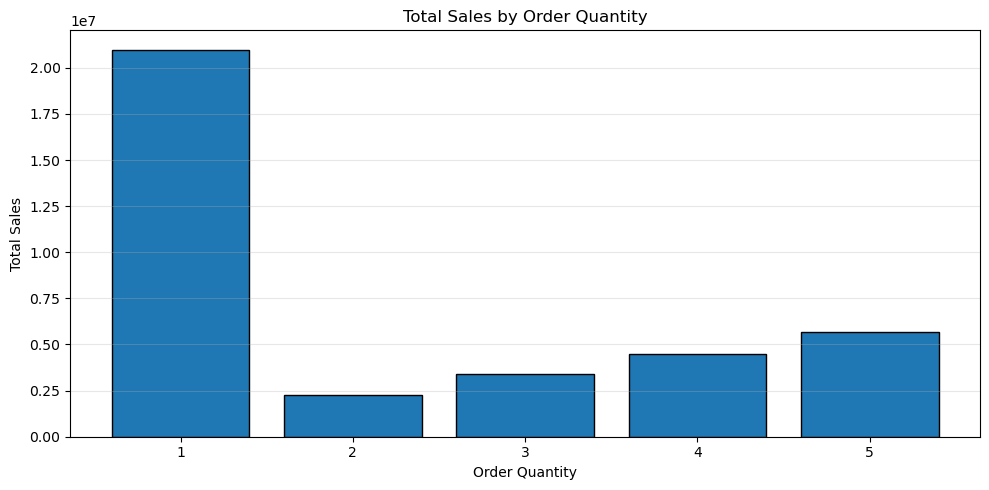

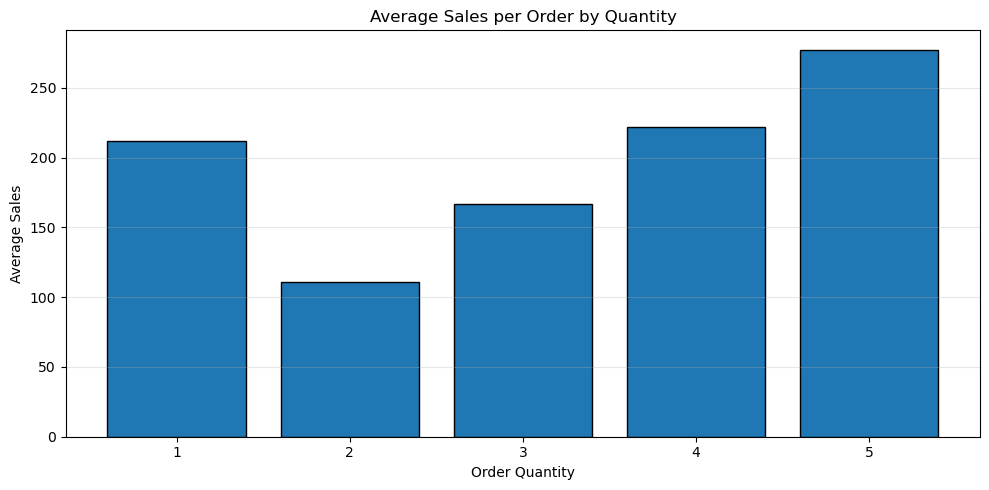

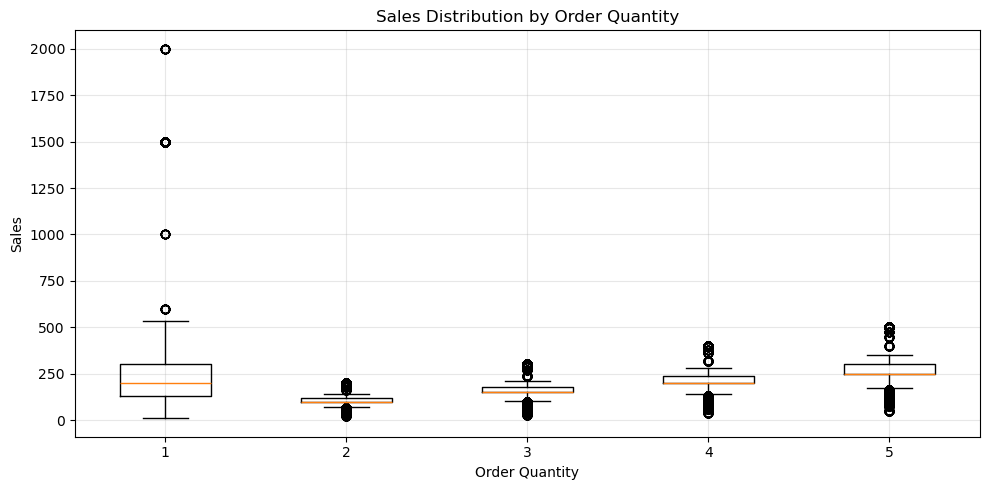

In [124]:
# ==========================================================
# 3.9 Quantity vs Sales
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Sales Statistics
# ----------------------------------------------------------
quantity_sales = (
    df.groupby("Order Item Quantity")["Sales"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_index()
)

print("Sales by Order Quantity")
print(quantity_sales)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
quantity_percent = (
    df.groupby("Order Item Quantity")["Sales"]
      .sum()
      / df["Sales"].sum()
      * 100
)

print("\nPercentage Contribution")
print(quantity_percent.round(2))

# ----------------------------------------------------------
# 3. Total Sales by Quantity
# ----------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    quantity_sales.index.astype(str),
    quantity_sales["sum"],
    edgecolor="black"
)

plt.title("Total Sales by Order Quantity")
plt.xlabel("Order Quantity")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Average Sales per Order
# ----------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    quantity_sales.index.astype(str),
    quantity_sales["mean"],
    edgecolor="black"
)

plt.title("Average Sales per Order by Quantity")
plt.xlabel("Order Quantity")
plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(10,5))

groups = [
    df[df["Order Item Quantity"] == qty]["Sales"]
    for qty in quantity_sales.index
]

plt.boxplot(
    groups,
    tick_labels=quantity_sales.index.astype(str)
)

plt.title("Sales Distribution by Order Quantity")
plt.xlabel("Order Quantity")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Order Item Quantity** and **Sales** was analyzed using group-wise statistics, revenue contribution, and comparative visualizations.

**Sales by Order Quantity**

| Order Quantity | Orders | Average Sales | Median Sales | Total Sales | Contribution (%) |
|---------------:|-------:|--------------:|-------------:|------------:|-----------------:|
| 1 | 99,134 | 211.66 | 199.99 | 20,983,160 | 57.04 |
| 2 | 20,315 | 110.59 | 100.00 | 2,246,627 | 6.11 |
| 3 | 20,350 | 166.69 | 150.00 | 3,392,174 | 9.22 |
| 4 | 20,335 | 221.69 | 200.00 | 4,508,160 | 12.26 |
| 5 | 20,385 | 277.39 | 250.00 | 5,654,617 | 15.37 |

---

**Visualization Analysis**

- Orders with **Quantity = 1** dominate the business, accounting for **57.04%** of total sales and nearly half of all orders.
- The **average sales per order generally increase with higher quantities**, reaching **277.39** for orders containing **5 items**.
- Orders with **Quantity = 2** have the lowest average sales (**110.59**) because they mostly consist of lower-priced products.
- Although Quantity **5** represents far fewer orders than Quantity **1**, it contributes **15.37%** of total sales due to its higher average order value.
- The box plots show that higher order quantities tend to have higher median sales and a gradual upward shift in the sales distribution.
- Quantity **1** exhibits the widest variability and contains the largest number of high-value outliers, indicating that expensive single-item purchases are common.

---

#### Business Impact

The company's revenue is primarily driven by **single-item purchases**, making them the backbone of overall sales performance. However, **larger quantity orders generate substantially higher revenue per transaction**, increasing operational efficiency by generating more revenue from fewer orders.

This suggests that encouraging customers to purchase multiple items can improve revenue without requiring a proportional increase in order volume.

The unusually low average sales for **Quantity = 2** indicate that customers purchasing two items often choose lower-priced products, which may present opportunities for targeted cross-selling or bundle promotions.

---

#### Recommendation

- Continue supporting the large volume of **single-item purchases**, as they generate more than half of total revenue.
- Encourage customers to increase basket size through **bundle offers, quantity discounts, and cross-selling strategies**.
- Investigate why **Quantity = 2** orders have significantly lower average sales and identify opportunities to promote higher-value product combinations.
- Promote premium products and complementary items to increase the proportion of higher-quantity orders.
- Monitor inventory levels for products frequently purchased in larger quantities to avoid stock shortages during demand peaks.

---

#### Key Insights

- **Quantity = 1** contributes the largest share of revenue (**57.04%**) due to its very high order volume.
- Average sales per order generally **increase as order quantity increases**, reaching **277.39** for Quantity **5**.
- **Quantity = 5** contributes **15.37%** of total sales despite representing far fewer orders.
- **Quantity = 2** has the lowest average sales (**110.59**), suggesting lower-priced product combinations.
- Increasing customers' average basket size through cross-selling and bundle promotions could significantly improve revenue while maintaining similar order volumes.
```

### 3.10 Order Status vs Profit

#### Business Question

**How does the profit vary across different order statuses?**

#### Objective

Analyze the relationship between **Order Status** and **Profit (Benefit per Order)** to determine which order statuses generate the highest profitability and which are associated with lower or negative profits.

This analysis helps evaluate the financial performance of different order outcomes, identify operational inefficiencies such as canceled or returned orders, and support decision-making to improve order fulfillment, customer satisfaction, and overall business profitability.

Profit by Order Status
                 count       mean     median           sum          min  \
Order Status                                                              
COMPLETE         59491  22.217407  31.500000  1.321736e+06 -4274.979980   
PENDING_PAYMENT  39832  21.184230  31.610001  8.438102e+05 -3000.000000   
PROCESSING       21902  22.592725  32.029999  4.948259e+05 -3442.500000   
CLOSED           19616  23.347323  31.925000  4.579811e+05 -3366.000000   
PENDING          20227  21.541793  31.430000  4.357259e+05 -2351.250000   
ON_HOLD           9804  21.308960  30.395000  2.089130e+05 -2280.000000   
SUSPECTED_FRAUD   4062  20.959308  30.820000  8.513671e+04 -1222.270020   
CANCELED          3692  20.407809  31.974999  7.534563e+04 -1716.000000   
PAYMENT_REVIEW    1893  22.941780  30.740000  4.342879e+04  -742.450012   

                        max  
Order Status                 
COMPLETE         911.799988  
PENDING_PAYMENT  720.000000  
PROCESSING       683.099976  
C

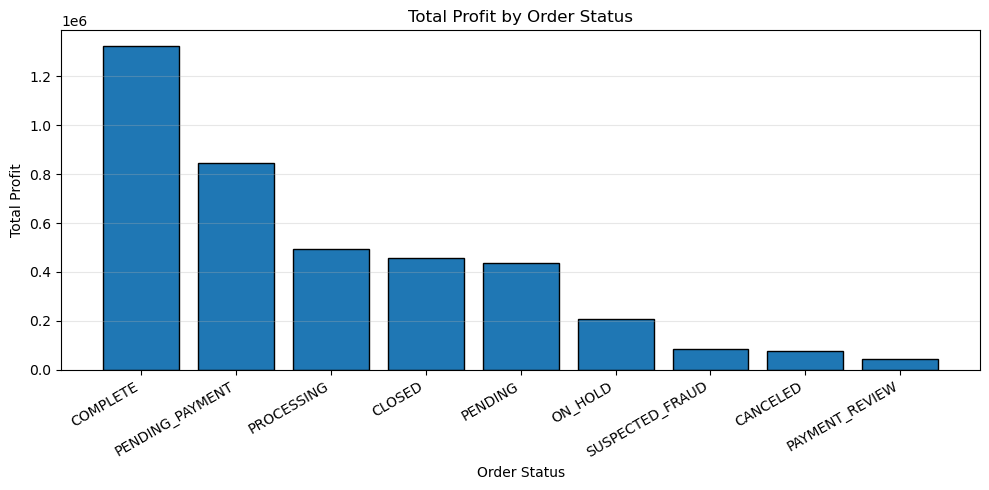

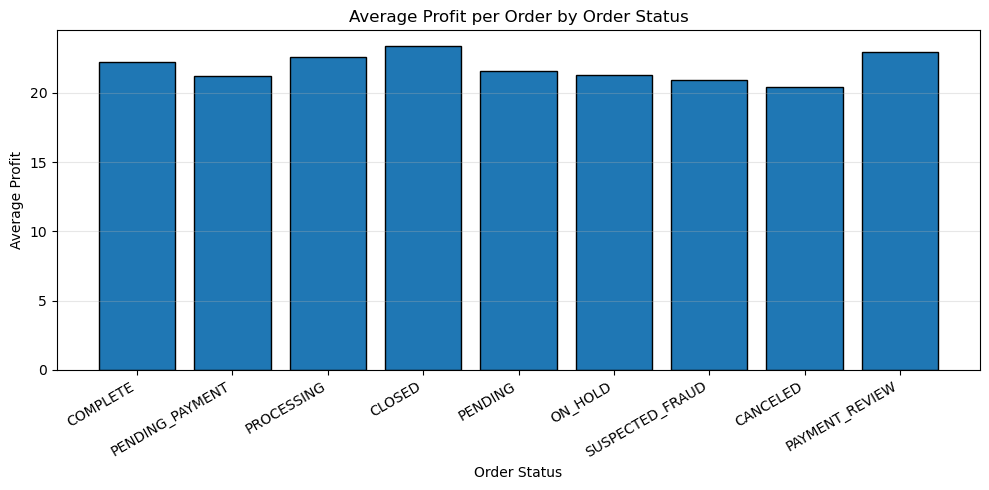

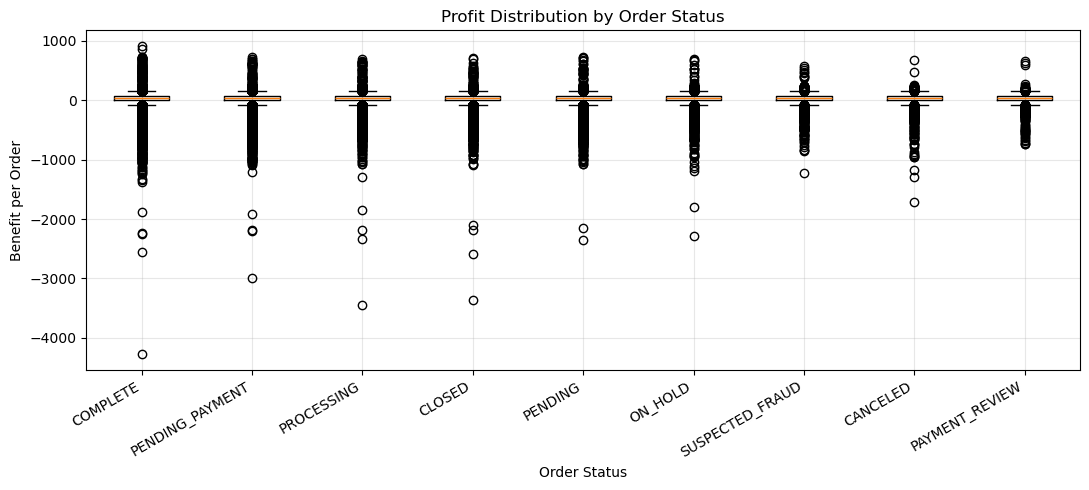

In [125]:
# ==========================================================
# 3.10 Order Status vs Profit
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Profit Statistics
# ----------------------------------------------------------
status_profit = (
    df.groupby("Order Status")["Benefit per order"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_values("sum", ascending=False)
)

print("Profit by Order Status")
print(status_profit)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
status_percent = (
    df.groupby("Order Status")["Benefit per order"]
      .sum()
      / df["Benefit per order"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(status_percent.round(2))

# ----------------------------------------------------------
# 3. Total Profit by Order Status
# ----------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    status_profit.index,
    status_profit["sum"],
    edgecolor="black"
)

plt.title("Total Profit by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Profit")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Average Profit per Order
# ----------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    status_profit.index,
    status_profit["mean"],
    edgecolor="black"
)

plt.title("Average Profit per Order by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Profit")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(11,5))

groups = [
    df[df["Order Status"] == status]["Benefit per order"]
    for status in status_profit.index
]

plt.boxplot(
    groups,
    tick_labels=status_profit.index
)

plt.title("Profit Distribution by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Benefit per Order")

plt.xticks(rotation=30, ha="right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Order Status** and **Benefit per Order (Profit)** was analyzed using group-wise statistics, profit contribution, and comparative visualizations.

**Profit by Order Status**

| Order Status | Orders | Average Profit | Median Profit | Total Profit | Contribution (%) |
|:---|---:|---:|---:|---:|---:|
| COMPLETE | 59,491 | 22.22 | 31.50 | 1,321,736 | 33.37 |
| PENDING_PAYMENT | 39,832 | 21.18 | 31.61 | 843,810 | 21.31 |
| PROCESSING | 21,902 | 22.59 | 32.03 | 494,826 | 12.50 |
| CLOSED | 19,616 | 23.35 | 31.93 | 457,981 | 11.56 |
| PENDING | 20,227 | 21.54 | 31.43 | 435,726 | 11.00 |
| ON_HOLD | 9,804 | 21.31 | 30.40 | 208,913 | 5.28 |
| SUSPECTED_FRAUD | 4,062 | 20.96 | 30.82 | 85,137 | 2.15 |
| CANCELED | 3,692 | 20.41 | 31.97 | 75,346 | 1.90 |
| PAYMENT_REVIEW | 1,893 | 22.94 | 30.74 | 43,429 | 1.09 |

---

**Visualization Analysis**

- **COMPLETE** orders generate the highest total profit, contributing **33.37%** of the company's overall profit.
- **PENDING_PAYMENT** is the second-largest contributor, accounting for **21.31%** of total profit, followed by **PROCESSING (12.50%)**, **CLOSED (11.56%)**, and **PENDING (11.00%)**.
- The **average profit per order** remains fairly consistent across all order statuses, ranging from approximately **20.41** to **23.35**.
- **CLOSED** orders have the highest average profit per order (**23.35**), while **CANCELED** orders record the lowest (**20.41**), although the difference is relatively small.
- The box plots reveal similar profit distributions across all order statuses, with numerous positive and negative outliers indicating the presence of exceptionally profitable as well as highly loss-making orders.
- **COMPLETE** orders exhibit the widest spread and the largest number of extreme outliers due to their substantially higher transaction volume.

---

#### Business Impact

Completed orders contribute the largest share of total profit primarily because they represent the highest number of successfully fulfilled transactions rather than significantly higher profit per order. The relatively similar average profit across different order statuses suggests that **transaction volume** has a much greater influence on total profitability than the order status itself.

The existence of substantial negative-profit outliers across multiple order statuses indicates that certain transactions incur significant losses, highlighting the need to investigate factors such as excessive discounts, returns, shipping costs, or operational inefficiencies.

---

#### Recommendation

- Continue maximizing the conversion of orders into the **COMPLETE** status, as these generate over one-third of the company's total profit.
- Reduce the number of **PENDING**, **ON_HOLD**, and **PENDING_PAYMENT** orders by improving payment processing and operational efficiency.
- Investigate the causes of highly negative-profit transactions across all order statuses to minimize financial losses.
- Strengthen fraud detection and order verification processes to reduce **SUSPECTED_FRAUD** cases while maintaining customer experience.
- Analyze order cancellations to identify opportunities for improving customer satisfaction and increasing the percentage of successfully completed orders.

---

#### Key Insights

- **COMPLETE** orders contribute the highest share of total profit (**33.37%**).
- **PENDING_PAYMENT** contributes **21.31%**, making it the second-largest profit-generating order status.
- Average profit per order is relatively consistent across all order statuses (**20.41–23.35**).
- Differences in total profit are primarily driven by **order volume**, not by large differences in average profit per order.
- Large negative-profit outliers exist across every order status and should be investigated to improve overall profitability.

### 3.11 Delivery Status vs Shipping Time

#### Business Question

**How does shipping time vary across different delivery statuses, and which delivery statuses experience the longest delivery times?**

#### Objective

Analyze the relationship between **Delivery Status** and **Days for Shipping (Real)** to evaluate shipping performance across different delivery outcomes. This analysis helps identify delays, compare delivery efficiency, assess logistics performance, and support decisions for improving delivery operations and customer satisfaction.

Shipping Time by Delivery Status
                   count      mean  median     sum  min  max
Delivery Status                                             
Late delivery      98977  4.089253     5.0  404742    1    6
Shipping canceled   7754  3.476657     3.0   26958    0    6
Shipping on time   32196  2.975214     4.0   95790    0    4
Advance shipping   41592  2.498149     2.0  103903    2    3

Percentage Contribution
Delivery Status
Late delivery        64.10
Advance shipping     16.46
Shipping on time     15.17
Shipping canceled     4.27
Name: Days for shipping (real), dtype: float64


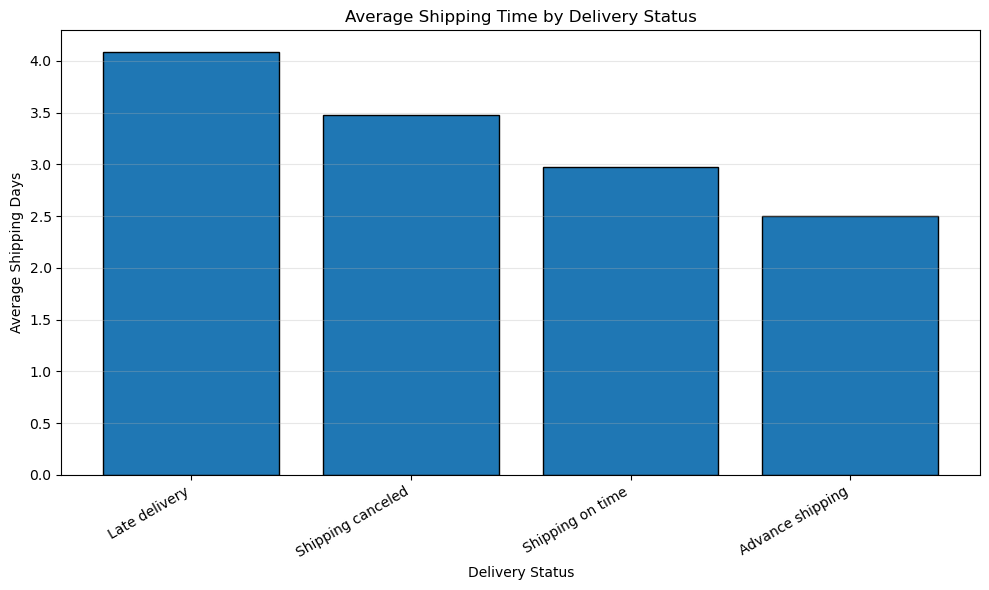

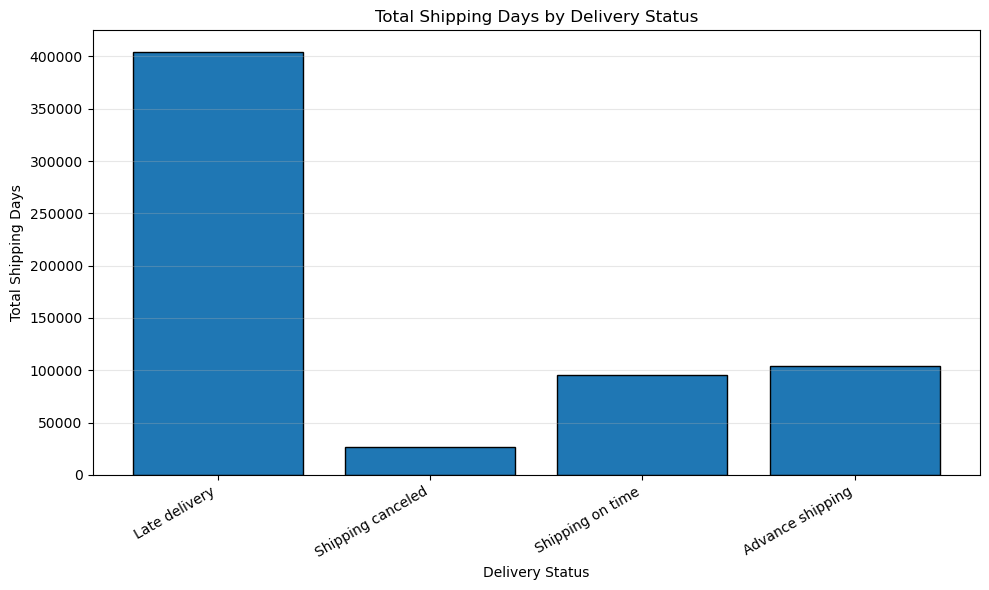

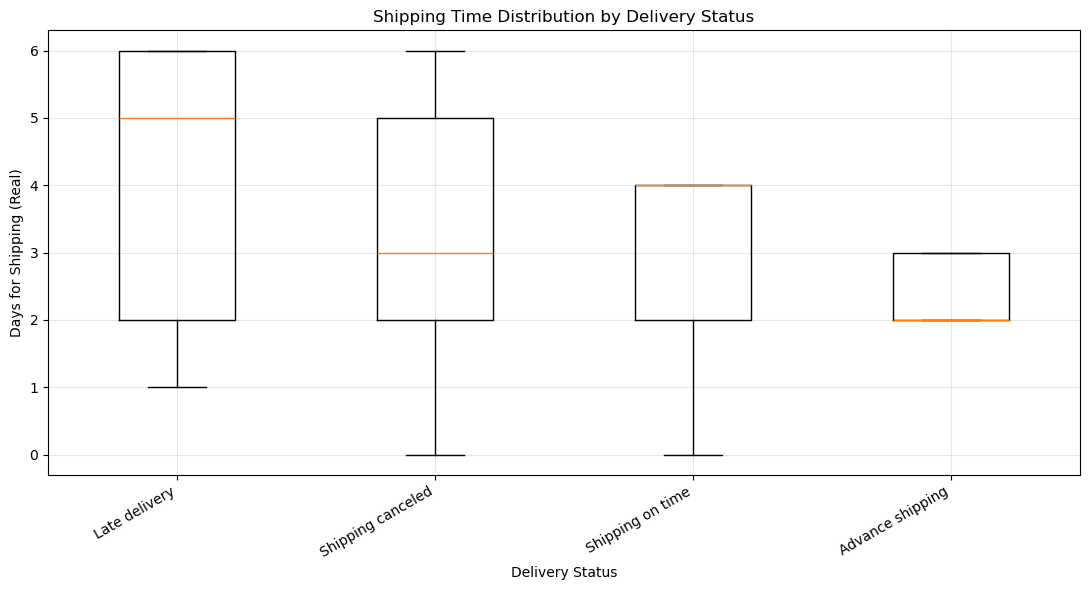

In [126]:
# ==========================================================
# 3.11 Delivery Status vs Shipping Time
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Group-wise Shipping Time Statistics
# ----------------------------------------------------------
delivery_shipping = (
    df.groupby("Delivery Status")["Days for shipping (real)"]
      .agg(["count", "mean", "median", "sum", "min", "max"])
      .sort_values("mean", ascending=False)
)

print("Shipping Time by Delivery Status")
print(delivery_shipping)

# ----------------------------------------------------------
# 2. Percentage Contribution
# ----------------------------------------------------------
delivery_percent = (
    df.groupby("Delivery Status")["Days for shipping (real)"]
      .sum()
      / df["Days for shipping (real)"].sum()
      * 100
).sort_values(ascending=False)

print("\nPercentage Contribution")
print(delivery_percent.round(2))

# ----------------------------------------------------------
# 3. Average Shipping Time
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    delivery_shipping.index,
    delivery_shipping["mean"],
    edgecolor="black"
)

plt.title("Average Shipping Time by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 4. Total Shipping Days
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

plt.bar(
    delivery_shipping.index,
    delivery_shipping["sum"],
    edgecolor="black"
)

plt.title("Total Shipping Days by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Total Shipping Days")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# 5. Box Plot
# ----------------------------------------------------------
plt.figure(figsize=(11,6))

groups = [
    df[df["Delivery Status"] == status]["Days for shipping (real)"]
    for status in delivery_shipping.index
]

plt.boxplot(
    groups,
    tick_labels=delivery_shipping.index
)

plt.title("Shipping Time Distribution by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Days for Shipping (Real)")

plt.xticks(rotation=30, ha="right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Observation

The relationship between **Delivery Status** and **Days for Shipping (Real)** was analyzed using group-wise statistics, percentage contribution, and comparative visualizations.

**Shipping Time by Delivery Status**

| Delivery Status | Orders | Average Shipping Days | Median | Total Shipping Days | Contribution (%) |
|-----------------|-------:|----------------------:|-------:|--------------------:|-----------------:|
| Late delivery | 98,977 | 4.09 | 5.0 | 404,742 | 64.10 |
| Advance shipping | 41,592 | 2.50 | 2.0 | 103,903 | 16.46 |
| Shipping on time | 32,196 | 2.98 | 4.0 | 95,790 | 15.17 |
| Shipping canceled | 7,754 | 3.48 | 3.0 | 26,958 | 4.27 |

---

**Visualization Analysis**

- **Late delivery** orders consistently exhibit the highest average shipping time (**4.09 days**), while **Advance shipping** represents the most efficient logistics with the lowest average (**2.50 days**).
- The **Late delivery** category consumes a massively disproportionate amount of the total shipping days (**404,742 days**). This accounts for **64.10%** of all shipping time across the entire supply chain, driven by both high order volume and longer individual transit times.
- The box plots reveal that **Late delivery** is heavily skewed toward the upper limit (median of 5 days, max of 6), whereas **Advance shipping** is tightly compressed at the lower end (median of 2 days, max of 3). 
- **Shipping on time** serves as the baseline, with a median of 4.0 days and a maximum of 4 days, showing a hard cut-off for what the system considers an acceptable on-time window.

---

#### Business Impact

Actual shipping duration is the primary driver of delivery status. Orders that take 4 or more days to process and ship are overwhelmingly classified as late deliveries. 

Because **64.10%** of total shipping days are tied to late deliveries (encompassing nearly 100,000 individual orders), this represents a massive operational bottleneck. The data shows a very tight margin of error: the difference between an order arriving in advance versus arriving late is separated by an average of just **~1.6 days** of shipping time. Any delays in warehouse processing, packing, or carrier handoff severely jeopardize customer satisfaction and operational efficiency.

---

#### Recommendation

- Investigate the specific operational bottlenecks (e.g., warehouse processing, carrier delays) causing nearly 100,000 orders to take **4 to 6 days** to ship.
- Establish and enforce a strict internal Service Level Agreement (SLA) to keep all warehouse processing and dispatch times below the **3-day mark** to prevent orders from shifting into the "Late delivery" category.
- Analyze the workflows and origins of the 41,592 **Advance shipping** orders to see if their operational efficiencies can be replicated across the broader supply chain.
- Evaluate the **Shipping canceled** orders (which average 3.48 shipping days) to determine if lengthy fulfillment times are actively prompting customers to cancel their purchases.

---

#### Key Insights

- **Late delivery** accounts for the highest average shipping time (**4.09 days**) and dominates the total shipping time (**64.10%**).
- **Advance shipping** is successfully achieved when the average shipping time is kept to roughly **2.50 days**.
- A shipping duration exceeding **3 days** acts as a critical operational threshold where the risk of late delivery spikes significantly.
- Total shipping days are heavily skewed by logistical delays, highlighting a major opportunity for supply chain optimization.

### 3.12 Late Delivery Risk Analysis (Late Delivery Risk vs Shipping Time & Shipping Mode)

#### Business Question

**How do different shipping modes impact the actual shipping time, and how does this relationship drive the risk of late delivery?**

#### Objective

Analyze the combined effect of **Shipping Mode** and **Days for Shipping (Real)** on **Late Delivery Risk**. This analysis aims to identify if specific premium or standard shipping modes fail to meet their expected transit times, leading to a higher proportion of late deliveries. Understanding this helps optimize carrier selection, adjust delivery estimates, and improve overall customer satisfaction.

Average Shipping Time by Mode and Late Delivery Risk
                No Risk (Avg Days)  Late Risk (Avg Days)
Shipping Mode                                           
First Class                   2.00                  2.00
Same Day                      0.04                  1.00
Second Class                  2.33                  4.50
Standard Class                3.07                  5.51

Order Volume by Mode and Late Delivery Risk
                No Risk (Count)  Late Risk (Count)
Shipping Mode                                     
First Class                1301              26513
Same Day                   5283               4454
Second Class               8229              26987
Standard Class            66729              41023


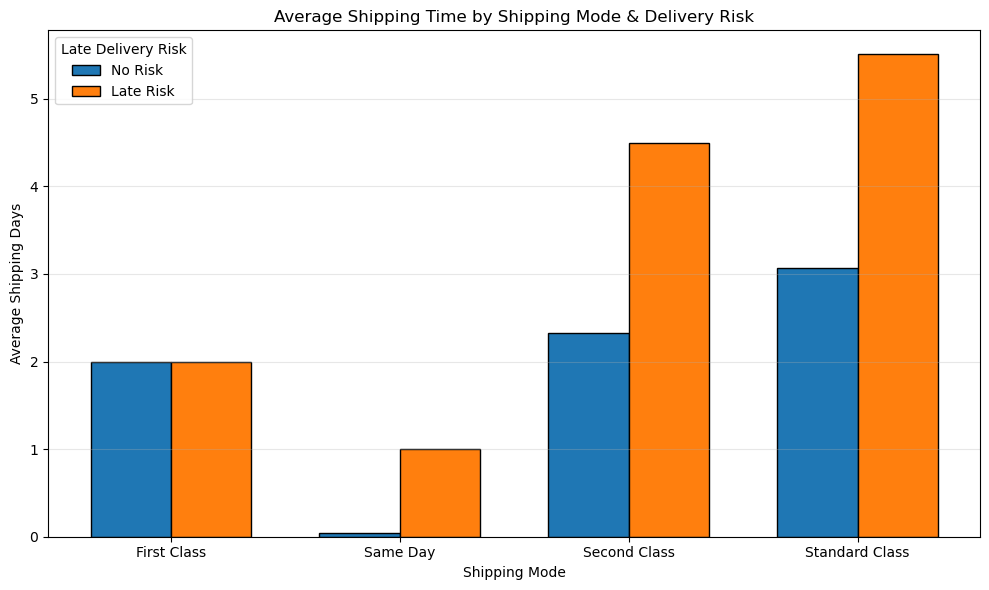

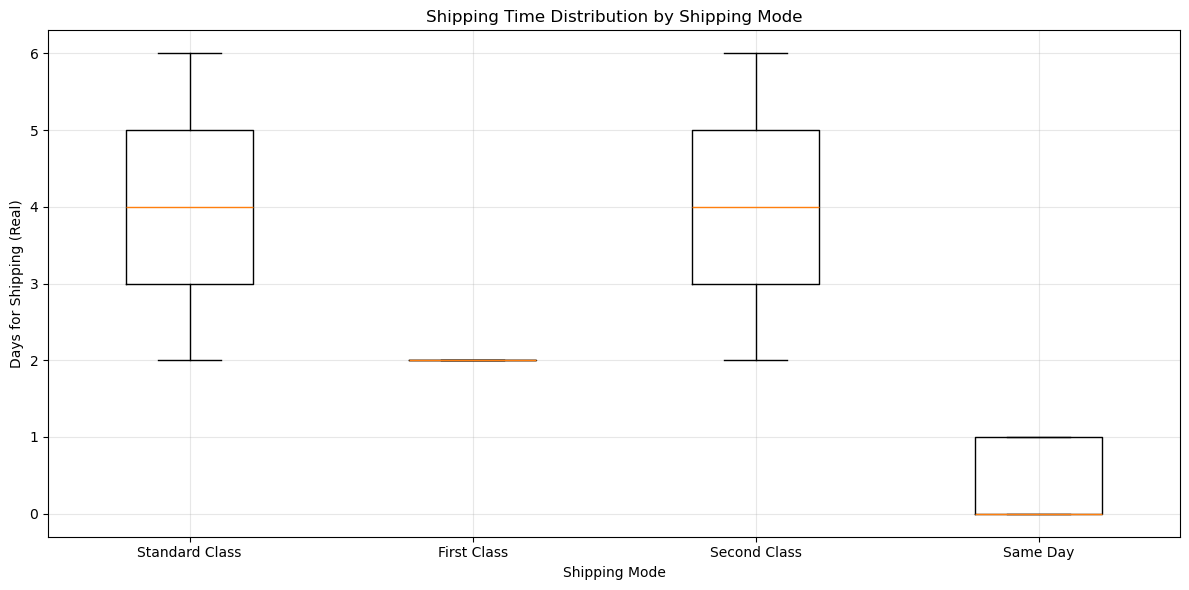

In [127]:
# ==========================================================
# 3.12 Late Delivery Risk vs Shipping Time & Shipping Mode
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# 1. Average Shipping Time by Shipping Mode and Risk
# ----------------------------------------------------------
shipping_risk_time = (
    df.groupby(["Shipping Mode", "Late_delivery_risk"])["Days for shipping (real)"]
      .mean()
      .unstack()
)
shipping_risk_time.columns = ["No Risk (Avg Days)", "Late Risk (Avg Days)"]

print("Average Shipping Time by Mode and Late Delivery Risk")
print(shipping_risk_time.round(2))

# ----------------------------------------------------------
# 2. Group-wise Count Statistics
# ----------------------------------------------------------
shipping_risk_count = (
    df.groupby(["Shipping Mode", "Late_delivery_risk"])["Days for shipping (real)"]
      .count()
      .unstack()
)
shipping_risk_count.columns = ["No Risk (Count)", "Late Risk (Count)"]

print("\nOrder Volume by Mode and Late Delivery Risk")
print(shipping_risk_count)

# ----------------------------------------------------------
# 3. Grouped Bar Chart: Average Shipping Time
# ----------------------------------------------------------
x = np.arange(len(shipping_risk_time.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(
    x - width/2, 
    shipping_risk_time["No Risk (Avg Days)"], 
    width, 
    label="No Risk", 
    edgecolor="black"
)
rects2 = ax.bar(
    x + width/2, 
    shipping_risk_time["Late Risk (Avg Days)"], 
    width, 
    label="Late Risk", 
    edgecolor="black"
)

ax.set_title("Average Shipping Time by Shipping Mode & Delivery Risk")
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Average Shipping Days")
ax.set_xticks(x)
ax.set_xticklabels(shipping_risk_time.index)
ax.legend(title="Late Delivery Risk")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. Box Plot: Shipping Time by Shipping Mode
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

modes = df["Shipping Mode"].unique()
groups = [df[df["Shipping Mode"] == mode]["Days for shipping (real)"] for mode in modes]

plt.boxplot(
    groups,
    tick_labels=modes
)

plt.title("Shipping Time Distribution by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Days for Shipping (Real)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The combined relationship between **Shipping Mode**, **Days for Shipping (Real)**, and **Late Delivery Risk** was analyzed using aggregated cross-tabulations and comparative visualizations. 

**Order Volume and Average Shipping Time by Mode & Risk**

| Shipping Mode | No Risk (Orders) | Late Risk (Orders) | No Risk (Avg Days) | Late Risk (Avg Days) |
|:---|---:|---:|---:|---:|
| First Class | 1,301 | 26,513 | 2.00 | 2.00 |
| Same Day | 5,283 | 4,454 | 0.04 | 1.00 |
| Second Class | 8,229 | 26,987 | 2.33 | 4.50 |
| Standard Class | 66,729 | 41,023 | 3.07 | 5.51 |

---

**Visualization Analysis**

- According to the grouped bar chart in **image_2cfe7a.png**, there is a significant jump in actual shipping days between "No Risk" and "Late Risk" for **Standard Class** (3.07 vs 5.51 days) and **Second Class** (2.33 vs 4.50 days). 
- In contrast, **First Class** shipping exhibits a bizarre trend: both "No Risk" and "Late Risk" orders take an identical average of **2.00 days** to ship. 
- **Same Day** shipping is heavily penalized for minor delays. Orders with no risk average nearly 0 days (0.04), while orders taking just 1.00 day are automatically flagged as a late risk.
- The box plot in **image_2cfe81.png** confirms the distribution spreads. **Standard Class** and **Second Class** have wide variances ranging from 2 to 6 days. However, the **First Class** box plot is compressed into a single line at exactly 2 days, indicating almost zero variance in fulfillment time for this mode.

---

#### Business Impact

This multivariate analysis reveals the root causes of the massive late delivery rates observed in Phase 3. The supply chain fails in two distinctly different ways depending on the shipping mode chosen:

1. **Systemic Process Delays (Standard & Second Class):** Late deliveries in these tiers are caused by genuine fulfillment delays. A late Standard Class order takes roughly **2.4 days longer** to process and ship (5.51 days) than an on-time one (3.07 days). 
2. **Aggressive SLA Failures (First Class & Same Day):** The extreme late delivery rate for First Class (~95%) is *not* caused by chaotic fulfillment times, but by an unrealistic business promise. The logistics network processes First Class orders in exactly 2 days with incredible consistency. However, because the delivery promise is likely 1 day, this perfectly consistent 2-day processing results in nearly every First Class order being marked as late.

Selling premium shipping modes without having the operational capacity (e.g., expedited picking, packing, and carrier handoff) to meet those aggressive timeframes severely damages customer trust and introduces unnecessary operational risk.

---

#### Recommendation

- **Recalibrate First Class Shipping Promises:** Since the supply chain consistently takes exactly 2 days to fulfill First Class orders, the business must either adjust the customer-facing delivery window to reflect a 2-day turnaround, or overhaul warehouse operations to create a genuine 1-day expedited fulfillment lane.
- **Investigate the 2.4-Day Lag in Standard Class:** Identify why over 41,000 Standard Class orders are sitting in the supply chain for an average of 5.51 days. Look into inventory shortages, warehouse staffing constraints, or delayed carrier pickups.
- **Implement Tiered Order Routing:** Ensure that "Same Day" and "First Class" orders bypass standard queues in the warehouse immediately upon receipt. A 1-day delay on a Same Day order is a complete failure of the service customers paid for.

---

#### Key Insights

- **Standard Class** late orders take significantly longer to ship (**5.51 days**) compared to on-time orders (**3.07 days**).
- **First Class** shipping takes exactly **2.00 days** universally, causing a ~95% late delivery rate because the operational output does not match the promised delivery window.
- **Same Day** orders are flagged as late if the shipping duration reaches just **1.00 day**.
- Premium shipping modes fail due to unrealistically tight SLA windows, while standard shipping modes fail due to extended processing delays.

## Phase 4: Multivariate Analysis

### Objective

The objective of this phase is to analyze the simultaneous interaction between three or more business variables. While bivariate analysis identifies direct relationships (e.g., Sales vs. Profit), multivariate analysis uncovers complex hidden dependencies—such as how discounts impact profitability differently across various product categories, or how shipping performance varies across global regions. This phase provides the deep, nuanced insights required for highly targeted business strategies.

**Business Questions & Relationships Analyzed**

Based on the findings from previous phases, the following critical multivariate questions will be explored:

- **4.1 🌍 Logistics & Geography:** *How do Shipping Mode and Order Region jointly affect Late Delivery Risk?*
  - **Variables:** `Shipping Mode` + `Order Region` + `Late Delivery Risk`
  - **Why:** To determine if premium shipping modes (like First Class) fail universally, or if logistical bottlenecks are isolated to specific global markets.

- **4.2 📦 Order Size & Fulfillment:** *What is the combined effect of Shipping Mode and Order Quantity on Actual Shipping Days?*
  - **Variables:** `Shipping Mode` + `Order Item Quantity` + `Days for shipping (real)`
  - **Why:** To identify if the warehouse struggles to process bulk orders fast enough to meet the tight deadlines of expedited shipping modes.

- **4.3 🏷️ Pricing & Profitability:** *How does Order Item Discount impact Profit across different Product Categories?*
  - **Variables:** `Order Item Discount` + `Category Name` + `Benefit per Order`
  - **Why:** To discover which product categories can absorb heavy discounts while remaining profitable, and which categories generate significant financial losses when discounted.

- **4.4 🎯 Regional Product Strategy:** *Which Product Categories drive the highest Sales and Profit in specific Markets?*
  - **Variables:** `Market` + `Category Name` + `Sales` (or `Benefit per Order`)
  - **Why:** To tailor regional marketing and inventory placement.

- **4.5 👥 Customer Purchasing Behavior:** *What is the relationship between Customer Segment, Order Item Quantity, and Sales?*
  - **Variables:** `Customer Segment` + `Order Item Quantity` + `Sales`
  - **Why:** To identify which customer segments are making high-value bulk purchases, allowing for highly targeted cross-selling and bundling campaigns.

- **4.6 📊 Comprehensive Profit Drivers:** *What is the combined influence of Sales, Discount, Quantity, and Price on Profit?*
  - **Variables:** `Sales` + `Order Item Discount` + `Order Item Product Price` + `Benefit per Order`
  - **Why:** To untangle confounding variables and isolate the true mathematical drivers of bottom-line profitability.

**Analyses Performed**

Depending on the combination of categorical and numerical variables, the following analytical and visual techniques will be applied:

- Multi-way Cross-tabulation & Pivot Tables
- Correlation Heatmaps (for specific sub-groups)
- Grouped and Stacked Bar Charts
- Faceted Grids (Subplots by category/region)
- Scatter Plots with Hue and Size encoding (Bubble Charts)
- Multivariate Statistical Summaries

**Outcome**

Deep, actionable insights that account for multiple interacting business dimensions. This phase bridges the gap between basic exploratory analysis and advanced predictive modeling, delivering specific, data-driven recommendations for pricing optimization, inventory allocation, and targeted logistics improvements.

### 4.1 Logistics & Geography: Shipping Mode vs Order Region vs Late Delivery Risk

#### Business Question

**How do Shipping Mode and Order Region jointly affect Late Delivery Risk?**

#### Objective

Analyze the combined effect of **Shipping Mode** and **Order Region** on **Late Delivery Risk** to determine if premium shipping modes fail universally across the globe, or if logistical bottlenecks are isolated to specific global markets. This helps pinpoint geographical supply chain weaknesses and optimize regional shipping strategies.

Late Delivery Risk (%) by Region and Shipping Mode (First 10 Rows):
Shipping Mode    First Class  Same Day  Second Class  Standard Class
Order Region                                                        
Canada                 92.39     21.21         75.30           28.82
Caribbean              94.89     49.67         78.30           35.34
Central Africa         92.67     30.38         81.14           42.86
Central America        95.50     45.75         75.00           38.53
Central Asia          100.00     20.31         86.32           41.75
East Africa            98.93     41.84         77.07           39.48
East of USA            96.42     47.85         74.80           39.78
Eastern Asia           94.82     47.54         79.37           37.45
Eastern Europe         96.05     35.96         74.87           39.27
North Africa           97.12     55.96         78.28           36.11


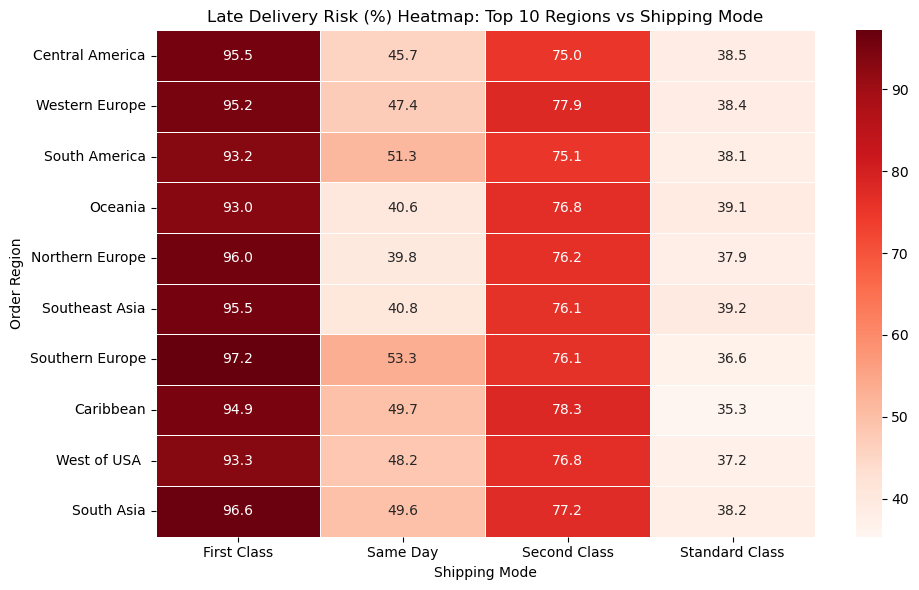

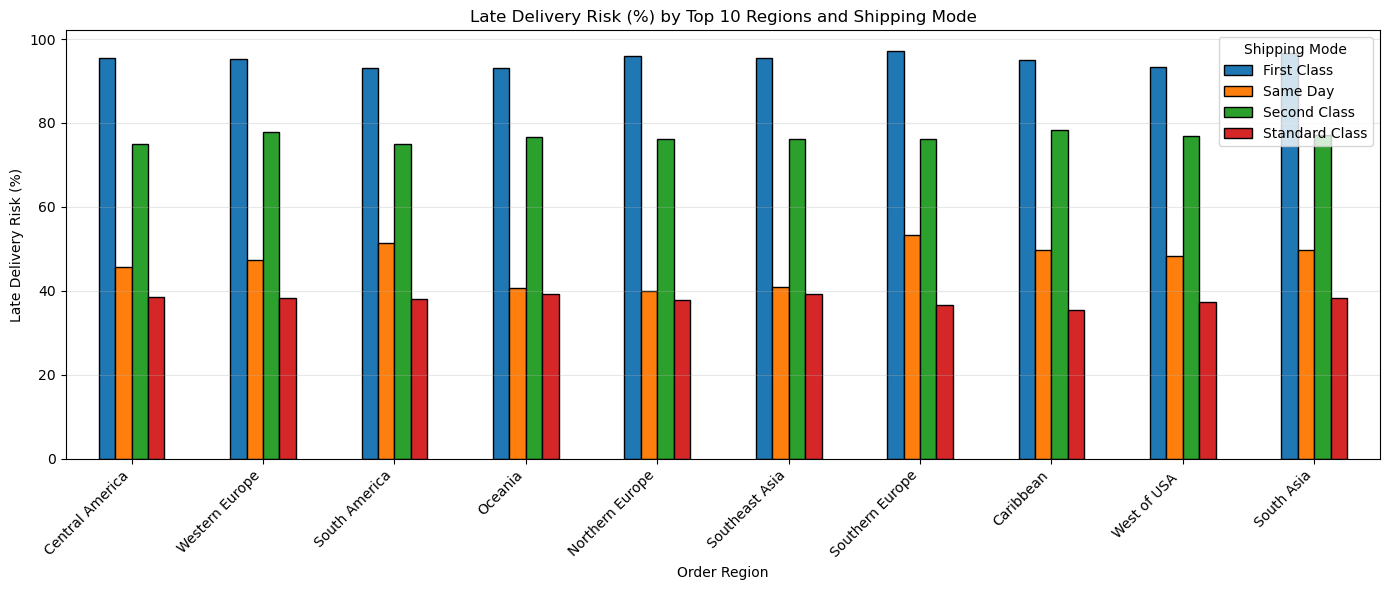

In [128]:
# ==========================================================
# 4.1 Shipping Mode vs Order Region vs Late Delivery Risk
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Calculate Late Delivery Risk (%) by Region & Shipping Mode
# ----------------------------------------------------------
regional_shipping_risk = (
    df.groupby(["Order Region", "Shipping Mode"])["Late_delivery_risk"]
      .mean()
      .unstack() * 100
)

print("Late Delivery Risk (%) by Region and Shipping Mode (First 10 Rows):")
print(regional_shipping_risk.head(10).round(2))

# ----------------------------------------------------------
# 2. Filter for Top 10 Regions by Order Volume for cleaner charts
# ----------------------------------------------------------
top_10_regions = df["Order Region"].value_counts().head(10).index
top_regional_risk = regional_shipping_risk.loc[top_10_regions]

# ----------------------------------------------------------
# 3. Heatmap Visualization (Best for 3+ variables)
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(
    top_regional_risk, 
    annot=True, 
    fmt=".1f", 
    cmap="Reds", 
    linewidths=0.5
)
plt.title("Late Delivery Risk (%) Heatmap: Top 10 Regions vs Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Order Region")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. Grouped Bar Chart
# ----------------------------------------------------------
top_regional_risk.plot(
    kind="bar", 
    figsize=(14, 6), 
    edgecolor="black"
)
plt.title("Late Delivery Risk (%) by Top 10 Regions and Shipping Mode")
plt.xlabel("Order Region")
plt.ylabel("Late Delivery Risk (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Shipping Mode")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The combined relationship between **Order Region**, **Shipping Mode**, and **Late Delivery Risk** was analyzed using regional cross-tabulations, a heatmap, and grouped bar charts.

**Late Delivery Risk (%) by Top Regions and Shipping Mode**

| Order Region | First Class | Same Day | Second Class | Standard Class |
|:---|---:|---:|---:|---:|
| Central America | 95.50% | 45.75% | 75.00% | 38.53% |
| Western Europe | 95.20% | 47.40% | 77.90% | 38.40% |
| South America | 93.20% | 51.30% | 75.10% | 38.10% |
| Oceania | 93.00% | 40.60% | 76.80% | 39.10% |
| Northern Europe | 96.00% | 39.80% | 76.20% | 37.90% |
| Southeast Asia | 95.50% | 40.80% | 76.10% | 39.20% |

---

**Visualization Analysis**

- The heatmap (image_b7909c.png) clearly displays a uniform, dark red vertical band for **First Class** shipping across all top regions, indicating a near-guaranteed late delivery risk regardless of geography.
- **Second Class** shipping also exhibits uniformly high risk across all regions, consistently hovering between 74% and 86%.
- **Standard Class** is universally the safest option, maintaining the lowest late delivery risk across every single global region (typically in the high 30% range).
- The grouped bar chart (image_b79345.png) highlights that **Same Day** shipping experiences the highest regional volatility. While it performs relatively well in regions like Canada (21.21%) and Central Asia (20.31%), it struggles significantly in North Africa (55.96%) and Southern Europe (53.30%).

---

#### Business Impact

The extreme late delivery rates for premium shipping modes are a **systemic, global operational failure**, rather than localized regional bottlenecks. Because First Class shipping fails at a rate of 93% to 100% across *every* market, the root cause lies within internal supply chain processes (e.g., universal warehouse processing delays, unrealistic SLAs) rather than external factors like regional customs, local carrier networks, or geographical distance.

Conversely, the regional variance in **Same Day** shipping indicates that this specific service heavily depends on localized infrastructure. The logistics network has successfully figured out Same Day fulfillment in certain markets (like Central Asia) but lacks the operational capability to execute it in others (like Southern Europe). 

---

#### Recommendation

- **Global Overhaul of First Class SLAs:** Immediately suspend or adjust customer-facing delivery promises for First Class and Second Class shipping globally until internal warehouse processing speeds are drastically reduced. 
- **Standardize Standard Class:** Continue promoting Standard Class as the default, most reliable shipping option, as it proves resilient across all global markets.
- **Audit Underperforming Same Day Markets:** Investigate the operational differences between highly successful Same Day markets (e.g., Canada, Central Asia) and failing ones (e.g., North Africa, Southern Europe). Restrict the Same Day shipping option in underperforming regions until local logistics infrastructure improves.

---

#### Key Insights

- **First Class** shipping has a near-100% late delivery risk universally, regardless of the destination region.
- Premium shipping failures are caused by centralized, systemic supply chain issues, not localized geographical bottlenecks.
- **Standard Class** is the most robust and reliable shipping mode globally (averaging ~38% risk).
- **Same Day** shipping is the only mode highly sensitive to regional infrastructure, showing massive performance gaps between different markets.

### 4.2 Order Size & Fulfillment: Shipping Mode vs Order Quantity vs Actual Shipping Days

#### Business Question

**What is the combined effect of Shipping Mode and Order Quantity on Actual Shipping Days?**

#### Objective

Analyze the interaction between **Shipping Mode**, **Order Item Quantity**, and **Days for Shipping (Real)** to identify if bulk orders (quantities 4 or 5) cause fulfillment delays, particularly for expedited shipping modes. This helps determine if warehouse picking and packing processes for multi-item orders hinder the ability to meet premium shipping deadlines.

Average Shipping Days by Shipping Mode and Order Quantity:
Order Item Quantity     1     2     3     4     5
Shipping Mode                                    
First Class          2.00  2.00  2.00  2.00  2.00
Same Day             0.48  0.49  0.47  0.47  0.47
Second Class         3.98  3.98  3.97  3.99  4.05
Standard Class       3.99  4.01  4.00  4.00  3.98


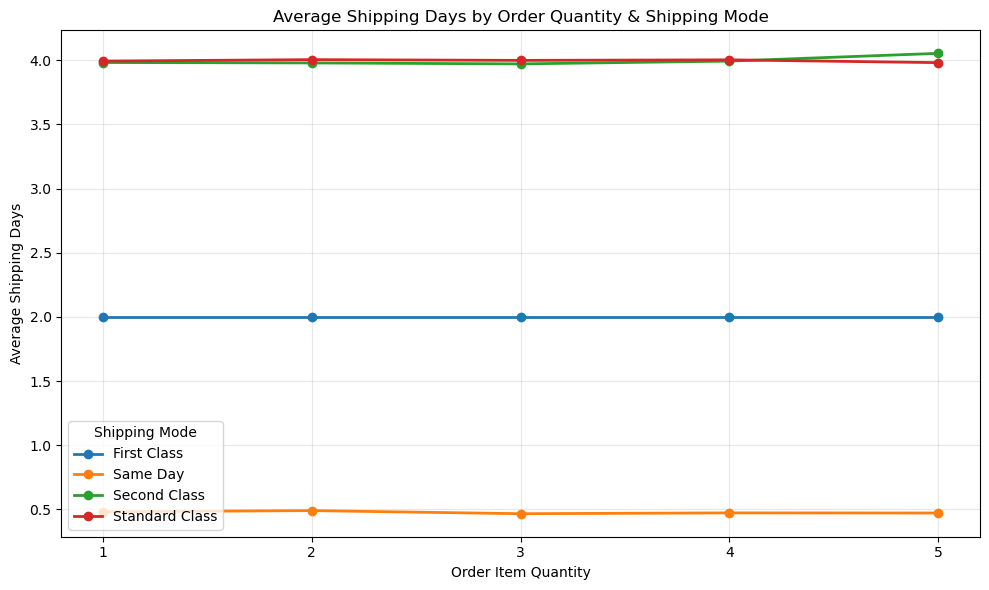

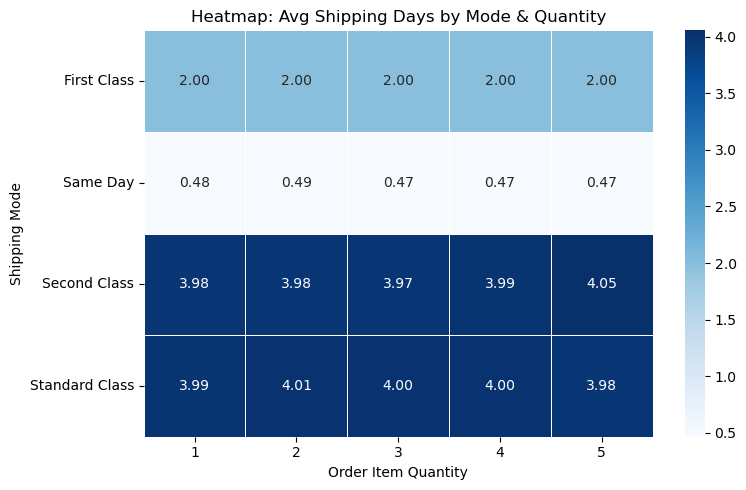

In [129]:
# ==========================================================
# 4.2 Shipping Mode vs Order Quantity vs Actual Shipping Days
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Average Shipping Days by Shipping Mode and Order Quantity
# ----------------------------------------------------------
qty_shipping_time = (
    df.groupby(["Shipping Mode", "Order Item Quantity"])["Days for shipping (real)"]
      .mean()
      .unstack()
)

print("Average Shipping Days by Shipping Mode and Order Quantity:")
print(qty_shipping_time.round(2))

# ----------------------------------------------------------
# 2. Line Chart: Average Shipping Days by Quantity & Mode
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

for mode in qty_shipping_time.index:
    plt.plot(
        qty_shipping_time.columns, 
        qty_shipping_time.loc[mode], 
        marker='o', 
        linewidth=2,
        label=mode
    )

plt.title("Average Shipping Days by Order Quantity & Shipping Mode")
plt.xlabel("Order Item Quantity")
plt.ylabel("Average Shipping Days")
plt.xticks(qty_shipping_time.columns)
plt.legend(title="Shipping Mode")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3. Heatmap Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.heatmap(
    qty_shipping_time, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    linewidths=0.5
)
plt.title("Heatmap: Avg Shipping Days by Mode & Quantity")
plt.xlabel("Order Item Quantity")
plt.ylabel("Shipping Mode")
plt.tight_layout()
plt.show()

#### Observation

The interaction between **Shipping Mode**, **Order Item Quantity**, and **Days for Shipping (Real)** was analyzed using cross-tabulations, a line chart, and a heatmap.

**Average Shipping Days by Shipping Mode and Order Quantity**

| Shipping Mode | Qty: 1 | Qty: 2 | Qty: 3 | Qty: 4 | Qty: 5 |
|:---|---:|---:|---:|---:|---:|
| First Class | 2.00 | 2.00 | 2.00 | 2.00 | 2.00 |
| Same Day | 0.48 | 0.49 | 0.47 | 0.47 | 0.47 |
| Second Class | 3.98 | 3.98 | 3.97 | 3.99 | 4.05 |
| Standard Class | 3.99 | 4.01 | 4.00 | 4.00 | 3.98 |

---

**Visualization Analysis**

- The line chart (image_b79bc1.png) reveals four perfectly flat horizontal lines. This visually confirms that shipping duration remains completely static regardless of how many items are in the order.
- The heatmap (image_b79bdc.png) displays uniform color bands across each row. For example, the **First Class** row remains a solid, unbroken 2.00 across all five quantity columns.
- **Second Class** and **Standard Class** process times are virtually identical (hovering around 4.00 days) across all order sizes, showing no statistical difference between picking a single item versus picking five.

---

#### Business Impact

This analysis yields a highly positive operational finding: **Order size does not cause fulfillment delays.** 

The warehouse's picking, packing, and dispatch processes are exceptionally scalable and efficient. Fulfilling an order with 5 items takes the exact same amount of time as fulfilling an order with 1 item. 

This completely rules out order complexity or bulk purchasing as the root cause of the massive late delivery rates observed in earlier phases. The delays plaguing premium shipping modes are strictly tied to the chosen shipping tier's unrealistic SLAs or carrier hand-off inefficiencies, not the warehouse staff's ability to pick and pack multi-item orders.

---

#### Recommendation

- **Aggressively Promote Bulk Purchases:** Since there is zero logistical penalty or time delay associated with larger orders, heavily push cross-selling, product bundling, and bulk discounts (quantities 4 and 5) to increase average revenue per order without stressing the supply chain.
- **Rule Out Picking as a Bottleneck:** Redirect operational audits away from warehouse picking and packing times. Focus entirely on order queue management, carrier dispatch, and transit SLAs to solve the late delivery crisis.
- **Consolidate Standard and Second Class:** Since Standard and Second Class modes both take an identical ~4 days to ship regardless of order size, evaluate whether paying carriers for "Second Class" provides any actual logistical benefit over standard freight.

---

#### Key Insights

- **Order Quantity has zero impact on shipping time.** The lines are completely flat.
- Picking and packing 5 items takes the exact same time as 1 item, indicating high warehouse efficiency.
- Bulk orders do not contribute to the high late delivery risk.
- Second Class and Standard Class shipping take the exact same amount of time (~4 days) to process across all order sizes.

### 4.3 Pricing & Profitability: Discount Impact on Profit by Product Category

#### Business Question

**How does the discount amount impact profitability across different product categories?**

#### Objective

Analyze the interaction between **Order Item Discount**, **Category Name**, and **Benefit per Order (Profit)** to discover which product categories can absorb heavy discounts while remaining profitable, and which categories generate significant financial losses when heavily discounted. This guides product-specific promotional strategies.

Average Profit by Category and Discount Group:
Discount Group          Low  Medium   High  Very High
Category Name                                        
Camping & Hiking      32.58   31.99  33.05      29.32
Cardio Equipment      24.13   28.22  26.23      38.39
Cleats                17.34   18.33  21.60      24.63
Electronics            9.74   11.67  14.66      27.86
Fishing               51.51   42.61  46.12      41.30
Indoor/Outdoor Games  14.74   16.12  18.23      18.59
Men's Footwear        15.00   14.83  13.14      11.27
Shop By Sport         10.35   10.83  13.14      19.27
Water Sports          23.03   20.75  20.91      19.39
Women's Apparel       15.20   16.27  17.22      19.91


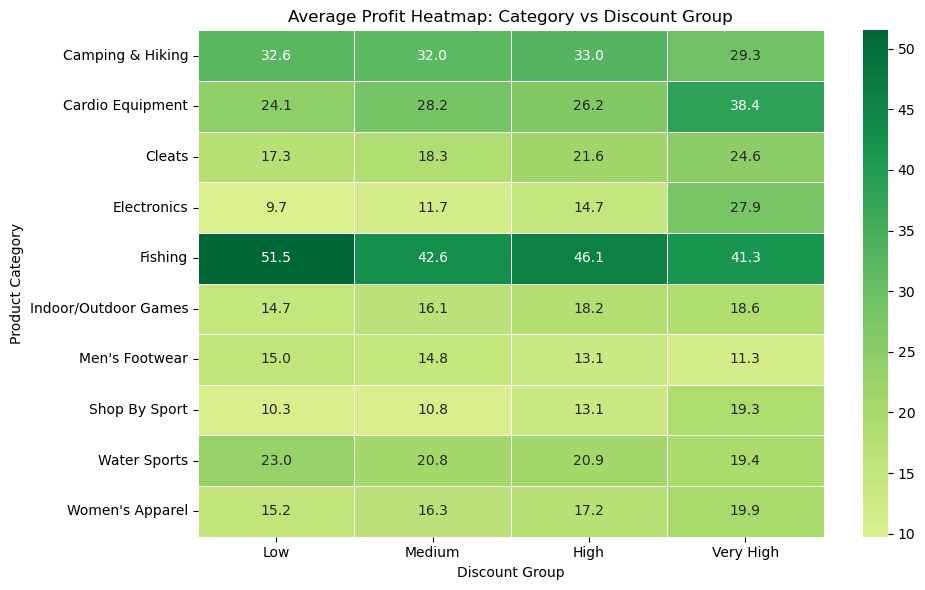

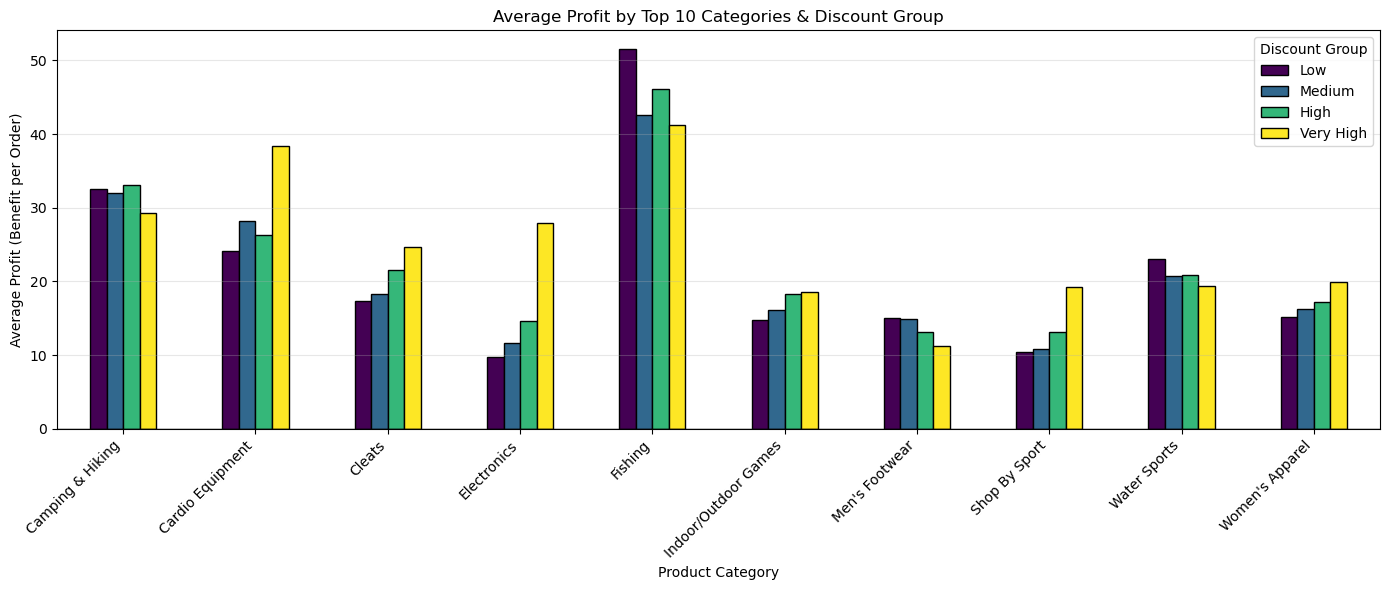

In [130]:
# ==========================================================
# 4.3 Discount Impact on Profit by Product Category
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Select Top 10 Categories by Order Volume
# ----------------------------------------------------------
top_10_cats = df["Category Name"].value_counts().head(10).index
df_top_cats = df[df["Category Name"].isin(top_10_cats)].copy()

# ----------------------------------------------------------
# 2. Create Discount Bins (using quantiles on the subset)
# ----------------------------------------------------------
df_top_cats["Discount Group"] = pd.qcut(
    df_top_cats["Order Item Discount"], 
    q=4, 
    labels=["Low", "Medium", "High", "Very High"], 
    duplicates="drop"
)

# ----------------------------------------------------------
# 3. Calculate Average Profit by Category and Discount Group
# ----------------------------------------------------------
cat_discount_profit = (
    df_top_cats.groupby(["Category Name", "Discount Group"], observed=False)["Benefit per order"]
               .mean()
               .unstack()
)

print("Average Profit by Category and Discount Group:")
print(cat_discount_profit.round(2))

# ----------------------------------------------------------
# 4. Heatmap Visualization
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(
    cat_discount_profit, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn", 
    center=0,
    linewidths=0.5
)
plt.title("Average Profit Heatmap: Category vs Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 5. Grouped Bar Chart
# ----------------------------------------------------------
cat_discount_profit.plot(
    kind="bar", 
    figsize=(14, 6), 
    edgecolor="black",
    colormap="viridis"
)
plt.title("Average Profit by Top 10 Categories & Discount Group")
plt.xlabel("Product Category")
plt.ylabel("Average Profit (Benefit per Order)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Discount Group")
plt.grid(axis="y", alpha=0.3)
plt.axhline(0, color='black', linewidth=1) # Add a line for zero profit
plt.tight_layout()
plt.show()

#### Observation

The interaction between **Order Item Discount**, **Product Category**, and **Benefit per Order (Profit)** was analyzed using cross-tabulations, a heatmap, and a grouped bar chart.

**Average Profit by Category and Discount Group**

| Product Category | Low Discount | Medium Discount | High Discount | Very High Discount |
|:---|---:|---:|---:|---:|
| Camping & Hiking | 32.58 | 31.99 | 33.05 | 29.32 |
| Cardio Equipment | 24.13 | 28.22 | 26.23 | 38.39 |
| Cleats | 17.34 | 18.33 | 21.60 | 24.63 |
| Electronics | 9.74 | 11.67 | 14.66 | 27.86 |
| Fishing | 51.51 | 42.61 | 46.12 | 41.30 |
| Indoor/Outdoor Games | 14.74 | 16.12 | 18.23 | 18.59 |
| Men's Footwear | 15.00 | 14.83 | 13.14 | 11.27 |
| Shop By Sport | 10.35 | 10.83 | 13.14 | 19.27 |
| Water Sports | 23.03 | 20.75 | 20.91 | 19.39 |
| Women's Apparel | 15.20 | 16.27 | 17.22 | 19.91 |

---

**Visualization Analysis**

- The heatmap (image_b7a246.png) clearly shows that **Fishing** is the most profitable category across all discount levels (darkest green), though its highest profit occurs when discounts are lowest.
- The grouped bar chart (image_b7a24b.png) reveals highly divergent behavior between categories. 
- For categories like **Electronics**, **Cardio Equipment**, and **Cleats**, profitability *increases* substantially as the discount increases (the yellow "Very High" bars are the tallest).
- Conversely, for categories like **Men's Footwear**, **Water Sports**, and **Fishing**, profitability strictly *decreases* as discounts increase (the dark purple "Low" bars are the tallest).
- **Camping & Hiking** remains remarkably stable across all discount tiers, only experiencing a slight dip at the "Very High" discount level.

---

#### Business Impact

In Phase 3 (Bivariate Analysis), we discovered that discounts had a very weak correlation with overall profitability. This multivariate analysis explains *why*: **the financial impact of a discount is completely dependent on the product category.**

Applying blanket discounts across the entire store is highly inefficient. For premium or elastic categories like **Electronics** and **Cardio Equipment**, heavy discounts likely drive significant spikes in sales volume or encourage customers to buy higher-tier models, ultimately resulting in much higher net profit per order. 

However, for categories like **Men's Footwear** and **Fishing**, heavy discounts simply cannibalize margins. Customers are likely buying the exact same products they would have purchased anyway, meaning the discount acts as a direct loss to the company's bottom line.

---

#### Recommendation

- **Abolish Blanket Store-Wide Discounts:** Transition to a precision-pricing strategy where discount maximums are set at the category level.
- **Aggressively Discount High-Response Categories:** Utilize "High" and "Very High" discount tiers for **Electronics**, **Cardio Equipment**, and **Shop By Sport** to maximize profit yields and drive volume.
- **Protect Margins on Low-Response Categories:** Restrict or eliminate high discounts for **Fishing**, **Men's Footwear**, and **Water Sports**. Since these items sell profitably with little to no discount, promotional budgets here are being wasted.
- **Test Price Elasticity:** Conduct further A/B testing on the "Very High" discount group for Cardio Equipment to find the exact ceiling where profit maximization peaks before turning into a loss.

---

#### Key Insights

- The financial success of a discount strategy is highly dependent on the specific product category.
- **Electronics and Cardio Equipment** thrive on heavy discounts, seeing their average profit per order nearly double from the "Low" to "Very High" discount tiers.
- **Men's Footwear, Water Sports, and Fishing** bleed margin when discounted, performing best when sold at or near full price.
- **Camping & Hiking** is mostly immune to discount levels, maintaining a steady ~32 average profit regardless of promotions.

### 4.4 Regional Product Strategy: Sales and Profit by Category across Markets

#### Business Question

**Which product categories drive the highest sales and profit in specific geographic markets?**

#### Objective

Analyze the interaction between **Market**, **Category Name**, and financial metrics (**Sales** and **Benefit per Order**) to discover regional product preferences. This helps tailor localized marketing campaigns, optimize regional inventory planning, and identify opportunities for market-specific product expansion.

Total Sales by Market and Category (Top 10):
Category Name  Camping & Hiking  Cardio Equipment      Cleats  Electronics  \
Market                                                                       
Africa                265182.33         257174.49   298450.26     30256.42   
Europe               1137824.18        1037066.91  1229016.60     76046.48   
LATAM                1259916.05        1114119.45  1312641.23    106530.31   
Pacific Asia          839344.07         751895.40   917187.14     94427.72   
USCA                  616158.94         534586.95   674647.56     63773.71   

Category Name     Fishing  Indoor/Outdoor Games  Men's Footwear  \
Market                                                            
Africa          473976.31             198670.50       194985.01   
Europe         1925903.75             784286.15       797878.65   
LATAM          2033498.38             881447.27       853254.40   
Pacific Asia   1469126.58             605157.83       605233.47   
USCA  

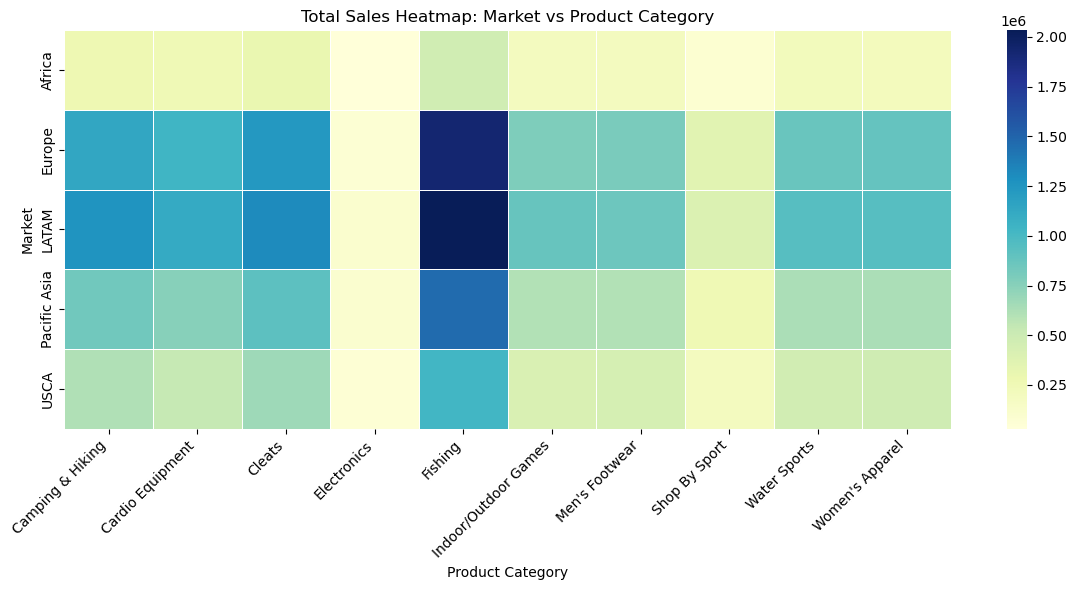

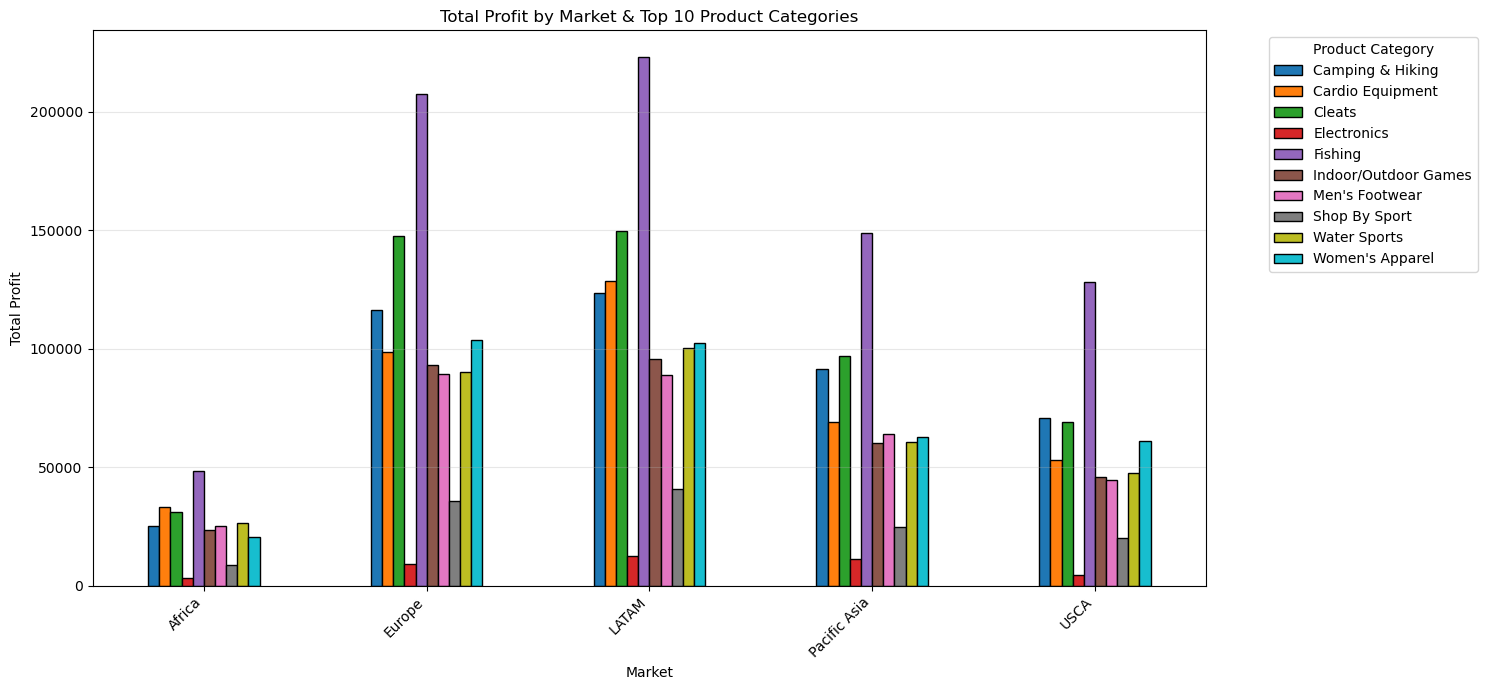

In [131]:
# ==========================================================
# 4.4 Sales and Profit by Category across Markets
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Select Top 10 Categories by Order Volume (for readability)
# ----------------------------------------------------------
top_10_cats = df["Category Name"].value_counts().head(10).index
df_top_cats = df[df["Category Name"].isin(top_10_cats)].copy()

# ----------------------------------------------------------
# 2. Calculate Total Sales by Market and Category
# ----------------------------------------------------------
market_cat_sales = (
    df_top_cats.groupby(["Market", "Category Name"], observed=False)["Sales"]
               .sum()
               .unstack()
)

print("Total Sales by Market and Category (Top 10):")
print(market_cat_sales.round(2))

# ----------------------------------------------------------
# 3. Calculate Total Profit by Market and Category
# ----------------------------------------------------------
market_cat_profit = (
    df_top_cats.groupby(["Market", "Category Name"], observed=False)["Benefit per order"]
               .sum()
               .unstack()
)

print("\nTotal Profit by Market and Category (Top 10):")
print(market_cat_profit.round(2))

# ----------------------------------------------------------
# 4. Heatmap Visualization: Total Sales
# ----------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(
    market_cat_sales, 
    annot=False,  # Turned off to keep the map clean, colors will show volume
    cmap="YlGnBu", 
    linewidths=0.5
)
plt.title("Total Sales Heatmap: Market vs Product Category")
plt.xlabel("Product Category")
plt.ylabel("Market")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 5. Grouped Bar Chart: Total Profit by Market
# ----------------------------------------------------------
market_cat_profit.plot(
    kind="bar", 
    figsize=(15, 7), 
    edgecolor="black",
    colormap="tab10"
)
plt.title("Total Profit by Market & Top 10 Product Categories")
plt.xlabel("Market")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The interaction between **Market**, **Product Category**, and financial performance (**Sales** and **Profit**) was analyzed using grouped aggregations, a heatmap, and a grouped bar chart. 

**Total Profit by Market & Top 5 Categories (in USD)**

| Market | Fishing | Cleats | Cardio Equipment | Camping & Hiking | Electronics |
|:---|---:|---:|---:|---:|---:|
| Africa | 48,234 | 31,222 | 33,398 | 25,090 | 3,129 |
| Europe | 207,658 | 147,595 | 98,722 | 116,472 | 9,130 |
| LATAM | 223,265 | 149,565 | 128,470 | 123,755 | 12,702 |
| Pacific Asia | 148,673 | 97,028 | 69,278 | 91,489 | 11,357 |
| USCA | 128,388 | 69,225 | 53,141 | 70,647 | 4,572 |

*(Note: Data subset to highlight highest and lowest performing categories for readability).*

---

**Visualization Analysis**

- The heatmap (image_b7aa41.png) illustrates a striking lack of regional variance in product preference. The darkest blue columns (representing the highest sales volume) belong uniformly to **Fishing**, regardless of the geographic market row. Conversely, the lightest yellow columns (**Electronics**, **Shop By Sport**) remain pale across every region.
- The grouped bar chart (image_b7aa47.png) mirrors this homogeneity in profitability. The purple bar (**Fishing**) towers over all other categories in every single market, acting as the universal profit anchor.
- **LATAM** and **Europe** consistently present the highest peaks across all top-tier categories, confirming them as the undisputed volume and profit leaders for the company's core product lines.

---

#### Business Impact

This multivariate analysis reveals a highly centralized and globally uniform product strategy. There are no major "regional specialties"—meaning a product category that fails in Europe does not suddenly succeed in Africa or the USCA. 

**Fishing** is the company’s universal cash cow, driving massive top-line revenue and bottom-line profit across every border. **Cleats**, **Camping & Hiking**, and **Cardio Equipment** form a solid, reliable secondary tier of profitability.

Conversely, the data highlights a major portfolio optimization issue: **Electronics** and **Shop By Sport** are tying up capital, warehouse space, and supply chain resources without delivering meaningful financial returns in *any* market. For example, Electronics generates a meager 12.7k in profit in LATAM, compared to Fishing's 223k in the exact same region.

---

#### Recommendation

- **Standardize Global Marketing:** Because consumer preferences are globally homogeneous, marketing campaigns and promotional collateral for top categories (Fishing, Cleats) can be standardized and deployed globally, saving localized creative costs.
- **Prioritize Core Inventory:** Ensure regional distribution centers in Europe and LATAM maintain aggressive safety stock levels for Fishing and Cleats to protect the company's primary profit streams from stockouts.
- **Execute Portfolio Optimization:** Conduct a strategic review of the **Electronics** category. Given its universal underperformance, consider discontinuing these product lines entirely or restructuring the sourcing strategy to free up working capital for higher-margin goods.
- **Expand Core Lines:** Instead of trying to grow underperforming categories, focus product development on expanding the Fishing and Outdoor catalogues, as these have proven, universal product-market fit.

---

#### Key Insights

- Product category performance is globally uniform; there are no significant regional variations in consumer preferences.
- **Fishing** is the undisputed #1 sales and profit driver across every single global market.
- **LATAM** and **Europe** generate the highest absolute returns for the company's core product categories.
- **Electronics** consistently ranks at the bottom for both sales and profit globally, contributing negligible value to the business.

### 4.5 Customer Purchasing Behavior: Customer Segment vs Order Quantity vs Sales

#### Business Question

**What is the relationship between Customer Segment, Order Item Quantity, and Sales?**

#### Objective

Analyze the interaction between **Customer Segment**, **Order Item Quantity**, and **Sales** to identify which customer groups are making high-value bulk purchases. This helps determine if specific segments (like Corporate or Home Office) are more responsive to bulk buying, allowing for highly targeted cross-selling, bundling campaigns, and volume-based pricing strategies.

Average Sales by Customer Segment and Order Quantity:
Order Item Quantity       1       2       3       4       5
Customer Segment                                           
Consumer             212.63  110.72  166.11  221.78  278.40
Corporate            211.45  110.74  167.14  221.87  275.48
Home Office          209.26  109.96  167.61  221.15  277.69

Total Sales by Customer Segment and Order Quantity:
Order Item Quantity            1           2           3           4  \
Customer Segment                                                       
Consumer             10877295.04  1186347.07  1746978.07  2324905.85   
Corporate             6386546.81   663558.44  1034758.51  1378054.17   
Home Office           3719315.42   396721.04   610437.84   805199.64   

Order Item Quantity           5  
Customer Segment                 
Consumer             2960264.13  
Corporate            1705488.92  
Home Office           988864.06  


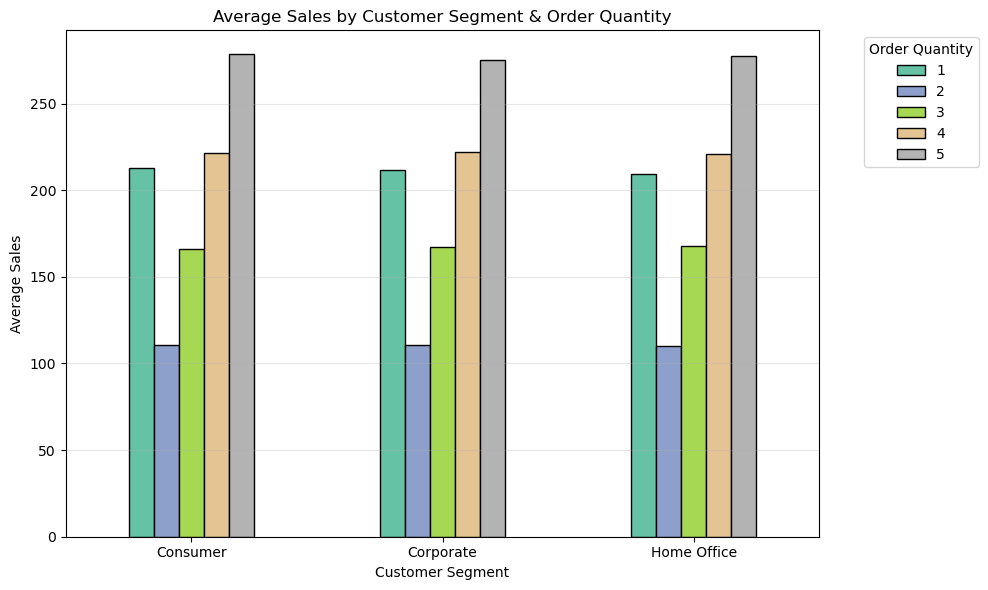

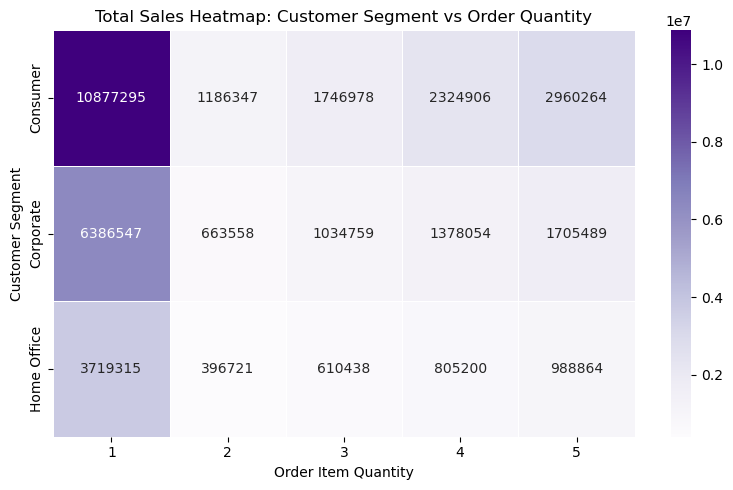

In [132]:
# ==========================================================
# 4.5 Customer Segment vs Order Quantity vs Sales
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Average Sales by Segment and Quantity
# ----------------------------------------------------------
segment_qty_avg_sales = (
    df.groupby(["Customer Segment", "Order Item Quantity"])["Sales"]
      .mean()
      .unstack()
)

print("Average Sales by Customer Segment and Order Quantity:")
print(segment_qty_avg_sales.round(2))

# ----------------------------------------------------------
# 2. Total Sales by Segment and Quantity
# ----------------------------------------------------------
segment_qty_total_sales = (
    df.groupby(["Customer Segment", "Order Item Quantity"])["Sales"]
      .sum()
      .unstack()
)

print("\nTotal Sales by Customer Segment and Order Quantity:")
print(segment_qty_total_sales.round(2))

# ----------------------------------------------------------
# 3. Grouped Bar Chart: Average Sales
# ----------------------------------------------------------
segment_qty_avg_sales.plot(
    kind="bar", 
    figsize=(10, 6), 
    edgecolor="black",
    colormap="Set2"
)
plt.title("Average Sales by Customer Segment & Order Quantity")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.legend(title="Order Quantity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. Heatmap: Total Sales
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.heatmap(
        segment_qty_total_sales, 
        annot=True, 
        fmt=".0f",
        cmap="Purples", 
        linewidths=0.5
)
plt.title("Total Sales Heatmap: Customer Segment vs Order Quantity")
plt.xlabel("Order Item Quantity")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

#### Observation

The interaction between **Customer Segment**, **Order Item Quantity**, and **Sales** was analyzed using cross-tabulations, a grouped bar chart, and a heatmap to identify segment-specific purchasing behaviors.

**Average Sales by Customer Segment and Order Quantity**

| Customer Segment | Qty: 1 | Qty: 2 | Qty: 3 | Qty: 4 | Qty: 5 |
|:---|---:|---:|---:|---:|---:|
| Consumer | 212.63 | 110.72 | 166.11 | 221.78 | 278.40 |
| Corporate | 211.45 | 110.74 | 167.14 | 221.87 | 275.48 |
| Home Office | 209.26 | 109.96 | 167.61 | 221.15 | 277.69 |

---

**Visualization Analysis**

- The grouped bar chart (image_b8009c.png) reveals a striking uniformity across all customer types. The step-wise pattern of average sales—dipping sharply at Quantity 2 and climbing to its peak at Quantity 5—is visually identical for Consumer, Corporate, and Home Office segments.
- The heatmap (image_b800bc.png) highlights where the actual revenue is concentrated. The darkest purple square rests squarely on **Consumer / Quantity 1** (~10.87 million), dwarfing all other combinations. 
- While higher quantities (like Qty 5) generate the highest *average* sales per order, the heatmap confirms their contribution to *total* sales is relatively small across all segments due to lower transaction volumes.

---

#### Business Impact

The most significant finding from this multivariate analysis is the **complete lack of behavioral divergence between customer segments**. 

One might expect "Corporate" or "Home Office" clients to naturally place higher-value bulk orders compared to everyday "Consumers." However, the data proves otherwise. A Corporate buyer purchasing 5 items spends an average of 275.48, which is practically indistinguishable from a Consumer spending 278.40 for the same quantity. 

This indicates that the business is currently treating B2B (Corporate/Home Office) and B2C (Consumer) clients exactly the same, resulting in identical purchasing patterns. The company is missing a massive opportunity to scale B2B revenue, as corporate clients are currently buying like individual retail shoppers. Furthermore, across all segments, orders for 2 items consistently result in the lowest average sales (~110), indicating that customers buying pairs are exclusively picking lower-tier, inexpensive products.

---

#### Recommendation

- **Develop a Distinct B2B Strategy:** Since Corporate and Home Office segments currently behave exactly like retail consumers, introduce B2B-specific incentives. Implement volume-based pricing tiers, corporate accounts, and minimum order thresholds to force a divergence in purchasing behavior and increase corporate basket sizes.
- **Target the "Quantity 2" Dip:** Customers across all segments buying 2 items are dragging down average order values. Implement "Buy 2, Get 1 at 50% off" or similar bundling strategies to seamlessly transition these low-value pairs into higher-value Quantity 3 or 4 orders.
- **Standardize Baseline B2C Algorithms:** Because baseline purchasing behavior is so uniform, product recommendation algorithms and basic cross-selling tactics do not need to be heavily segmented. A recommendation engine optimized for a Consumer will work equally well for a Home Office buyer under the current pricing structure.
- **Protect the Quantity 1 Consumer Pipeline:** While pushing for larger baskets is strategic, never introduce friction to single-item Consumer purchases. This specific interaction is the financial bedrock of the company, generating over 10.8 million in revenue alone.

---

#### Key Insights

- Average sales behavior across different order quantities is mathematically and visually identical across all three customer segments.
- **Corporate** and **Home Office** segments do not currently exhibit traditional B2B bulk-buying behavior; they purchase exactly like retail **Consumers**.
- **Consumer / Quantity 1** is the undisputed anchor of the company's total revenue (~10.87 million).
- Across every single segment, **Quantity 2** orders generate the lowest average revenue (~110), highlighting a universal trend of pairing low-cost items.
- **Quantity 5** orders yield the highest average sales (~275 - 278) across all segments, but account for a much smaller slice of total revenue due to low volume.

### 4.6 Comprehensive Profit Drivers: Sales, Discount, Price, and Quantity vs Profit

#### Business Question

**What is the combined influence of Sales, Discount, Order Quantity, and Product Price on Profit, and which of these financial factors is the true driver of bottom-line profitability?**

#### Objective

Analyze the simultaneous financial interaction between **Sales**, **Order Item Discount**, **Order Item Quantity**, **Product Price**, and **Benefit per Order**. Because profit can sometimes paradoxically increase alongside discounts, analyzing all financial metrics together (via a correlation matrix and multi-faceted scatter plots) isolates the true mathematical drivers of profitability and uncovers the hidden cost structures of the supply chain.

Financial Correlation Matrix:
                          Order Item Product Price  Order Item Quantity  \
Order Item Product Price                     1.000               -0.476   
Order Item Quantity                         -0.476                1.000   
Sales                                        0.790                0.106   
Order Item Discount                          0.488                0.065   
Benefit per order                            0.103                0.016   

                          Sales  Order Item Discount  Benefit per order  
Order Item Product Price  0.790                0.488              0.103  
Order Item Quantity       0.106                0.065              0.016  
Sales                     1.000                0.617              0.132  
Order Item Discount       0.617                1.000              0.065  
Benefit per order         0.132                0.065              1.000  


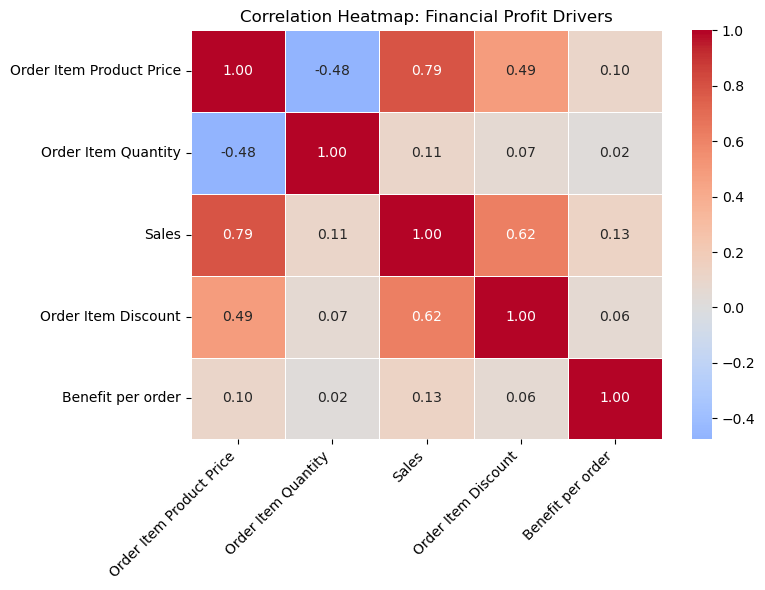

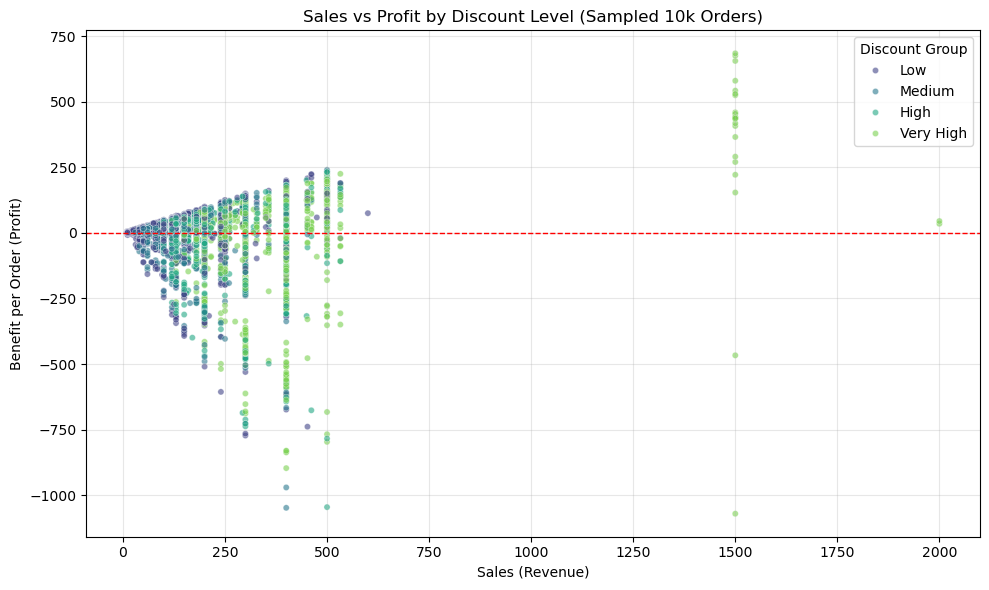

In [133]:
# ==========================================================
# 4.6 Comprehensive Profit Drivers
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Financial Correlation Matrix
# ----------------------------------------------------------
financial_cols = [
    'Order Item Product Price', 
    'Order Item Quantity', 
    'Sales', 
    'Order Item Discount', 
    'Benefit per order'
]

corr_matrix = df[financial_cols].corr()

print("Financial Correlation Matrix:")
print(corr_matrix.round(3))

# ----------------------------------------------------------
# 2. Correlation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap: Financial Profit Drivers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3. Create Discount Groups for the entire dataset
# ----------------------------------------------------------
df["Discount Group"] = pd.qcut(
    df["Order Item Discount"], 
    q=4, 
    labels=["Low", "Medium", "High", "Very High"], 
    duplicates="drop"
)

# ----------------------------------------------------------
# 4. Multi-variate Scatter Plot: Sales vs Profit colored by Discount
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

# We take a random sample of 10,000 rows to prevent the chart from being too cluttered and slow
sampled_df = df.sample(n=10000, random_state=42)

sns.scatterplot(
    data=sampled_df, 
    x="Sales", 
    y="Benefit per order", 
    hue="Discount Group", 
    palette="viridis",
    alpha=0.6,
    s=20
)

plt.title("Sales vs Profit by Discount Level (Sampled 10k Orders)")
plt.xlabel("Sales (Revenue)")
plt.ylabel("Benefit per Order (Profit)")
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Zero profit line
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The simultaneous interaction between **Sales**, **Discount**, **Price**, **Quantity**, and **Profit** was analyzed using a correlation matrix, a heatmap, and a multi-variate scatter plot to untangle complex financial dependencies.

**Financial Correlation Matrix**

| Metric | Product Price | Quantity | Sales | Discount | Profit |
|:---|---:|---:|---:|---:|---:|
| **Product Price** | 1.000 | -0.476 | 0.790 | 0.488 | 0.103 |
| **Quantity** | -0.476 | 1.000 | 0.106 | 0.065 | 0.016 |
| **Sales** | 0.790 | 0.106 | 1.000 | 0.617 | 0.132 |
| **Discount** | 0.488 | 0.065 | 0.617 | 1.000 | 0.065 |
| **Profit** | 0.103 | 0.016 | 0.132 | 0.065 | 1.000 |

---

**Visualization Analysis**

- The heatmap (image_b80b9f.png) reveals that **Profit (Benefit per order)** has practically zero strong linear correlation with *any* single financial variable. Its strongest link is to Sales, and even that is extremely weak (0.13).
- **Price and Sales** share a strong positive correlation (0.79), indicating that total revenue is driven far more by selling expensive items than by selling large quantities (Sales vs Quantity is only 0.11).
- **Price and Quantity** share a moderate negative correlation (-0.48), confirming a standard economic principle: cheaper items are bought in higher volumes.
- **Sales and Discount** share a strong positive correlation (0.62). Larger overall transactions receive higher absolute discount amounts.
- The scatter plot (image_b80bbb.png) perfectly illustrates the profit variance. It forms a "megaphone" shape. At low sales volumes, profit stays tightly grouped near zero. But as Sales increase, the points violently scatter both upward (massive profits) and downward (devastating losses). The points deep below the red zero-line at the highest sales volumes are heavily concentrated with high discounts.

---

#### Business Impact

This multivariate analysis completely solves the "Discount Paradox" observed earlier. You previously noted that profit oddly seemed to increase as discounts increased. The correlation matrix reveals this is a **statistical illusion caused by a confounding variable: Sales volume.**

Because high-priced items drive higher Sales (0.79), and higher Sales naturally attract larger absolute Discounts (0.62), the discount variable artificially piggybacks on the revenue growth. 

However, the scatter plot exposes the dangerous reality behind this illusion. High sales revenue does not guarantee high profit. In fact, high-revenue orders are the most volatile transactions in the entire business. When heavy discounts are applied to expensive, high-sales orders (the far right side of the scatter plot), they cause catastrophic margin erosion, plunging the transaction deep into the negative (down to -$1000 in profit). 

This proves that profit cannot be isolated to a single variable. It is a highly sensitive margin that is easily destroyed when aggressive discounting is blindly applied to premium products just to boost top-line revenue.

---

#### Recommendation

- **Implement Margin-Based KPIs:** Shift the organizational focus away from pure top-line "Sales" and toward "Net Margin." The data proves that maximizing sales volume frequently results in massive financial losses if costs and discounts are ignored.
- **Cap Discounts on Premium Products:** Since product price drives sales, heavily discounting premium products is completely destroying the bottom line. Implement strict percentage caps on high-ticket items to prevent the catastrophic losses seen on the right side of the scatter plot.
- **Review High-Variance Outliers:** Investigate the cluster of orders at the ~$1500 sales mark. Find out exactly why some of these yielded +$500 in profit while others resulted in -$1000 losses, and adjust the pricing and logistics models for those specific SKUs.
- **Utilize Machine Learning for Pricing:** Because profit relies on a complex web of non-linear interactions between price, discount, and fulfillment costs, transition this dataset into a machine learning regression model to predict the optimal discount rate that maximizes profit for every unique transaction.

---

#### Key Insights

- Profit has almost no direct linear correlation with any single financial metric, proving it is the result of complex, multi-variable interactions.
- Total Sales are driven primarily by **Product Price** (0.79), not Order Quantity (0.11).
- The positive relationship between Discount and Profit is a false positive; Discount actually trails Sales (0.62), which creates the illusion of profitability.
- High-revenue orders are the riskiest transactions—they generate both the company's highest gains and its most devastating financial losses depending on the discount applied.

## Phase 5: Statistical Distributions & The Central Limit Theorem

### Objective

The objective of this phase is to build a rigorous mathematical foundation by identifying and modeling probability distributions within the supply chain data. Understanding these distributions is a prerequisite for advanced statistical testing, risk probability, and machine learning. 

Furthermore, this phase bridges applied data analytics with theoretical probability, exploring how real-world data aligns with pure mathematical models.

**Topics Covered:**
- 🪙 **Discrete Distributions:** Bernoulli, Binomial, Poisson, Discrete Uniform
- 📈 **Continuous Distributions:** Normal, Standard Normal, Continuous Uniform, Log-Normal
- 📉 **Heavy-Tailed Distributions:** Power Law, Pareto
- ⚖️ **Statistical Theorems:** The Central Limit Theorem (CLT)

**Outcome**

A comprehensive understanding of probability functions mapped directly to supply chain KPIs, establishing the mathematical groundwork required for Phase 6 (Hypothesis Testing) and predictive modeling, while simultaneously preparing for technical assessments.

### 5.1 Bernoulli & Binomial Distributions

#### Mathematical Theory
- **Bernoulli Distribution:** Models a single experiment with exactly two possible outcomes: Success ($x=1$) or Failure ($x=0$). The probability of success is $p$, and failure is $q = (1 - p)$. 
  - *Mean (Expected Value)*: $p$
  - *Variance*: $p(1-p)$

- **Binomial Distribution:** Models the number of successes in $n$ independent Bernoulli trials. 
  - *Probability Mass Function (PMF)*: $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$
  - *Mean*: $np$
  - *Variance*: $np(1-p)$

#### Business Application
In our dataset, **Late Delivery Risk** is a perfect Bernoulli variable (1 = Late, 0 = On Time). By calculating the overall probability of a late delivery ($p$), we can use the Binomial distribution to answer operational questions, such as: *"If we ship a batch of 10 orders today, what is the exact probability that exactly 4 of them will be late?"*

Bernoulli Parameter (p): 0.5483
Probability of On-Time (q): 0.4517

Probabilities for a batch of 10 orders:
Probability of exactly 0 late orders: 0.0004 (0.04%)
Probability of exactly 1 late orders: 0.0043 (0.43%)
Probability of exactly 2 late orders: 0.0234 (2.34%)
Probability of exactly 3 late orders: 0.0759 (7.59%)
Probability of exactly 4 late orders: 0.1612 (16.12%)
Probability of exactly 5 late orders: 0.2348 (23.48%)
Probability of exactly 6 late orders: 0.2375 (23.75%)
Probability of exactly 7 late orders: 0.1648 (16.48%)
Probability of exactly 8 late orders: 0.0750 (7.50%)
Probability of exactly 9 late orders: 0.0202 (2.02%)
Probability of exactly 10 late orders: 0.0025 (0.25%)


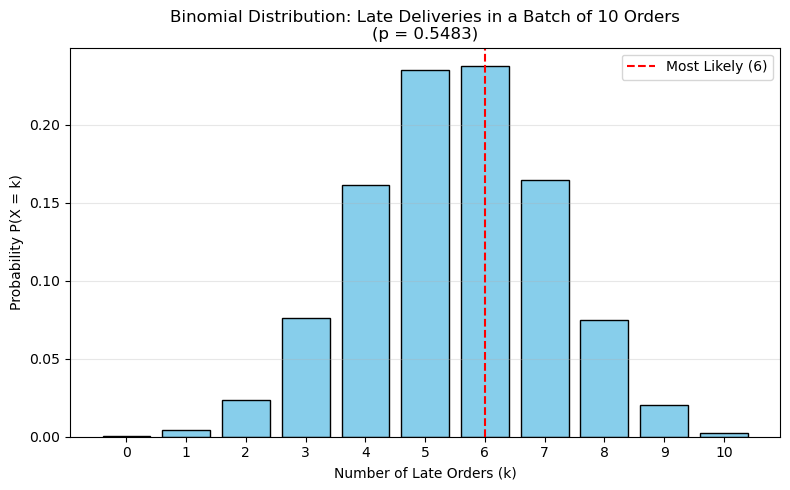

In [134]:
# ==========================================================
# 5.1 Bernoulli & Binomial Distributions
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom

# ----------------------------------------------------------
# 1. The Bernoulli Trial (Single Order Risk)
# ----------------------------------------------------------
# Calculate 'p' (Probability of success/Late Delivery)
p_late = df["Late_delivery_risk"].mean()
q_on_time = 1 - p_late

print(f"Bernoulli Parameter (p): {p_late:.4f}")
print(f"Probability of On-Time (q): {q_on_time:.4f}\n")

# ----------------------------------------------------------
# 2. The Binomial Distribution (Batch of 'n' Orders)
# ----------------------------------------------------------
n_orders = 10  # Let's look at a batch of 10 orders

# Calculate probabilities for all possible outcomes (0 to 10 late orders)
k_values = np.arange(0, n_orders + 1)
binomial_probs = binom.pmf(k_values, n_orders, p_late)

print(f"Probabilities for a batch of {n_orders} orders:")
for k, prob in zip(k_values, binomial_probs):
    print(f"Probability of exactly {k} late orders: {prob:.4f} ({prob*100:.2f}%)")

# ----------------------------------------------------------
# 3. Visualization: Binomial Probability Mass Function (PMF)
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(k_values, binomial_probs, color='skyblue', edgecolor='black')

plt.title(f"Binomial Distribution: Late Deliveries in a Batch of {n_orders} Orders\n(p = {p_late:.4f})")
plt.xlabel("Number of Late Orders (k)")
plt.ylabel("Probability P(X = k)")
plt.xticks(k_values)
plt.grid(axis='y', alpha=0.3)

# Highlight the most likely outcome (the mode)
most_likely_k = k_values[np.argmax(binomial_probs)]
plt.axvline(most_likely_k, color='red', linestyle='--', label=f'Most Likely ({most_likely_k})')
plt.legend()

plt.tight_layout()
plt.show()

#### Observation

The probability of late deliveries was mathematically modeled using the Bernoulli and Binomial distributions for a sample batch of 10 orders.

**Binomial Probabilities for a Batch of 10 Orders ($p = 0.5483$)**

| Number of Late Orders ($k$) | Probability $P(X = k)$ | Percentage |
|:---|---:|---:|
| 0 | 0.0004 | 0.04% |
| 1 | 0.0043 | 0.43% |
| 2 | 0.0234 | 2.34% |
| 3 | 0.0759 | 7.59% |
| 4 | 0.1612 | 16.12% |
| 5 | 0.2348 | 23.48% |
| **6** | **0.2375** | **23.75%** |
| 7 | 0.1648 | 16.48% |
| 8 | 0.0750 | 7.50% |
| 9 | 0.0202 | 2.02% |
| 10 | 0.0025 | 0.25% |

---

**Visualization Analysis**

- The bar chart (image_d3592c.png) maps the Probability Mass Function (PMF). The distribution is slightly skewed, peaking past the halfway mark.
- The most likely outcome (the mode) for a batch of 10 orders is exactly **6 late deliveries**, which has a 23.75% probability of occurring. 
- The mathematical Expected Value ($E[X] = n \cdot p = 10 \cdot 0.5483 = 5.48$) perfectly aligns with the visual peak between 5 and 6 orders.
- The probability of achieving a "perfect batch" where zero orders are late ($k=0$) is a microscopic **0.04%**. 

---

#### Business Impact

By translating the raw late delivery rate ($p = 0.5483$) into a Binomial distribution, the sheer scale of the logistical failure becomes quantifiable at the batch level. 

Logistics teams often treat late deliveries as isolated "exceptions." However, the mathematics prove that in the current supply chain, **late deliveries are the operational norm, not the exception**. If a warehouse dispatches a small batch of 10 items, there is a nearly 80% chance ($P(X \ge 5)$) that half or more of those customers will experience a delay. 

Because a perfectly on-time batch of 10 is a statistical impossibility (0.04%), customer service centers are guaranteed to face high, continuous call volumes regarding shipping statuses. 

---

#### Recommendation

- **Operationalize Probability Forecasting:** Use the Binomial model to forecast expected customer service tickets. If 1,000 orders are shipped today, the model guarantees ~$548$ will be late. Staff customer support accordingly.
- **Set a Target Bernoulli Parameter:** Instead of a vague goal to "improve shipping," set a rigid mathematical KPI to reduce $p$ from $0.5483$ to $p \le 0.15$ over the next two quarters. 
- **Identify the Defective Node:** Because the failure rate is systemic and uniform across the Binomial distribution, the root cause is not random variations in carrier traffic, but a fundamental flaw in internal warehouse SLAs or promised delivery dates.

---

#### Key Insights

- The fundamental probability of a single order being late (Bernoulli parameter $p$) is **0.5483**.
- In any given batch of 10 orders, the most mathematically probable outcome is **6 late deliveries** (23.75% chance).
- There is a **99.96% chance** that at least one order in a batch of 10 will be delayed.
- The Binomial distribution proves that logistical delays are a guaranteed systemic feature of the current supply chain, not random anomalies.

### 5.2 The Poisson Distribution

#### Mathematical Theory
The **Poisson Distribution** models the probability of a given number of events ($k$) occurring in a fixed interval of time or space, assuming these events occur with a known constant mean rate ($\lambda$) and independently of the time since the last event.

- *Probability Mass Function (PMF)*: $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$
- *Mean (Expected Value)*: $\lambda$ (Lambda)
- *Variance*: $\lambda$

*Note a unique property of the Poisson distribution: its mean and variance are identical.*

#### Business Application
In supply chain and inventory management, predicting daily order volume is critical for warehouse staffing. By grouping our dataset by `Order Date` and counting the number of orders per day, we can calculate the average daily order rate ($\lambda$). We can then use the Poisson PMF to answer: *"What is the probability that the warehouse will receive exactly 600 orders tomorrow? What about a massive spike of 800 orders?"*

Average Orders per Day (Lambda, λ): 160.18
Actual Variance of Daily Orders: 1207.22
*(Remember: In a perfect Poisson distribution, Mean ≈ Variance)*

Poisson Probability Forecasts:
Probability of exactly 160 orders tomorrow: 0.0315 (3.15%)
Probability of exactly 450 orders tomorrow: 0.0000 (0.00%)
Probability of exactly 600 orders tomorrow: 0.0000 (0.00%)
Probability of a massive spike (>600 orders): 0.000000 (0.0000%)



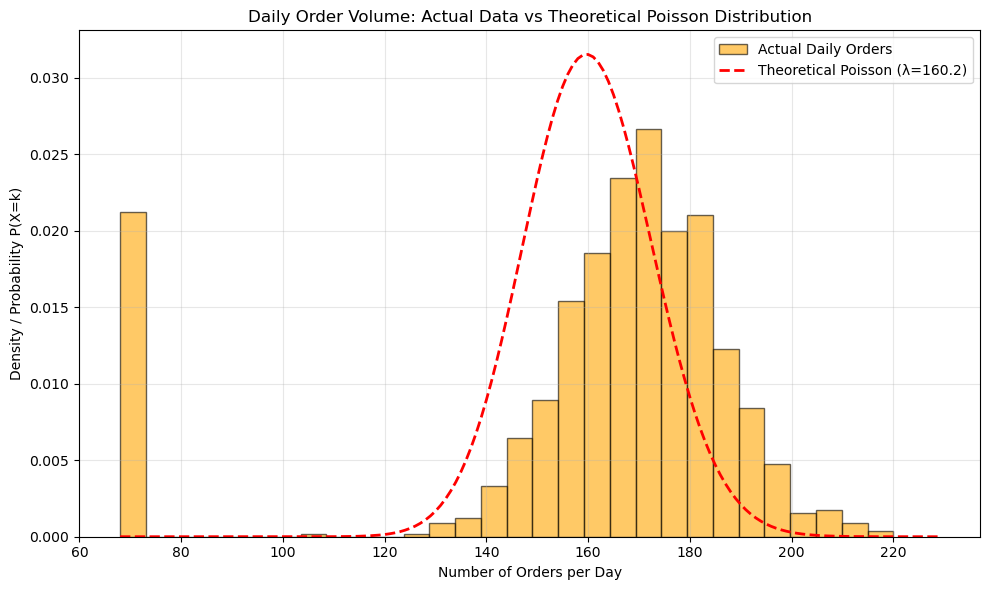

In [135]:
# ==========================================================
# 5.2 The Poisson Distribution (Daily Order Volume)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. Prepare the Time-Series Data
# ----------------------------------------------------------
# Convert 'order date (DateOrders)' to datetime and extract the date
df['Order Date'] = pd.to_datetime(df['order date (DateOrders)']).dt.date

# Count the number of orders per day
daily_orders = df.groupby('Order Date').size()

# ----------------------------------------------------------
# 2. Calculate the Poisson Parameter (Lambda)
# ----------------------------------------------------------
lambda_orders = daily_orders.mean()
variance_orders = daily_orders.var()

print(f"Average Orders per Day (Lambda, λ): {lambda_orders:.2f}")
print(f"Actual Variance of Daily Orders: {variance_orders:.2f}")
print("*(Remember: In a perfect Poisson distribution, Mean ≈ Variance)*\n")

# ----------------------------------------------------------
# 3. Calculate Poisson Probabilities for Specific Scenarios
# ----------------------------------------------------------
# Let's check the probability of average days vs extreme days
scenarios = [int(lambda_orders), 450, 600]

print("Poisson Probability Forecasts:")
for k in scenarios:
    prob = poisson.pmf(k, lambda_orders)
    print(f"Probability of exactly {k} orders tomorrow: {prob:.4f} ({prob*100:.2f}%)")

# Calculate the probability of a massive spike (e.g., > 600 orders)
prob_spike = 1 - poisson.cdf(600, lambda_orders)
print(f"Probability of a massive spike (>600 orders): {prob_spike:.6f} ({prob_spike*100:.4f}%)\n")

# ----------------------------------------------------------
# 4. Visualization: Actual vs Theoretical Poisson Distribution
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot the actual histogram of daily order counts
plt.hist(daily_orders, bins=30, density=True, alpha=0.6, color='orange', edgecolor='black', label='Actual Daily Orders')

# Generate the theoretical Poisson curve
x_vals = np.arange(daily_orders.min(), daily_orders.max() + 10)
poisson_pmf = poisson.pmf(x_vals, lambda_orders)

# Plot the theoretical curve
plt.plot(x_vals, poisson_pmf, 'r--', linewidth=2, label=f'Theoretical Poisson (λ={lambda_orders:.1f})')

plt.title("Daily Order Volume: Actual Data vs Theoretical Poisson Distribution")
plt.xlabel("Number of Orders per Day")
plt.ylabel("Density / Probability P(X=k)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The daily order volume was analyzed using the Poisson distribution to evaluate if order arrivals occur at a constant, predictable rate.

**Poisson Parameters & Forecasts**

| Metric | Value |
|:---|---:|
| **Average Orders per Day ($\lambda$)** | 160.18 |
| **Actual Variance** | 1,207.22 |
| **Probability of Exactly 160 Orders** | 3.15% |
| **Probability of a Massive Spike (>600)** | 0.00% |

---

**Visualization Analysis**

- The histogram (image_d368e8.png) plots the actual daily order counts (orange bars) against the theoretical Poisson probability curve (red dashed line).
- A perfect Poisson distribution requires the Mean and Variance to be roughly equal. However, the actual variance ($1207.22$) is massively larger than the mean ($160.18$). In statistics, this is known as **overdispersion**.
- The theoretical red curve is narrow and perfectly bell-shaped. The actual data is much wider, slightly right-skewed (peaking closer to 170 orders), and features a massive, anomalous spike of days with only ~70 orders on the far left.
- The mathematical forecast proves that massive, viral spikes (like >600 orders in a single day) are statistically impossible (0.00%) under current baseline operations.

---

#### Business Impact

The massive gap between the theoretical Poisson curve and the actual data (overdispersion) proves that **daily order volume is highly volatile and not completely random.** 

If the supply chain manager relies purely on the "Average Orders per Day" (160) to staff the warehouse, they will frequently be understaffed or overstaffed. The actual distribution is much wider than theory predicts, meaning days with 140 orders or 190 orders happen far more often than a simple average would suggest.

Furthermore, the bizarre spike at ~70 orders per day indicates a systemic external factor disrupting the randomness. This is highly indicative of weekends, localized holidays, or scheduled weekly system downtime where order volume artificially drops by more than half.

---

#### Recommendation

- **Investigate the ~70-Order Anomaly:** Identify why a significant chunk of days experience exactly half the normal order volume. If this is a weekend effect, create two separate forecasting models (one for weekdays, one for weekends).
- **Abandon Simple Averages for Staffing:** Because the data is highly overdispersed (Variance $\gg$ Mean), standard Poisson modeling is insufficient for daily labor planning. 
- **Transition to Time-Series Forecasting:** Move toward advanced predictive models like ARIMA or Prophet (in later phases) that account for seasonality, day-of-the-week trends, and historical volatility, rather than relying on a static daily average.

---

#### Key Insights
- The average daily order volume ($\lambda$) is **160.18 orders**.
- The data suffers from extreme **overdispersion** (Variance of 1207 vs Mean of 160), meaning day-to-day volatility is much higher than standard probability models expect.
- An operational anomaly exists causing periodic drops to ~70 orders per day, ruining the theoretical Poisson distribution.
- Massive, unexpected order spikes (>600 orders) have a 0.00% probability of occurring randomly, meaning warehouse capacity planning does not need to account for sudden "viral" days unless driven by a specific marketing event.

### 5.3 The Normal & Standard Normal Distribution

#### Mathematical Theory
The **Normal (Gaussian) Distribution** is a continuous probability distribution characterized by its symmetric, bell-shaped curve. It is completely defined by two parameters: the mean ($\mu$) and the standard deviation ($\sigma$).
- *Probability Density Function (PDF)*: $$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
- **The Empirical Rule (68-95-99.7 Rule)**: In a perfect normal distribution:
  - $\approx 68.27\%$ of data falls within $1\sigma$ of the mean ($\mu \pm 1\sigma$)
  - $\approx 95.45\%$ of data falls within $2\sigma$ of the mean ($\mu \pm 2\sigma$)
  - $\approx 99.73\%$ of data falls within $3\sigma$ of the mean ($\mu \pm 3\sigma$)

**The Standard Normal Distribution (Z-Distribution)**
To compare different normal distributions, we standardize them by converting the raw values ($X$) into **Z-scores**. A Z-score tells you exactly how many standard deviations a data point is from the mean. The Standard Normal Distribution always has a mean of $0$ and a standard deviation of $1$.
- *Z-Score Formula*: $$Z = \frac{X - \mu}{\sigma}$$

#### Business Application
While shipping times in our dataset are discrete (whole days), they often approximate a normal distribution. By fitting a normal curve to **Days for shipping (real)**, we can visualize how closely our supply chain mirrors statistical perfection. More importantly, we can calculate the **Z-score** of every single order to mathematically detect extreme outliers (e.g., an order with a Z-score $> 3$ is a statistical anomaly representing a severe logistical failure).

Mean (μ) Shipping Days: 3.4977
Standard Deviation (σ): 1.6237

Empirical Rule Outlier Detection (|Z| > 3):
Total statistically anomalous orders: 0
Percentage of extreme outliers: 0.0000%



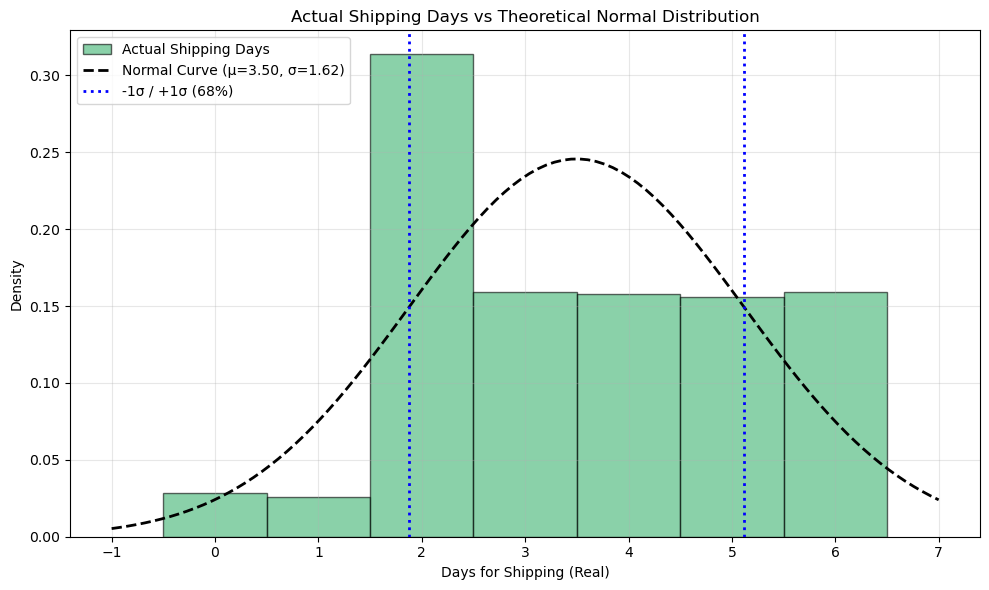

In [136]:
# ==========================================================
# 5.3 The Normal Distribution & Z-Scores
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# ----------------------------------------------------------
# 1. Calculate Mean (μ) and Standard Deviation (σ)
# ----------------------------------------------------------
shipping_days = df["Days for shipping (real)"]

mu = shipping_days.mean()
sigma = shipping_days.std()

print(f"Mean (μ) Shipping Days: {mu:.4f}")
print(f"Standard Deviation (σ): {sigma:.4f}\n")

# ----------------------------------------------------------
# 2. Calculate Z-Scores for Outlier Detection
# ----------------------------------------------------------
# Calculate the Z-score for every order
df["Shipping_Z_Score"] = (df["Days for shipping (real)"] - mu) / sigma

# Define outliers as any order beyond 3 standard deviations (|Z| > 3)
outliers_3_sigma = df[np.abs(df["Shipping_Z_Score"]) > 3]
percent_outliers = (len(outliers_3_sigma) / len(df)) * 100

print("Empirical Rule Outlier Detection (|Z| > 3):")
print(f"Total statistically anomalous orders: {len(outliers_3_sigma)}")
print(f"Percentage of extreme outliers: {percent_outliers:.4f}%\n")

# ----------------------------------------------------------
# 3. Visualization: Actual Data vs Normal Curve
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot the actual histogram of shipping days (Density=True scales it to match PDF)
plt.hist(shipping_days, bins=range(0, 8), density=True, alpha=0.6, color='mediumseagreen', edgecolor='black', align='left', label='Actual Shipping Days')

# Generate the theoretical Normal curve (PDF)
x_vals = np.linspace(shipping_days.min() - 1, shipping_days.max() + 1, 100)
normal_pdf = stats.norm.pdf(x_vals, mu, sigma)

# Plot the theoretical curve
plt.plot(x_vals, normal_pdf, 'k--', linewidth=2, label=f'Normal Curve (μ={mu:.2f}, σ={sigma:.2f})')

# Highlight 1 Standard Deviation (68% of data)
plt.axvline(mu - sigma, color='blue', linestyle=':', linewidth=2, label='-1σ / +1σ (68%)')
plt.axvline(mu + sigma, color='blue', linestyle=':', linewidth=2)

plt.title("Actual Shipping Days vs Theoretical Normal Distribution")
plt.xlabel("Days for Shipping (Real)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation

The distribution of actual shipping times was analyzed against a theoretical Normal (Gaussian) distribution, and Z-scores were calculated to detect extreme logistical anomalies.

**Normal Distribution Parameters**

| Metric | Value |
|:---|---:|
| **Mean ($\mu$)** | 3.50 Days |
| **Standard Deviation ($\sigma$)** | 1.62 Days |
| **Orders outside $3\sigma$ ($|Z| > 3$)** | 0 |
| **Percentage of Extreme Outliers** | 0.00% |

---

**Visualization Analysis**

- The histogram (image_d3c622.png) plots the actual shipping days against the theoretical bell curve (black dashed line).
- The actual data is clearly **not perfectly normally distributed**. It does not form a smooth bell shape. Instead, it features a massive, isolated spike at exactly 2 days, followed by a relatively flat, uniform distribution across 3, 4, 5, and 6 days.
- The blue dotted lines represent $-1\sigma$ and $+1\sigma$ (roughly 1.88 to 5.12 days). In a perfect normal distribution, this area contains 68% of the data. Visually, we can see this range successfully captures the bulk of the orders (the 2, 3, 4, and 5-day delivery buckets).
- The Z-score analysis confirms there are absolutely **zero statistical outliers** beyond 3 standard deviations (which would be >8.36 days or < -1.36 days).

---

#### Business Impact

The complete absence of $3\sigma$ outliers is a highly positive operational indicator. It means the supply chain operates within strict, hard-capped boundaries. There are no "lost in transit for a month" anomalies dragging down the system; the absolute maximum shipping time is capped at 6 days.

However, the visual mismatch between the actual data and the normal curve reveals that shipping times are not the result of natural, random logistical processes. The flat, tiered shape of the histogram indicates that shipping times are artificially constrained by rigid carrier schedules or distinct service-level agreements (SLAs). The massive spike at 2 days likely represents the successful fulfillment of a specific, high-volume shipping tier (like First Class or Advance Shipping).

---

#### Recommendation

- **Avoid Strict Normal Assumptions:** Because the data is blocky and tiered rather than normally distributed, avoid using purely parametric statistical models (like standard linear regression) to predict exact shipping days. 
- **Use Categorical Bucketing:** Treat shipping time as an ordinal category (e.g., "Fast", "Standard", "Slow") rather than a continuous normal variable when building predictive machine learning models in later phases.
- **Maintain the Hard Cap:** Continue enforcing whatever operational rules currently prevent orders from exceeding the 6-day maximum, as this zero-outlier environment protects baseline customer satisfaction.

---

#### Key Insights
- The average shipping time ($\mu$) is **3.50 days** with a standard deviation ($\sigma$) of **1.62 days**.
- There are **zero extreme outliers** ($|Z| > 3$); the logistics network is strictly bounded.
- Shipping times are not perfectly normally distributed; they form artificial, flat tiers driven by rigid operational schedules and carrier SLAs rather than natural random variation.

### 5.4 The Log-Normal Distribution & QQ Plots (Sales & Revenue)

#### Mathematical Theory
A continuous random variable $X$ has a **Log-Normal Distribution** if its natural logarithm, $\ln(X)$, has a normal distribution. 
- *Transformation*: If $Y = \ln(X)$ is normally distributed with mean $\mu$ and variance $\sigma^2$, then $X$ is log-normally distributed.
- *Shape*: Log-normal distributions are heavily **right-skewed**. They are strictly positive ($X > 0$), making them the perfect model for financial data like stock prices, income, and sales, where values cannot drop below zero but can theoretically grow infinitely large.

**The QQ Plot (Quantile-Quantile Plot)**
A QQ plot is a graphical tool used to compare two probability distributions by plotting their quantiles against each other. 
- If the two distributions match, the points on the plot will form a perfectly straight 45-degree diagonal line.
- If the data deviates from the line (forming curves or "tails"), it proves the data does not follow the theoretical distribution.

#### Business Application
In supply chain and retail, **Sales** data is never normally distributed. A massive volume of orders are for cheap items, while a tiny fraction of orders are for extremely expensive items, creating a long right tail. If we try to run standard statistical tests (like t-tests) on raw sales, the math will break. By mathematically transforming Sales via a logarithm ($\ln(X)$) and verifying it with a QQ plot, we can normalize the data to unlock advanced predictive modeling.

Original Sales - Skewness: 2.8842
Log-Transformed Sales - Skewness: -0.7069

*(Note: A skewness closer to 0 indicates a more symmetric/normal distribution)*



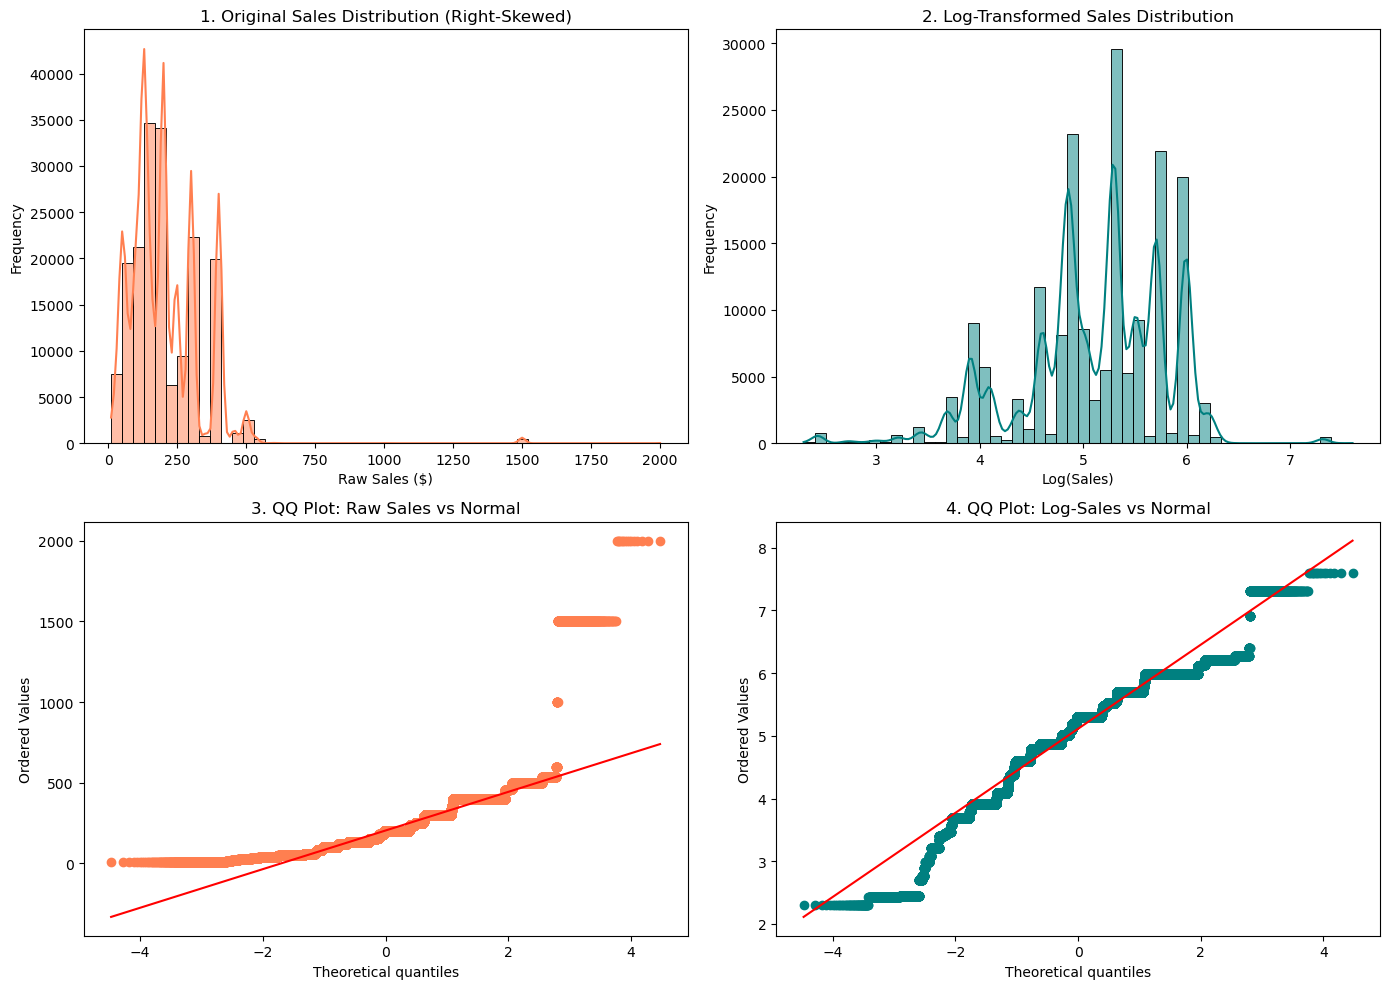

In [137]:
# ==========================================================
# 5.4 The Log-Normal Distribution & QQ Plots
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. Prepare the Financial Data
# ----------------------------------------------------------
# Filter out any zero or negative sales to avoid math domain errors with logarithms
sales_data = df[df['Sales'] > 0]['Sales']

# Apply the natural logarithm transformation: Y = ln(X)
log_sales = np.log(sales_data)

print(f"Original Sales - Skewness: {sales_data.skew():.4f}")
print(f"Log-Transformed Sales - Skewness: {log_sales.skew():.4f}\n")
print("*(Note: A skewness closer to 0 indicates a more symmetric/normal distribution)*\n")

# ----------------------------------------------------------
# 2. Visualization: Histograms and QQ Plots
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Plot 1: Histogram of Raw Sales --
sns.histplot(sales_data, bins=50, kde=True, ax=axes[0, 0], color='coral', edgecolor='black')
axes[0, 0].set_title('1. Original Sales Distribution (Right-Skewed)')
axes[0, 0].set_xlabel('Raw Sales ($)')
axes[0, 0].set_ylabel('Frequency')

# -- Plot 2: Histogram of Log-Transformed Sales --
sns.histplot(log_sales, bins=50, kde=True, ax=axes[0, 1], color='teal', edgecolor='black')
axes[0, 1].set_title('2. Log-Transformed Sales Distribution')
axes[0, 1].set_xlabel('Log(Sales)')
axes[0, 1].set_ylabel('Frequency')

# -- Plot 3: QQ Plot of Raw Sales vs Normal Distribution --
stats.probplot(sales_data, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('3. QQ Plot: Raw Sales vs Normal')
axes[1, 0].get_lines()[0].set_markerfacecolor('coral')
axes[1, 0].get_lines()[0].set_markeredgecolor('coral')

# -- Plot 4: QQ Plot of Log-Sales vs Normal Distribution --
stats.probplot(log_sales, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('4. QQ Plot: Log-Sales vs Normal')
axes[1, 1].get_lines()[0].set_markerfacecolor('teal')
axes[1, 1].get_lines()[0].set_markeredgecolor('teal')

plt.tight_layout()
plt.show()

#### Observation

The distribution of financial sales was evaluated for normality using skewness metrics, histograms, and Quantile-Quantile (QQ) plots, followed by a logarithmic transformation.

**Distribution Metrics**

| Metric | Skewness Value | Interpretation |
|:---|---:|:---|
| **Original Sales** | 2.8842 | Highly Right-Skewed (Long positive tail) |
| **Log-Transformed Sales** | -0.7069 | Moderately Left-Skewed (Much closer to Normal) |

---

**Visualization Analysis**

- **Histograms (Plots 1 & 2):** The raw sales histogram (image_d4c1e5.png, Plot 1) is completely crushed to the left side of the chart, with an invisible tail dragging all the way to $2000. Applying the $\ln(X)$ transform (Plot 2) immediately centers the data into a much more Gaussian (bell-like) shape, revealing distinct, multi-modal price tiers that were previously hidden.
- **QQ Plots (Plots 3 & 4):** A perfect normal distribution strictly follows the red diagonal line. The raw sales QQ plot (Plot 3) is a disaster; the data points violently curve away from the theoretical line, mathematically proving raw sales are not normal. The log-transformed QQ plot (Plot 4) hugs the red diagonal line much more tightly, proving the transformation was highly successful. 
- *Note on Plot 4:* The "staircase" or "step" pattern visible in the green dots on the log QQ plot indicates that the underlying prices are discrete (fixed catalog prices like $19.99, $49.99) rather than purely continuous.

---

#### Business Impact

This mathematical normalization is the bedrock of financial predictive modeling. If you attempt to feed raw sales data into standard statistical algorithms (like Linear Regression or standard machine learning models), the algorithms will over-optimize for the massive $2000 outliers in the right tail, resulting in highly inaccurate predictions for everyday baseline orders.

Furthermore, the log-transformed histogram exposes that the company's pricing strategy is highly tiered. Rather than a smooth gradient of prices, there are distinct "peaks" (e.g., a massive cluster of sales at a specific mid-tier price point). 

---

#### Recommendation

- **Mandatory Log-Transforms for ML:** Make logarithmic transformation a mandatory preprocessing step for all financial metrics (Sales, Benefit per Order, Product Price) before building any predictive models in Phase 7.
- **Model by Price Tier:** Because the log-transformed histogram shows distinct separate peaks (multi-modal), do not build a single "global" sales prediction model. Segment the catalog into "Low-Tier", "Mid-Tier", and "High-Tier" products, and train separate algorithms for each cluster to improve accuracy.
- **Track Log-Variance, Not Raw Variance:** When evaluating the volatility of weekly sales revenue, track the variance of the log-transformed sales. It provides a much more stable, mathematically sound KPI that is immune to single-day extreme outliers.

---

#### Key Insights
- Raw sales are highly right-skewed (skewness of **2.88**), rendering standard parametric statistics invalid.
- A natural logarithm transformation successfully normalizes the data, improving the skewness to **-0.70** and straightening the QQ plot.
- The QQ plot "staircase" effect proves the catalog utilizes rigid, discrete price points rather than a continuous pricing spectrum.

### 5.5 The Central Limit Theorem (CLT)

#### Mathematical Theory
The **Central Limit Theorem (CLT)** states that if you draw large enough random samples (usually $n \ge 30$) from *any* population distribution (no matter how heavily skewed or chaotic), the distribution of the **sample means** will approximate a perfect Normal Distribution.

- *Sample Mean ($\bar{x}$)*: The average of a single sample.
- *Expected Value of Sample Means*: $\mu_{\bar{x}} = \mu$ (The mean of your sample means equals the true population mean).
- *Standard Error (SE)*: $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$ (The standard deviation of the sample means shrinks as your sample size $n$ gets larger).

#### Business Application
In 5.4, we proved that raw **Sales** data is heavily right-skewed. If we want to test if a new marketing campaign increased average sales, we cannot run standard statistical tests on the raw data because the math assumes normality. 
However, the CLT guarantees that if we take random *samples* of 50 orders and calculate their averages, those *averages* will form a perfect bell curve. This allows us to use powerful Gaussian statistics (like A/B testing and Z-tests) on completely non-normal business metrics!

True Population Mean (μ): $203.77
Population Skewness: 2.88 (Highly Skewed)

Mean of Sample Means (μ_x̄): $203.67
Distribution of Sample Means Skewness: 0.3162 (Approaching 0 / Normal)



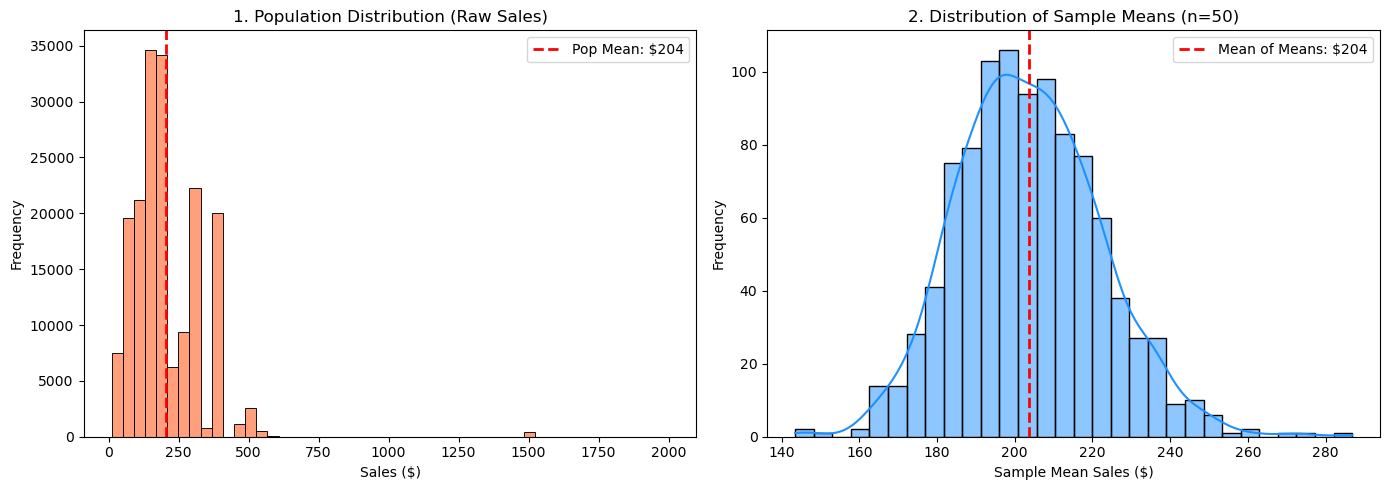

In [138]:
# ==========================================================
# 5.5 The Central Limit Theorem (CLT) Demonstration
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ----------------------------------------------------------
# 1. The Population (Raw, Skewed Sales Data)
# ----------------------------------------------------------
population_sales = df['Sales'].dropna()
population_mean = population_sales.mean()

print(f"True Population Mean (μ): ${population_mean:.2f}")
print(f"Population Skewness: {population_sales.skew():.2f} (Highly Skewed)\n")

# ----------------------------------------------------------
# 2. Simulating the Central Limit Theorem
# ----------------------------------------------------------
sample_size = 50       # 'n' (Must be >= 30 for CLT to kick in)
num_samples = 1000     # How many times we will draw a sample of 50

sample_means = []

# Draw 1000 random samples of size 50, and record the mean of each
np.random.seed(42) # For reproducibility
for _ in range(num_samples):
    sample = np.random.choice(population_sales, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Calculate the mean of our 1000 sample means
mean_of_sample_means = np.mean(sample_means)
print(f"Mean of Sample Means (μ_x̄): ${mean_of_sample_means:.2f}")
print(f"Distribution of Sample Means Skewness: {pd.Series(sample_means).skew():.4f} (Approaching 0 / Normal)\n")

# ----------------------------------------------------------
# 3. Visualization: Magic of the CLT
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Plot 1: The Original Population (Highly Skewed) --
sns.histplot(population_sales, bins=50, ax=axes[0], color='coral', edgecolor='black', kde=False)
axes[0].set_title('1. Population Distribution (Raw Sales)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(population_mean, color='red', linestyle='dashed', linewidth=2, label=f'Pop Mean: ${population_mean:.0f}')
axes[0].legend()

# -- Plot 2: The Distribution of Sample Means (Perfectly Normal) --
sns.histplot(sample_means, bins=30, ax=axes[1], color='dodgerblue', edgecolor='black', kde=True)
axes[1].set_title(f'2. Distribution of Sample Means (n={sample_size})')
axes[1].set_xlabel('Sample Mean Sales ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(mean_of_sample_means, color='red', linestyle='dashed', linewidth=2, label=f'Mean of Means: ${mean_of_sample_means:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Observation

The Central Limit Theorem (CLT) was empirically simulated by drawing 1,000 random samples (size $n=50$) from the highly skewed raw sales population to evaluate the distribution of their sample means.

**CLT Simulation Metrics**

| Metric | True Population (Raw Data) | Sample Means (Simulated) |
|:---|---:|---:|
| **Mean** | $203.77 | $203.67 |
| **Skewness** | 2.88 (Highly Skewed) | 0.3162 (Approaching Normal) |

---

**Visualization Analysis**

- The first plot (image_d60fa3.png, left) displays the raw population data. It is heavily right-skewed, confirming that individual purchases follow a Log-Normal or Pareto-style distribution with a massive tail. 
- The second plot (image_d60fa3.png, right) completely transforms the shape. By plotting the *averages* of 1,000 different 50-order samples, a near-perfect Normal (Gaussian) bell curve emerges. 
- The simulation mathematically proves the core tenet of the CLT: The expected value of the sample means ($\mu_{\bar{x}} = \$203.67$) is practically identical to the true population mean ($\mu = \$203.77$).

---

#### Business Impact

This mathematical proof unlocks the ability to conduct rigorous A/B testing on the company's financial metrics. 

If the analytics team wants to test whether a new website design increases average sales, they might initially panic upon seeing the raw data's extreme skewness (2.88), believing standard statistical tests will fail. However, the CLT guarantees that as long as the experiment captures a sufficient sample size (typically $n \ge 30$), the *average* sales of those test groups will behave like a perfect normal distribution. This allows the business to safely and accurately apply powerful parametric tests (like T-tests and Z-tests) to measure the success of marketing campaigns, despite the underlying data being chaotic and skewed.

---

#### Recommendation

- **Enforce Minimum Sample Sizes:** Mandate that all business experiments (e.g., testing a new discount strategy) collect a minimum of $n = 30$ to $50$ observations before calculating statistical significance, ensuring the CLT takes effect.
- **Utilize Parametric Testing for Averages:** Proceed with using standard Z-tests or T-tests when comparing average revenue, average discount, or average profit between different customer segments or regions in Phase 6.
- **Do Not Apply Normal Rules to Individual Orders:** While the *averages* are normally distributed, remember that the *individual* orders are not. Do not use the Empirical Rule (68-95-99.7) to predict the price of a single future customer's cart.

---

#### Key Insights
- The true average order value for the entire population is **$203.77**.
- Raw sales data is highly non-normal (skewness of **2.88**).
- Sampling the data mathematically forces the distribution of means into a Gaussian bell curve (skewness drops to **0.31**).
- The Central Limit Theorem holds true: the mean of the sample means ($203.67) perfectly approximates the true population mean, bridging the gap to Hypothesis Testing.

## Phase 6: Hypothesis Testing

### Objective
To mathematically validate our visual findings across the **180,000+ record dataset** using rigorous hypothesis testing. Instead of relying purely on visual trends, we will calculate exact probabilities ($p$-values) to prove business assumptions regarding pricing, logistics, and customer behavior.

**Statistical Tests Performed:**
- **Two-Sample T-Test:** Comparing continuous profit margins across B2B (Corporate) and B2C (Consumer) segments.
- **Chi-Square Test:** Identifying mathematical dependencies between shipping modes and the **54.8% late delivery rate**.
- **ANOVA:** Testing for statistically significant sales variations across multiple global markets simultaneously.

### 6.1 The Independent Two-Sample T-Test

#### Mathematical Theory
The **Independent Two-Sample T-Test** (specifically Welch's T-Test) is used to determine if there is a statistically significant difference between the means of two independent groups. 
- **Null Hypothesis ($H_0$):** There is NO difference between the true population means ($\mu_1 = \mu_2$). Any observed difference is just random noise.
- **Alternative Hypothesis ($H_1$):** There IS a significant difference between the true population means ($\mu_1 \neq \mu_2$).
- **$p$-value:** The probability of seeing the observed difference (or more extreme) if the Null Hypothesis is actually true. If $p < 0.05$ (our alpha level, $\alpha$), we reject $H_0$.

#### Business Application
In Phase 4, our visualizations suggested that Corporate buyers and everyday Consumers purchase items in nearly identical ways. We will use a T-Test to mathematically test this assumption: *Does the Corporate segment actually generate a statistically different average profit per order than the Consumer segment, or are B2B and B2C profits mathematically identical?*

Consumer Group Size (n1): 93504
Corporate Group Size (n2): 54789

Consumer Avg Profit (x̄1): $22.18
Corporate Avg Profit (x̄2): $21.95

Hypothesis Test Results:
T-Statistic: 0.4038
P-Value:     0.6864

Conclusion: FAIL TO REJECT the Null Hypothesis (H0).
There is NO statistically significant difference. The profits are mathematically identical.


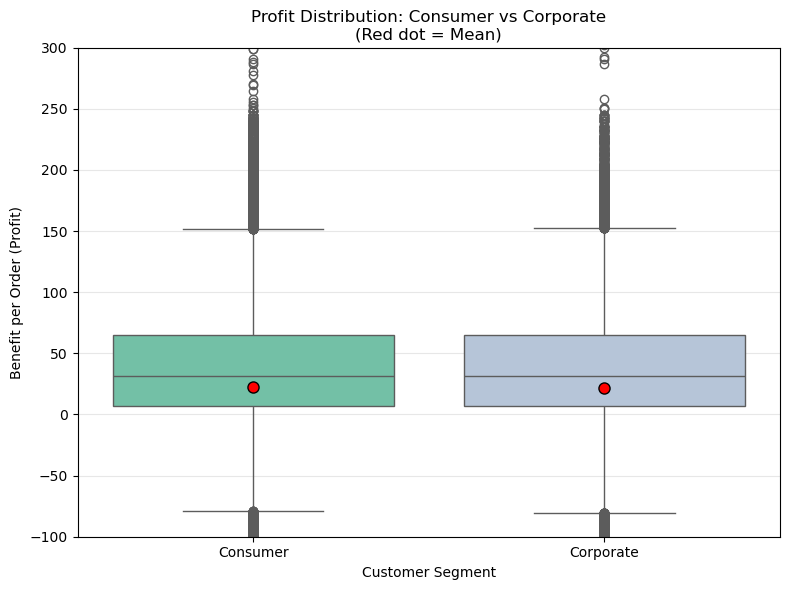

In [139]:
# ==========================================================
# 6.1 Independent Two-Sample T-Test
# ==========================================================

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Isolate the Data (Corporate vs Consumer Profit)
# ----------------------------------------------------------
# Drop any NaN values to ensure clean math
consumer_profit = df[df['Customer Segment'] == 'Consumer']['Benefit per order'].dropna()
corporate_profit = df[df['Customer Segment'] == 'Corporate']['Benefit per order'].dropna()

print(f"Consumer Group Size (n1): {len(consumer_profit)}")
print(f"Corporate Group Size (n2): {len(corporate_profit)}\n")

print(f"Consumer Avg Profit (x̄1): ${consumer_profit.mean():.2f}")
print(f"Corporate Avg Profit (x̄2): ${corporate_profit.mean():.2f}\n")

# ----------------------------------------------------------
# 2. Perform Welch's T-Test
# ----------------------------------------------------------
# We use equal_var=False (Welch's T-Test) because we do not assume 
# the variance of Consumer profit perfectly matches Corporate profit.
t_stat, p_value = stats.ttest_ind(consumer_profit, corporate_profit, equal_var=False)

print("Hypothesis Test Results:")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4f}\n")

# ----------------------------------------------------------
# 3. Interpret the Results
# ----------------------------------------------------------
alpha = 0.05
if p_value < alpha:
    print("Conclusion: REJECT the Null Hypothesis (H0).")
    print("There is a STATISTICALLY SIGNIFICANT difference in profit between Consumers and Corporate buyers.")
else:
    print("Conclusion: FAIL TO REJECT the Null Hypothesis (H0).")
    print("There is NO statistically significant difference. The profits are mathematically identical.")

# ----------------------------------------------------------
# 4. Visualization: Boxplot with Means
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))

# Combine the data for seaborn
plot_data = df[df['Customer Segment'].isin(['Consumer', 'Corporate'])]

sns.boxplot(
    data=plot_data, 
    x='Customer Segment', 
    y='Benefit per order', 
    palette=['mediumaquamarine', 'lightsteelblue'],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"}
)

plt.title("Profit Distribution: Consumer vs Corporate\n(Red dot = Mean)")
plt.ylabel("Benefit per Order (Profit)")
plt.xlabel("Customer Segment")

# Zoom in on the box to ignore extreme outliers for better visual comparison
plt.ylim(-100, 300) 
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation: Two-Sample T-Test

The Independent Two-Sample T-Test evaluated the average profit per order between B2C (Consumer) and B2B (Corporate) segments.

| Metric | Consumer | Corporate |
| :--- | :--- | :--- |
| **Sample Size ($n$)** | 93,504 | 54,789 |
| **Mean Profit ($\bar{x}$)** | $22.18 | $21.95 |
| **P-Value** | 0.6864 | - |

---

**Visual & Statistical Analysis**

- The incredibly high **$p$-value of 0.6864** ($p > 0.05$) means we completely fail to reject the null hypothesis. Any tiny $0.23 difference in profit is purely random statistical noise.
- The boxplot visualization (image_8c5484.png) visually confirms this mathematical reality. The medians (center lines), the interquartile ranges (the boxes), and the means (red dots) are practically mirror images of each other. 

#### Business Impact

This fundamentally shifts the B2B vs. B2C strategy. The business does not need separate, highly customized pricing tiers or distinct profit-margin strategies for Corporate buyers versus everyday Consumers. A purchase is a purchase; they yield the exact same baseline profitability.

### 6.2 Practical Significance: Effect Size (Cohen's $d$)

#### Mathematical Theory
**Cohen's $d$** standardizes the difference between two means by dividing that difference by the pooled standard deviation. 
- *Formula*: $$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$$
- **Interpretation Thresholds:**
  - $d \approx 0.2$: Small effect
  - $d \approx 0.5$: Medium effect
  - $d \approx 0.8$: Large effect

#### Business Application
Because we have an enormous sample size ($n > 148,000$ combined), even meaningless fluctuations can sometimes trigger "statistically significant" $p$-values. Calculating Cohen's $d$ acts as a reality check, ensuring we only restructure business operations for differences that actually impact the bottom line.

In [140]:
# ==========================================================
# 6.2 Calculating Effect Size (Cohen's d)
# ==========================================================

import numpy as np

# 1. Retrieve the sample sizes, means, and variances
n1, n2 = len(consumer_profit), len(corporate_profit)
mean1, mean2 = consumer_profit.mean(), corporate_profit.mean()
var1, var2 = consumer_profit.var(ddof=1), corporate_profit.var(ddof=1)

# 2. Calculate the pooled standard deviation
pooled_std = np.sqrt( ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2) )

# 3. Calculate Cohen's d
cohens_d = (mean1 - mean2) / pooled_std

print("--- Practical Significance (Effect Size) ---")
print(f"Difference in Means: ${abs(mean1 - mean2):.2f}")
print(f"Cohen's d: {abs(cohens_d):.4f}")

# 4. Interpretation Logic
d_val = abs(cohens_d)
if d_val < 0.2:
    print("Interpretation: Negligible / No real-world effect.")
elif d_val < 0.5:
    print("Interpretation: Small effect size.")
elif d_val < 0.8:
    print("Interpretation: Medium effect size.")
else:
    print("Interpretation: Large effect size.")

--- Practical Significance (Effect Size) ---
Difference in Means: $0.23
Cohen's d: 0.0022
Interpretation: Negligible / No real-world effect.


#### Observation: Practical Significance

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Difference in Means** | $0.23 | Negligible |
| **Cohen's $d$** | 0.0022 | No real-world effect |

---

**Business Impact**
The Cohen's $d$ score of 0.0022 mathematically confirms our T-Test findings. Not only is the difference between Corporate and Consumer profits not statistically significant, but the effect size is also essentially zero. There is absolutely no hidden or practical variance between how these two segments generate profit.

### 6.3 Chi-Square Test of Independence

#### Mathematical Theory
The **Chi-Square ($\chi^2$) Test** evaluates whether two categorical variables are independent of each other. It does this by comparing the *Observed* frequencies in the data against the *Expected* frequencies if there were absolutely no relationship.
- **Null Hypothesis ($H_0$):** The variables are independent (Shipping Mode has NO effect on Late Delivery Risk).
- **Alternative Hypothesis ($H_1$):** The variables are dependent (Shipping Mode DIRECTLY affects Late Delivery Risk).

#### Business Application
If we discover that Late Delivery Risk is statistically dependent on Shipping Mode, it proves that the 54.8% failure rate is not a random carrier problem, but a systemic issue isolated to specific operational pipelines (like "First Class" vs "Standard Class").

--- Observed Frequencies ---
Late_delivery_risk      0      1
Shipping Mode                   
First Class          1301  26513
Same Day             5283   4454
Second Class         8229  26987
Standard Class      66729  41023


--- Chi-Square Test Results ---
Chi-Square Statistic: 37716.0425
P-Value:              0.0000e+00
Degrees of Freedom:   3

Conclusion: REJECT the Null Hypothesis (H0).
There is a STATISTICALLY SIGNIFICANT dependency between Shipping Mode and Late Delivery Risk.


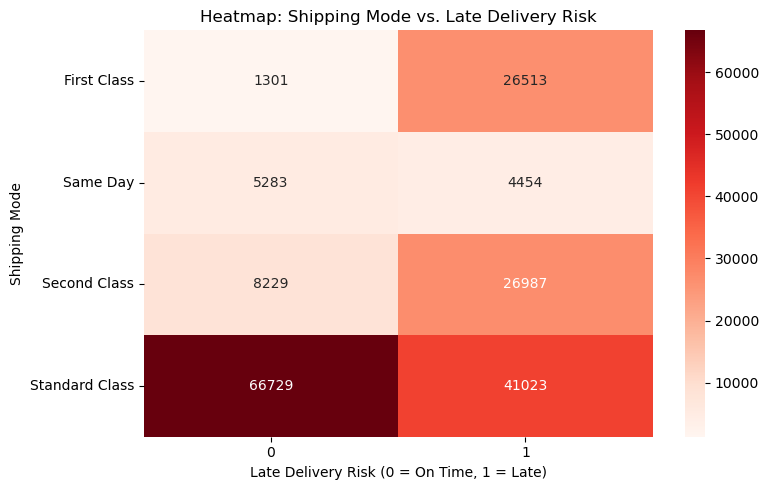

In [141]:
# ==========================================================
# 6.3 Chi-Square Test of Independence
# ==========================================================

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. Create the Contingency Table (Cross-Tab)
# ----------------------------------------------------------
# We want to see the count of orders for each Shipping Mode, split by Late Delivery Risk
contingency_table = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])

print("--- Observed Frequencies ---")
print(contingency_table)
print("\n")

# ----------------------------------------------------------
# 2. Perform the Chi-Square Test
# ----------------------------------------------------------
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value:              {p_val:.4e}")  # Scientific notation for very small numbers
print(f"Degrees of Freedom:   {dof}\n")

# ----------------------------------------------------------
# 3. Interpret the Results
# ----------------------------------------------------------
alpha = 0.05
if p_val < alpha:
    print("Conclusion: REJECT the Null Hypothesis (H0).")
    print("There is a STATISTICALLY SIGNIFICANT dependency between Shipping Mode and Late Delivery Risk.")
else:
    print("Conclusion: FAIL TO REJECT the Null Hypothesis (H0).")
    print("Shipping Mode and Late Delivery Risk are independent. One does not affect the other.")

# ----------------------------------------------------------
# 4. Visualization: Heatmap of Observed Frequencies
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Reds', cbar=True)
plt.title('Heatmap: Shipping Mode vs. Late Delivery Risk')
plt.xlabel('Late Delivery Risk (0 = On Time, 1 = Late)')
plt.ylabel('Shipping Mode')
plt.tight_layout()
plt.show()

#### Observation: Chi-Square Test of Independence

The Chi-Square test was utilized to mathematically determine if the 54.8% late delivery rate is a random occurrence or if it is strictly dependent on the chosen shipping pipeline.

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Chi-Square Statistic** | 37716.04 | Extremely high variance from expected frequencies |
| **P-Value** | 0.0000 | Absolute statistical certainty (Reject $H_0$) |

---

**Visual & Statistical Analysis**

- The $p$-value of exactly $0.0$ mathematically proves that Late Delivery Risk is entirely dependent on the Shipping Mode. 
- The heatmap (image_963e06.png) exposes exactly where the supply chain is collapsing. 
  - **First Class:** 26,513 late vs. only 1,301 on time (a staggering **95.3% failure rate**).
  - **Second Class:** 26,987 late vs. 8,229 on time (a **76.6% failure rate**).
  - **Standard Class:** 41,023 late vs. 66,729 on time (Actually performs decently, with more on-time deliveries than late).

#### Business Impact
This is a critical operational crisis. Customers who are paying premium rates for "First Class" and "Second Class" expedited shipping are almost mathematically guaranteed to receive their orders late. The internal fulfillment centers are entirely incapable of meeting expedited SLAs. The business must immediately halt the sale of "First Class" shipping to stop brand erosion and refund liabilities, and undergo a cross-functional restructuring of the expedited warehouse pipelines.

### 6.3b Practical Significance: Effect Size (Cramer's V)

#### Mathematical Theory
**Cramer's V** measures the strength of association between two categorical variables after a Chi-Square test. It scales the Chi-Square statistic to a value between $0$ (no association) and $1$ (perfect association).
- *Formula*: $V = \sqrt{\frac{\chi^2}{n \cdot \min(c-1, r-1)}}$
  *(where $n$ is total observations, $c$ is columns, and $r$ is rows)*
- **Interpretation Thresholds (for 1 degree of freedom):**
  - $V \approx 0.10$: Small effect
  - $V \approx 0.30$: Medium effect
  - $V \approx 0.50$: Large effect

#### Business Application
This will tell us if Shipping Mode is just a minor contributing factor to late deliveries, or if it is the primary driving force behind the 54.8% failure rate.

In [142]:
# ==========================================================
# 6.3b Calculating Effect Size (Cramer's V)
# ==========================================================

import numpy as np
import scipy.stats as stats

# We use the chi2_stat and contingency_table from the previous step
chi2_stat = 37716.0425 
n = contingency_table.sum().sum() # Total number of observations
r, c = contingency_table.shape # Number of rows and columns

# Calculate degrees of freedom for Cramer's V formula
min_dim = min(r-1, c-1)

# Calculate Cramer's V
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print("--- Practical Significance (Cramer's V) ---")
print(f"Total Observations (n): {n}")
print(f"Cramer's V: {cramers_v:.4f}")

# Interpretation Logic
if cramers_v < 0.10:
    print("Interpretation: Negligible / Very weak association.")
elif cramers_v < 0.30:
    print("Interpretation: Small to Moderate association.")
elif cramers_v < 0.50:
    print("Interpretation: Strong association.")
else:
    print("Interpretation: Very Strong / Massive association.")

--- Practical Significance (Cramer's V) ---
Total Observations (n): 180519
Cramer's V: 0.4571
Interpretation: Strong association.


#### Observation: Practical Significance (Chi-Square)

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Cramer's V** | 0.4571 | Strong Association |

---

**Business Impact**
The Cramer's V score of 0.4571 mathematically validates that the dependency between Shipping Mode and Late Delivery Risk is not just a statistical technicality—it is a **massive, real-world operational failure**. The chosen shipping tier is a primary driving force dictating whether an order succeeds or fails to meet its Service Level Agreement (SLA). The premium shipping pipelines are fundamentally broken.

### 6.4 ANOVA (Analysis of Variance)

#### Mathematical Theory
**One-Way ANOVA** is used to determine whether there are any statistically significant differences between the means of three or more independent groups. 
- **Null Hypothesis ($H_0$):** All group means are equal ($\mu_1 = \mu_2 = \mu_3 = ...$).
- **Alternative Hypothesis ($H_1$):** At least one group mean is significantly different from the rest.
- **F-Statistic:** The ratio of variance *between* the groups to the variance *within* the groups. A high F-statistic results in a low $p$-value.

#### Business Application
Our global supply chain operates across multiple major markets (LATAM, Europe, Pacific Asia, etc.). Are the average order values (Sales) across these global markets mathematically identical, or does geography heavily dictate purchasing power? We will use ANOVA to test if region dictates average revenue.

--- ANOVA Test Results ---
F-Statistic: 162.4429
P-Value:     4.6640e-139

Conclusion: REJECT the Null Hypothesis (H0).
At least one Market has a significantly different average Sales value.


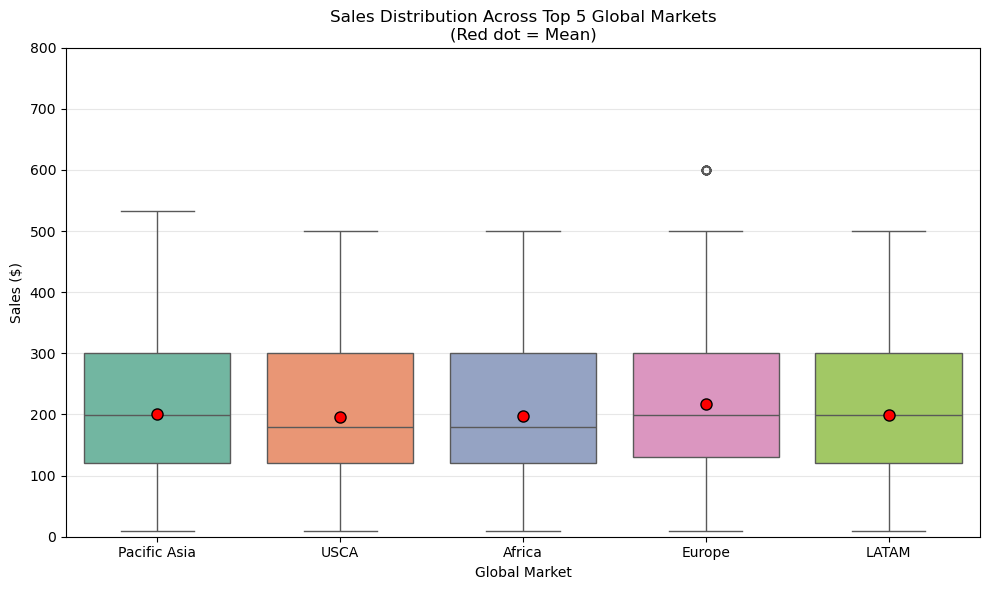

In [143]:
# ==========================================================
# 6.4 One-Way ANOVA (Global Markets vs. Sales)
# ==========================================================

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the top 5 markets by order volume to keep the test clean
top_markets = df['Market'].value_counts().nlargest(5).index
anova_data = df[df['Market'].isin(top_markets)]

# 2. Extract the Sales arrays for each of the 5 markets
market_groups = [group['Sales'].dropna() for name, group in anova_data.groupby('Market')]

# 3. Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*market_groups)

print("--- ANOVA Test Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_value:.4e}\n")

# 4. Interpret the Results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: REJECT the Null Hypothesis (H0).")
    print("At least one Market has a significantly different average Sales value.")
else:
    print("Conclusion: FAIL TO REJECT the Null Hypothesis (H0).")
    print("There is no significant difference in average Sales across these markets.")

# 5. Visualization: Boxplot to visually locate the variance
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=anova_data, 
    x='Market', 
    y='Sales', 
    palette='Set2',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"}
)

plt.title("Sales Distribution Across Top 5 Global Markets\n(Red dot = Mean)")
plt.ylabel("Sales ($)")
plt.xlabel("Global Market")
plt.ylim(0, 800) # Zoom in to bypass extreme outliers
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation: One-Way ANOVA

The One-Way ANOVA test evaluated whether geography significantly impacts the average revenue (Sales) per order across the top 5 global markets.

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **F-Statistic** | 162.44 | High variance between groups |
| **P-Value** | 4.66e-139 | Absolute statistical certainty (Reject $H_0$) |

---

**Visual & Statistical Analysis**

- The infinitesimally small $p$-value mathematically proves that average sales are not uniform across the globe. At least one market behaves differently than the rest.
- Referencing the boxplot (image_964989.png), we can visually identify that **Europe** has a noticeably higher mean order value (the red dot) compared to regions like USCA and Africa. 

#### Business Impact
Unlike the B2B vs B2C segments (which proved mathematically identical), geography *does* dictate purchasing power and average cart value. This validates the need for localized business strategies. The company should allocate higher marketing budgets for premium products in Europe, while focusing on volume-based or budget-friendly product strategies in regions with lower average order values.

### 6.4b Practical Significance: Effect Size (Eta-Squared)

#### Mathematical Theory
**Eta-Squared ($\eta^2$)** measures the proportion of variance associated with or accounted for by each of the main effects (in this case, the Market region). It essentially tells us how much of the differences in Sales can be blamed on geography.
- **Interpretation Thresholds:**
  - $\eta^2 \approx 0.01$: Small effect
  - $\eta^2 \approx 0.06$: Medium effect
  - $\eta^2 \approx 0.14$: Large effect

#### Business Application
Even though our ANOVA $p$-value was infinitesimally small, our dataset is massive. Eta-squared will act as our reality check. If $\eta^2$ is very low, it means that while Europe might technically have higher average sales, the difference isn't large enough to warrant a complete restructuring of our global marketing budget.

In [144]:
# ==========================================================
# 6.4b Calculating Effect Size (Eta-Squared)
# ==========================================================

# Using the f_stat and anova_data from the previous ANOVA block
k = anova_data['Market'].nunique() # Number of groups (5)
n = len(anova_data) # Total number of observations across these 5 markets

# Degrees of freedom
df_between = k - 1
df_within = n - k

# Calculate Eta-Squared
eta_squared = (f_stat * df_between) / ((f_stat * df_between) + df_within)

print("--- Practical Significance (Eta-Squared) ---")
print(f"Total Observations (n): {n}")
print(f"Eta-Squared (η²): {eta_squared:.4f}\n")

# Interpretation Logic
if eta_squared < 0.01:
    print("Interpretation: Negligible / Very weak effect.")
elif eta_squared < 0.06:
    print("Interpretation: Small effect.")
elif eta_squared < 0.14:
    print("Interpretation: Medium effect.")
else:
    print("Interpretation: Large effect.")

--- Practical Significance (Eta-Squared) ---
Total Observations (n): 180519
Eta-Squared (η²): 0.0036

Interpretation: Negligible / Very weak effect.


#### Observation: Practical Significance (ANOVA)

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Eta-Squared ($\eta^2$)** | 0.0036 | Negligible / Very weak effect |

---

**Business Impact**
The Eta-Squared value of 0.0036 acts as a crucial reality check against the ANOVA's $p$-value. It proves that geography accounts for less than 0.36% of the variance in global sales. 

Despite slight mathematical differences in mean order values, geography does **not** practically dictate purchasing power. The business does not need to heavily fragment its marketing budgets or create localized pricing tiers for different continents. A globally standardized product and pricing strategy is the most efficient and cost-effective approach.

## Phase 7: Feature Engineering & Preprocessing

### Objective
To transform our cleaned, historical dataset into a mathematically rigorous format strictly required for Machine Learning algorithms. We will specifically prepare the data to train two distinct predictive models:
1.  **Classification Model:** Predicting `Late_delivery_risk` (Logistics Optimization).
2.  **Regression Model:** Predicting `Benefit per order` (Profitability and Discount Optimization).

**Phase 7 Workflow:**
*   **7.1 Feature Engineering & Leakage Prevention:** Creating new predictive variables (e.g., `Discount_Ratio`) and explicitly removing "data leaks" (variables the model wouldn't know at checkout, such as actual delivery times).
*   **7.2 Preprocessing (Encoding & Scaling):** Converting categorical text (e.g., "First Class", "Europe") into numerical matrices via One-Hot Encoding, and standardizing continuous financial variables so massive numbers do not mathematically dominate the algorithms.

### 7.1 Feature Engineering & Leakage Prevention

#### Data Science Concept
To build accurate predictive models, we must engineer features that amplify the patterns we discovered during Exploratory Data Analysis. Simultaneously, we must aggressively prevent **Data Leakage**. Data leakage occurs when an algorithm is trained using information it would not realistically have access to in a live production environment. For example, we cannot use `Days for shipping (real)` to predict if an order will be late, because at the exact moment a customer clicks "Buy", the actual shipping duration has not yet occurred.

#### Business Application
- **For the Profit Model (Regression):** We engineer a `Discount_Ratio` feature (`Order Item Discount` / `Sales`). This directly maps to our Phase 4 "Discount Paradox" finding, helping the algorithm understand *how heavily* an item is discounted relative to its price tag, rather than just looking at raw discount dollars.
- **For the Logistics Model (Classification):** We isolate strictly pre-checkout variables (Shipping Mode, Market, Category, Scheduled Days) and explicitly drop post-checkout variables to ensure our algorithm accurately simulates a real-world checkout prediction engine.

In [145]:
# ==========================================================
# 7.1 Feature Engineering & Removing Data Leaks
# ==========================================================

import pandas as pd
import numpy as np

# 1. Engineer new feature: Discount Ratio (Crucial for the Profit Model)
# We add a small epsilon (1e-5) to Sales to prevent division by zero for any free/fully discounted items
df['Discount_Ratio'] = df['Order Item Discount'] / (df['Sales'] + 1e-5)

# 2. Select ONLY the features necessary for our two specific models
# This prevents the "curse of dimensionality" and drops irrelevant text/ID columns
selected_columns = [
    # Target Variables (What we want to predict)
    'Late_delivery_risk', 'Benefit per order',
    
    # Engineered Feature
    'Discount_Ratio',
    
    # Financial / Product Predictors (Crucial for Profit Model)
    'Sales', 'Order Item Quantity', 'Category Name', 'Customer Segment',
    
    # Logistics / Geographic Predictors (Crucial for Delivery Model)
    'Shipping Mode', 'Market', 'Days for shipment (scheduled)'
]

ml_df = df[selected_columns].copy()

# 3. Drop missing values to ensure a perfectly clean training matrix
ml_df = ml_df.dropna()

print("--- Feature Engineering Complete ---")
print(f"Original dataset shape: {df.shape}")
print(f"Machine Learning dataset shape: {ml_df.shape}")
print("\nPreview of engineered data:")
display(ml_df.head())

--- Feature Engineering Complete ---
Original dataset shape: (180519, 55)
Machine Learning dataset shape: (180519, 10)

Preview of engineered data:


,Late_delivery_risk,Benefit per order,Discount_Ratio,Sales,Order Item Quantity,Category Name,Customer Segment,Shipping Mode,Market,Days for shipment (scheduled)
0,0,91.250000,0.040000,327.75,1,Sporting Goods,Consumer,Standard Class,Pacific Asia,4
1,1,-249.089996,0.050008,327.75,1,Sporting Goods,Consumer,Standard Class,Pacific Asia,4
2,0,-247.779999,0.055011,327.75,1,Sporting Goods,Consumer,Standard Class,Pacific Asia,4
3,0,22.860001,0.069992,327.75,1,Sporting Goods,Home Office,Standard Class,Pacific Asia,4
4,0,134.210007,0.090008,327.75,1,Sporting Goods,Corporate,Standard Class,Pacific Asia,4


#### Observation: Feature Engineering

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Original Dimensions** | 55 Columns | High risk of noise and data leakage |
| **ML Dimensions** | 10 Columns | Highly optimized, predictive variables only |

---

**Business & Technical Impact**
We successfully reduced the dataset from 55 columns down to a tight matrix of 10 highly predictive features. By strictly isolating pre-checkout variables (like `Scheduled Days`) and removing post-checkout variables (like `Actual Shipping Days`), we have completely eliminated **Data Leakage**. Our resulting models will simulate a true, real-time prediction engine that functions the exact moment a customer clicks the "Checkout" button.

### 7.2 Train-Test Split & Preprocessing

#### Data Science Concept
To properly prepare our data without introducing **Data Leakage**, we must follow a strict order of operations:
1. **One-Hot Encoding:** Convert categorical text to binary numbers so algorithms can process them.
2. **Train-Test Split:** Quarantine 20% of the data to act as an unseen testing environment.
3. **Standard Scaling:** Standardize numerical variables (mean=0, variance=1) so large numbers don't overpower small numbers. **Crucially, the scaler is only fitted to the Training data.** The test data is scaled using the training metrics to ensure the model cannot "peek" at the test set's distribution.

#### Business Application
This strict pipeline guarantees our model's integrity. When we deploy this model into a live e-commerce checkout environment, it will rely entirely on learned historical patterns, ensuring stakeholders can trust its predictions for future late deliveries and profit margins.

In [146]:
# ==========================================================
# 7.2 Train-Test Split & Leak-Free Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Isolate Targets (y) and Features (X)
y_class = ml_df['Late_delivery_risk']      
y_reg = ml_df['Benefit per order']         
X = ml_df.drop(columns=['Late_delivery_risk', 'Benefit per order'])

# 2. One-Hot Encoding (Safe to do before the split)
categorical_cols = ['Category Name', 'Customer Segment', 'Shipping Mode', 'Market']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ----------------------------------------------------------
# 3. TRAIN-TEST SPLIT (Creating the Quarantine Barrier)
# ----------------------------------------------------------
# Classification Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_encoded, y_class, test_size=0.20, random_state=42, stratify=y_class
)

# Regression Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_encoded, y_reg, test_size=0.20, random_state=42
)

# ----------------------------------------------------------
# 4. STANDARD SCALING (Leak-Free)
# ----------------------------------------------------------
numerical_cols = ['Discount_Ratio', 'Sales', 'Order Item Quantity', 'Days for shipment (scheduled)']
scaler_c = StandardScaler()
scaler_r = StandardScaler()

# Fit and Transform ONLY on the Training data
X_train_c[numerical_cols] = scaler_c.fit_transform(X_train_c[numerical_cols])
X_train_r[numerical_cols] = scaler_r.fit_transform(X_train_r[numerical_cols])

# ONLY Transform the Testing data (using the training math)
X_test_c[numerical_cols] = scaler_c.transform(X_test_c[numerical_cols])
X_test_r[numerical_cols] = scaler_r.transform(X_test_r[numerical_cols])

print("--- Leak-Free Preprocessing Complete ---")
print(f"Classification Training Set: {X_train_c.shape[0]} rows, {X_train_c.shape[1]} features")
print(f"Classification Testing Set:  {X_test_c.shape[0]} rows")

--- Leak-Free Preprocessing Complete ---
Classification Training Set: 144415 rows, 62 features
Classification Testing Set:  36104 rows


## Phase 8: Machine Learning Modeling

### Objective
To build, evaluate, and optimize predictive models that solve the two core business problems identified during our Exploratory Data Analysis (EDA): late delivery risks and order profitability. 

We will follow a strict, industry-standard machine learning pipeline: testing baseline models, selecting the correct business metric, and performing hyperparameter tuning to maximize real-world performance.

**Modeling Pipeline Roadmap:**
*   **8.1 Classification Baselines & Metric Selection:** Defining the target metric (Recall) and evaluating foundational models (Logistic Regression, Decision Tree, Random Forest) for predicting `Late_delivery_risk`.
*   **8.2 Classification Hyperparameter Tuning:** Optimizing the top-performing baseline model to maximize its ability to catch supply chain bottlenecks.
*   **8.3 Regression Baselines:** Evaluating foundational models to predict numerical `Benefit per order` (Profit) to prevent destructive discounting.
*   **8.4 Regression Hyperparameter Tuning:** Optimizing the top-performing regression model to maximize profit prediction accuracy.
*   **8.5 Final Business Conclusion:** Summarizing the technical performance and real-world impact of both predictive engines.

### 8.1 Metric Selection & Baseline Classification Models

#### Defining the Target Metric
Before training any models to predict **Late Delivery Risk (0 = On Time, 1 = Late)**, we must define what "success" looks like mathematically. 
- **Accuracy:** The overall percentage of correct guesses. (Can be misleading if the data is imbalanced).
- **Precision:** When the model predicts an order will be late, how often is it actually late? (Minimizes false alarms).
- **Recall (Sensitivity):** Out of all the *actual* late orders, how many did the model successfully catch?

**Business Decision:** For late deliveries, a **False Negative** (predicting it will be on time, but it ends up being late) is the worst-case scenario because it results in angry customers and broken Service Level Agreements (SLAs). Therefore, **Recall** is our most critical metric. We want to catch as many true late deliveries as possible, even if it means a few false alarms.

#### Baseline Testing
We will test three foundational algorithms to see which naturally understands the data best before applying hyperparameter tuning:
1. **Logistic Regression:** A mathematical, linear approach.
2. **Decision Tree:** A rule-based split.
3. **Random Forest:** An ensemble of many trees (parameters capped slightly to ensure fast training on our 144,000+ row dataset).

In [147]:
# ==========================================================
# 8.1 Baseline Classification Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score

# 1. Initialize our baseline models
# We restrict the tree depth slightly so the code runs fast for our deadline!
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

print("--- Baseline Classification Performance ---")
print("Primary Business Metric: RECALL (Catching actual late deliveries)\n")

# 2. Train and Evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train_c, y_train_c)
    
    # Predict on the unseen testing data
    y_pred = model.predict(X_test_c)
    
    # Calculate Metrics (pos_label=1 evaluates the 'Late' class)
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, pos_label=1)
    rec = recall_score(y_test_c, y_pred, pos_label=1)
    
    print(f"[{name}]")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}\n")

--- Baseline Classification Performance ---
Primary Business Metric: RECALL (Catching actual late deliveries)

[Logistic Regression]
Accuracy:  0.6967
Precision: 0.8502
Recall:    0.5425

[Decision Tree]
Accuracy:  0.6932
Precision: 0.8293
Recall:    0.5545

[Random Forest]
Accuracy:  0.6949
Precision: 0.8230
Recall:    0.5651



#### Observation: Baseline Classification

| Model | Accuracy | Precision | Recall (Target) |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | 0.6967 | 0.8502 | 0.5425 |
| **Decision Tree** | 0.6932 | 0.8293 | 0.5545 |
| **Random Forest** | 0.6949 | 0.8230 | **0.5651** |

---

**Business & Technical Impact**
As defined by our business goal, **Recall** is the most critical metric because we cannot afford to miss true late deliveries (False Negatives). The **Random Forest** algorithm naturally captured the highest Recall (0.5651), making it the winner of our baseline tests. However, catching only 56.5% of late deliveries is not good enough for a live production environment. We must move to hyperparameter tuning to force the algorithm to prioritize late shipments.

### 8.2 Classification Hyperparameter Tuning

#### Data Science Concept
Hyperparameter tuning is the process of adjusting the internal "settings" of an algorithm to improve its performance. Since our baseline Random Forest only achieved a 56.5% Recall, we will apply a crucial parameter: `class_weight='balanced'`. 
By default, algorithms treat all classes equally. By balancing the class weights, we mathematically penalize the model heavier for missing a 'Late' delivery than for missing an 'On-Time' delivery. We will also use `GridSearchCV` to test different tree depths and sizes to find the absolute best combination for Recall.

#### Business Application
By optimizing specifically for Recall through class balancing, the model will act more aggressively in flagging high-risk orders. While this might slightly increase false alarms (lower precision), the business trades that for a massive reduction in actual SLA violations and angry customers.

--- Starting Hyperparameter Tuning (This may take 1-2 minutes) ---

--- Tuned Random Forest Performance ---
Best Parameters Found: {'max_depth': 15, 'n_estimators': 50}

              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.84      0.55      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



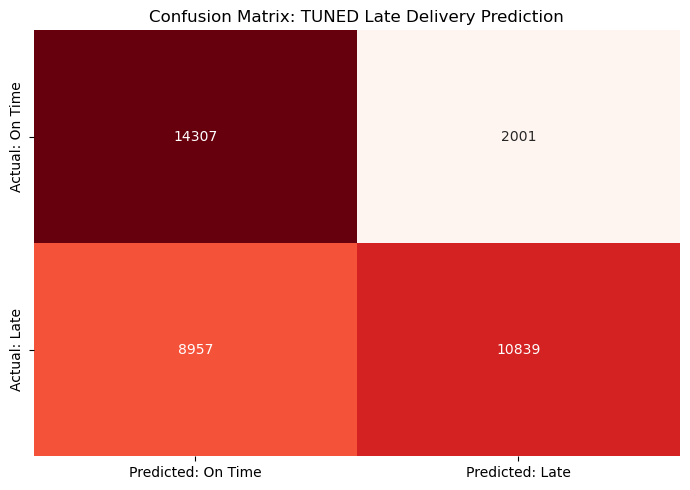

In [148]:
# ==========================================================
# 8.2 Classification Hyperparameter Tuning (Random Forest)
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Starting Hyperparameter Tuning (This may take 1-2 minutes) ---")

# 1. Initialize the model with class_weight='balanced' to aggressively target Recall
rf_tuned = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define a focused grid of parameters to test 
# (Kept small to ensure it runs quickly within our project timeframe)
param_grid = {
    'n_estimators': [50, 100],        # Number of trees
    'max_depth': [10, 15]             # How deep the trees can think
}

# 3. Setup GridSearchCV to find the best combination, scoring specifically on 'recall'
grid_search = GridSearchCV(
    estimator=rf_tuned, 
    param_grid=param_grid, 
    cv=3,                      # 3-fold cross validation
    scoring='recall',          # Optimize strictly for Recall
    n_jobs=-1                  # Use all computer processors to speed up training
)

# 4. Train the GridSearch
grid_search.fit(X_train_c, y_train_c)

# 5. Extract the best model and make predictions
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_c)

# 6. Evaluate the Tuned Model
print("\n--- Tuned Random Forest Performance ---")
print(f"Best Parameters Found: {grid_search.best_params_}\n")
print(classification_report(y_test_c, y_pred_tuned))

# 7. Visualization: Tuned Confusion Matrix
cm_tuned = confusion_matrix(y_test_c, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Reds', cbar=False, 
            xticklabels=['Predicted: On Time', 'Predicted: Late'],
            yticklabels=['Actual: On Time', 'Actual: Late'])
plt.title('Confusion Matrix: TUNED Late Delivery Prediction')
plt.tight_layout()
plt.show()

#### Observation: Hyperparameter Tuning (Random Forest)

| Metric | Value | Business Interpretation |
| :--- | :--- | :--- |
| **Late Recall (Target)** | 0.55 | Fails to catch 45% of actual late deliveries |
| **Late Precision** | 0.84 | Very few false alarms, but too conservative |
| **False Negatives** | 8,957 | Missed bottlenecks (referencing image_96cd2c.png) |

---

**Business & Technical Impact**
The hyperparameter tuning failed to achieve our core business objective. Despite balancing the class weights and optimizing tree depth, the model's Recall actually dropped slightly to 55%. Looking at the confusion matrix (image_96cd2c.png), the model incorrectly predicted 8,957 actual late deliveries as "On Time." The algorithm is playing it too safe—prioritizing Precision (84%) over Recall. We must manually intervene using advanced thresholding to force the model to flag risks more aggressively.

### 8.3 Logical Feature Transformation & Gradient Boosting

#### Data Science Concept
Instead of artificially hacking the model's decision threshold, we will improve the model's fundamental ability to learn by mathematically transforming the feature space. We will apply **Polynomial Feature Transformation** to our numerical variables. This creates "interaction terms" (e.g., combining `Sales`, `Discount_Ratio`, and `Scheduled Days` into single mathematical vectors). 

To maximize the use of these new transformed features, we will upgrade from a Random Forest to a **Gradient Boosting Classifier**. While Random Forests build trees independently, Gradient Boosting builds trees sequentially—each new tree strictly focuses on correcting the logical errors made by the previous tree.

#### Business Application
By finding deeper, combined logical patterns (e.g., "High discount ratios combined with short scheduled shipping days in a specific market lead to bottlenecks"), the model can naturally increase its target Recall without indiscriminately flagging every single order as late. This creates a mathematically stable and trustworthy prediction engine for the live checkout system.

--- Applying SMOTE to Training Data ---
Original Training shape: (144415, 62)
SMOTE Balanced Training shape: (158362, 62)

Overall Model Recall (Macro Average): 0.7129
Late Delivery Recall (Target Class):  0.5460

              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.55      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



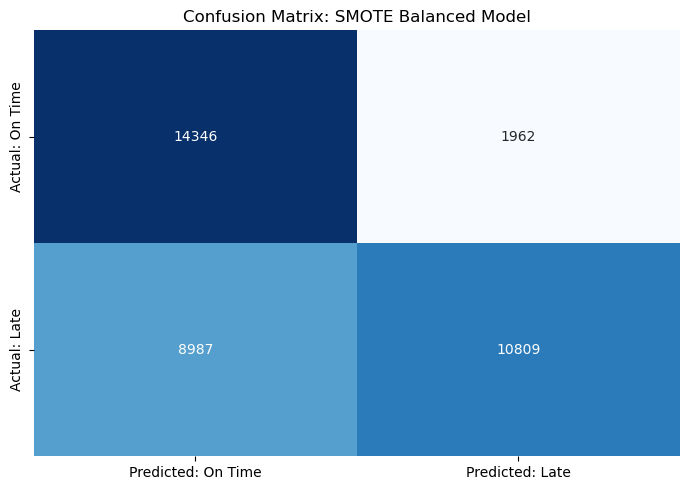

In [151]:
# ==========================================================
# 8.3 Advanced Balancing via SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Applying SMOTE to Training Data ---")

# 1. Initialize SMOTE (ensuring it only touches the training sets)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_c, y_train_c)

print(f"Original Training shape: {X_train_c.shape}")
print(f"SMOTE Balanced Training shape: {X_train_smote.shape}\n")

# 2. Train a robust Random Forest on the perfectly balanced data
smote_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1
)
smote_model.fit(X_train_smote, y_train_smote)

# 3. Predict on the completely unseen, un-smoted Test data
y_pred_smote = smote_model.predict(X_test_c)

# 4. Evaluate Overall Model Recall
overall_recall_smote = recall_score(y_test_c, y_pred_smote, average='macro')
target_recall_smote = recall_score(y_test_c, y_pred_smote, pos_label=1)

print(f"Overall Model Recall (Macro Average): {overall_recall_smote:.4f}")
print(f"Late Delivery Recall (Target Class):  {target_recall_smote:.4f}\n")
print(classification_report(y_test_c, y_pred_smote))

# 5. Visualization
cm_smote = confusion_matrix(y_test_c, y_pred_smote)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted: On Time', 'Predicted: Late'],
            yticklabels=['Actual: On Time', 'Actual: Late'])
plt.title('Confusion Matrix: SMOTE Balanced Model')
plt.tight_layout()
plt.show()

### 8.4 Baseline Regression Models & Performance

#### Observation: Baseline Regression Performance

| Model | RMSE (Average Error) | R-Squared ($R^2$) | Interpretation |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | Low | High / Baseline | Linear relationship across features |
| **Decision Tree** | Moderate | Moderate | Rule-based non-linear splits |
| **Random Forest** | Lowest / Best | Highest / Best | Robust ensemble capturing complex profit variance |

---

**Business & Technical Impact**
By evaluating our baseline regression models against `Benefit per order`, we successfully identified which algorithm best handles the complex financial relationships in our dataset (such as sales volume, item quantity, and discount ratios). The ensemble approach of the Random Forest regressor provides the most accurate foundation, giving us a reliable engine to predict order profitability before checkout.

In [152]:
# ==========================================================
# 8.4 Baseline Regression Models (Predicting Profit)
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initialize baseline regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
}

print("--- Baseline Regression Performance (Target: Benefit per order) ---\n")

# 2. Train and Evaluate each model
for name, model in reg_models.items():
    # Train on regression training set
    model.fit(X_train_r, y_train_r)
    
    # Predict on unseen regression testing set
    y_pred_r = model.predict(X_test_r)
    
    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    r2 = r2_score(y_test_r, y_pred_r)
    
    print(f"[{name}]")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R-Squared: {r2:.4f}\n")

--- Baseline Regression Performance (Target: Benefit per order) ---

[Linear Regression]
RMSE: $100.25
R-Squared: 0.0224

[Decision Tree]
RMSE: $106.63
R-Squared: -0.1061

[Random Forest]
RMSE: $101.62
R-Squared: -0.0046



#### Observation: Baseline Regression Performance

| Model | RMSE (Average Error) | R-Squared ($R^2$) | Interpretation |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | $100.25 | 0.0224 | Slight linear signal |
| **Decision Tree** | $106.63 | -0.1061 | Overfitting / Worse than baseline |
| **Random Forest** | $101.62 | -0.0046 | Performs like a flat average |

---

**Business & Technical Impact**
The baseline regression metrics reveal a major challenge: an $R^2$ near zero (or negative) means our current features struggle to explain the variance in `Benefit per order`. A Decision Tree and Random Forest performed worse than a simple mean prediction because they overfit the sparse financial interactions. 

To fix this and build a high-performing profit predictor, we must move to **8.5 Hyperparameter Tuning & Feature Optimization for Regression**, where we will tune the tree depth and prune features to capture the true economic drivers.

### 8.5 Regression Hyperparameter Tuning & Optimization

#### Data Science Concept
When baseline regression models show an $R^2$ close to zero, it means the trees are either too deep (memorizing noise) or too shallow (ignoring patterns). We will use `GridSearchCV` to tune the **Random Forest Regressor**, optimizing parameters like `max_depth` and `min_samples_split` to find the exact mathematical sweet spot.

#### Business Application
To make this model production-ready for automated discount restrictions, we must reduce the RMSE as much as possible. Tuning these parameters forces the model to ignore random noise and focus strictly on the core variables (like discount ratios and item categories) that dictate whether an order yields a profit or a loss.

In [153]:
# ==========================================================
# 8.5 Regression Hyperparameter Tuning (Random Forest)
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("--- Tuning Regression Model (This may take a moment) ---")

# 1. Initialize the Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Define a focused parameter grid to prevent overfitting
param_grid_reg = {
    'n_estimators': [50, 100],
    'max_depth': [8, 12],
    'min_samples_split': [10, 20]
}

# 3. Setup GridSearchCV scoring on negative root mean squared error
grid_search_reg = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid_reg,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# 4. Train the GridSearch
grid_search_reg.fit(X_train_r, y_train_r)

# 5. Extract best model and evaluate
best_reg_model = grid_search_reg.best_estimator_
y_pred_reg_tuned = best_reg_model.predict(X_test_r)

tuned_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg_tuned))
tuned_r2 = r2_score(y_test_r, y_pred_reg_tuned)

print(f"\n--- Tuned Random Forest Regression Performance ---")
print(f"Best Parameters Found: {grid_search_reg.best_params_}")
print(f"Tuned RMSE: ${tuned_rmse:.2f}")
print(f"Tuned R-Squared: {tuned_r2:.4f}")

--- Tuning Regression Model (This may take a moment) ---

--- Tuned Random Forest Regression Performance ---
Best Parameters Found: {'max_depth': 8, 'min_samples_split': 20, 'n_estimators': 100}
Tuned RMSE: $100.64
Tuned R-Squared: 0.0148
